In [1]:
from pathlib import Path
import os
import re
import pandas as pd
from nilearn.decomposition import CanICA
from nilearn.masking import compute_multi_epi_mask
from nilearn import plotting
from nilearn.image import index_img
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
from nilearn.maskers import NiftiMasker
from nilearn.image import load_img
from nilearn.masking import apply_mask, unmask
from IPython.display import display
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.utils import shuffle

from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")
from collections import Counter

# Import Data


In [2]:
# -----------------------------
# Set paths
# -----------------------------
DATA_DIR = Path("/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC")
OUT_DIR = DATA_DIR / "group_ica_results"
OUT_DIR.mkdir(exist_ok=True, parents=True)

print("DATA_DIR exists:", DATA_DIR.exists())
print("OUT_DIR:", OUT_DIR)

# -----------------------------
# Collect all nii.gz files
# -----------------------------
nii_files = sorted(DATA_DIR.glob("*.nii.gz"))

print(f"Number of NIfTI files found: {len(nii_files)}")
print("\nFirst 10 files:")
for f in nii_files[:10]:
    print(f.name)

# -----------------------------
# Parse filenames
# Expected format:
# p_s0002_rs1_4mm.nii.gz
# t_s0106_rs8_4mm.nii.gz
# -----------------------------
pattern = re.compile(
    r"^(?P<group_letter>[pt])_s(?P<subject_id>\d+)_rs(?P<scan_id>\d+)_4mm\.nii\.gz$"
)

group_map = {
    "p": "placebo",
    "t": "THC"
}

rows = []

for f in nii_files:
    m = pattern.match(f.name)
    if m is None:
        print(f"Skipped (filename not matched): {f.name}")
        continue

    group_letter = m.group("group_letter")
    subject_id = m.group("subject_id")
    scan_id = int(m.group("scan_id"))

    rows.append({
        "file_name": f.name,
        "file_path": str(f),
        "group_letter": group_letter,
        "group": group_map[group_letter],
        "subject_id": f"s{subject_id}",
        "scan_id": scan_id
    })

meta_df = pd.DataFrame(rows)

meta_df = meta_df.sort_values(
    by=["group", "subject_id", "scan_id"]
).reset_index(drop=True)

print("\nmeta_df shape:", meta_df.shape)
display(meta_df.head(20))

print("\nCounts by group:")
print(meta_df["group"].value_counts())

print("\nCounts by scan:")
print(meta_df["scan_id"].value_counts().sort_index())

print("\nUnique subjects per group:")
print(meta_df.groupby("group")["subject_id"].nunique())

# save
meta_path = DATA_DIR / "metadata_all_scans.csv"
meta_df.to_csv(meta_path, index=False)
print(f"\nSaved metadata to: {meta_path}")

DATA_DIR exists: True
OUT_DIR: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results
Number of NIfTI files found: 190

First 10 files:
p_s0002_rs1_4mm.nii.gz
p_s0002_rs2_4mm.nii.gz
p_s0002_rs3_4mm.nii.gz
p_s0002_rs4_4mm.nii.gz
p_s0002_rs5_4mm.nii.gz
p_s0002_rs6_4mm.nii.gz
p_s0002_rs7_4mm.nii.gz
p_s0002_rs8_4mm.nii.gz
p_s0004_rs1_4mm.nii.gz
p_s0004_rs2_4mm.nii.gz

meta_df shape: (190, 6)


,file_name,file_path,group_letter,group,subject_id,scan_id
0,t_s0002_rs1_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0002,1
1,t_s0002_rs2_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0002,2
2,t_s0002_rs3_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0002,3
3,t_s0002_rs4_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0002,4
4,t_s0002_rs5_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0002,5
5,t_s0002_rs6_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0002,6
6,t_s0002_rs7_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0002,7
7,t_s0002_rs8_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0002,8
8,t_s0004_rs1_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0004,1
9,t_s0004_rs2_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,t,THC,s0004,2



Counts by group:
group
THC        96
placebo    94
Name: count, dtype: int64

Counts by scan:
scan_id
1    24
2    24
3    24
4    24
5    24
6    24
7    23
8    23
Name: count, dtype: int64

Unique subjects per group:
group
THC        12
placebo    12
Name: subject_id, dtype: int64

Saved metadata to: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/metadata_all_scans.csv


In [3]:
scan_count_df = (
    meta_df.groupby(["group", "subject_id"])["scan_id"]
    .nunique()
    .reset_index(name="n_scans")
)

display(scan_count_df.head(20))

print("Distribution of number of scans per subject:")
print(scan_count_df["n_scans"].value_counts().sort_index())

incomplete_subjects = scan_count_df[scan_count_df["n_scans"] != 8]

if len(incomplete_subjects) == 0:
    print("\nAll subjects have exactly 8 scans.")
else:
    print("\nSubjects with missing or extra scans:")
    display(incomplete_subjects)

,group,subject_id,n_scans
0,THC,s0002,8
1,THC,s0004,8
2,THC,s0007,8
3,THC,s0008,8
4,THC,s0009,8
5,THC,s0010,8
6,THC,s0101,8
7,THC,s0103,8
8,THC,s0105,8
9,THC,s0106,8


Distribution of number of scans per subject:
n_scans
6     1
8    23
Name: count, dtype: int64

Subjects with missing or extra scans:


,group,subject_id,n_scans
17,placebo,s0010,6


In [ ]:

img = nib.load(str(nii_files[0]))
print("Image shape:", img.shape)
print("Number of timepoints:", img.shape[3])
print("TR:", img.header.get_zooms()[3])

Image shape: (45, 54, 45, 220)
Number of timepoints: 220
TR: 1.0


# Group ICA

## Common mask

Number of scans used for mask + ICA: 190
Saved common mask to:
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/common_epi_mask_from_all_scans.nii.gz


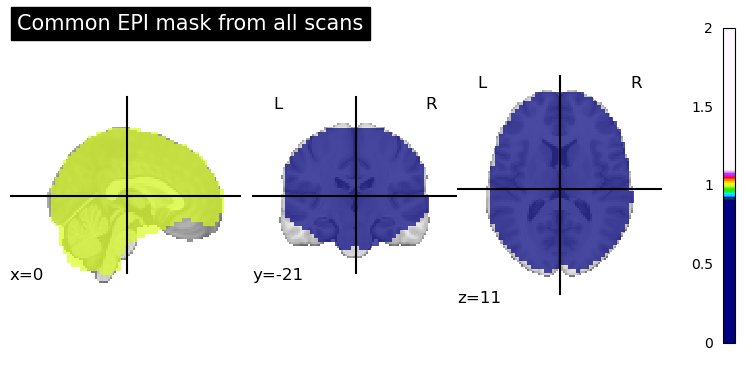

In [5]:
# Use ALL scans
fmri_imgs = meta_df["file_path"].tolist()

print(f"Number of scans used for mask + ICA: {len(fmri_imgs)}")

# Compute common mask from your own 190 scans only
common_mask_img = compute_multi_epi_mask(
    fmri_imgs,
    lower_cutoff=0.2,
    upper_cutoff=0.85,
    connected=True,
    opening=2,
    threshold=0.7,
    n_jobs=1
)

# Save mask
mask_path = OUT_DIR / "common_epi_mask_from_all_scans.nii.gz"
common_mask_img.to_filename(str(mask_path))

print("Saved common mask to:")
print(mask_path)

# Quick visualization
plotting.plot_roi(common_mask_img, title="Common EPI mask from all scans")

In [ ]:
img = nib.load(str(nii_files[0]))
print(img.header.get_zooms())  
print(img.shape)               

(np.float32(4.0), np.float32(4.0), np.float32(4.0), np.float32(1.0))
(45, 54, 45, 220)


## Group ICA

In [7]:
n_jobs = max(1, (os.cpu_count() or 2) - 1)

canica = CanICA(
    n_components=20,
    mask=common_mask_img,             # use your own mask
    smoothing_fwhm=None,
    n_jobs=n_jobs,
    standardize="zscore_sample",
    threshold="auto",
    n_init=10,
    random_state=42,
    memory=str(OUT_DIR / "nilearn_cache"),
    memory_level=1,
    verbose=10
)

print("Fitting group ICA on ALL scans with data-driven common mask...")
canica.fit(fmri_imgs)
print("Group ICA finished.")

Fitting group ICA on ALL scans with data-driven common mask...
[CanICA.fit] Loading mask from Nifti1Image('common_epi_mask_fr...')
[CanICA.fit] Resampling mask
[CanICA.fit] Finished fit
[CanICA.fit] Loading data
[CanICA.fit] Computing image from signals


[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   3 out of  10 | elapsed:    0.3s remaining:    0.7s
[Parallel(n_jobs=11)]: Done   5 out of  10 | elapsed:    0.3s remaining:    0.3s
[Parallel(n_jobs=11)]: Done   7 out of  10 | elapsed:    0.4s remaining:    0.2s


[CanICA.fit] Computing image from signals
Group ICA finished.


[Parallel(n_jobs=11)]: Done  10 out of  10 | elapsed:    0.7s finished


### Save

In [8]:
components_img = canica.components_img_

components_path = OUT_DIR / "group_ica_components_20_data_mask.nii.gz"
components_img.to_filename(str(components_path))

print("Saved ICA components to:")
print(components_path)

Saved ICA components to:
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/group_ica_components_20_data_mask.nii.gz


In [9]:
print("Mask shape:", common_mask_img.shape)
print("Mask affine:\n", common_mask_img.affine)

Mask shape: (45, 54, 45)
Mask affine:
 [[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]


In [10]:
n_components = 20

for k in range(n_components):
    comp_img = index_img(components_img, k)

    stat_display = plotting.plot_stat_map(
        comp_img,
        title=f"ICA component {k+1}",
        display_mode="z",
        cut_coords=7,
        colorbar=True
    )

    out_png = OUT_DIR / f"ICA_component_{k+1:02d}.png"
    stat_display.savefig(str(out_png))
    stat_display.close()

print("Saved all component plots.")

Saved all component plots.


## Visualization

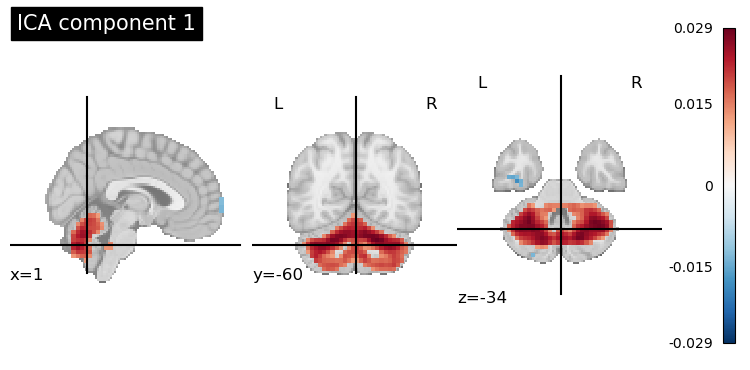

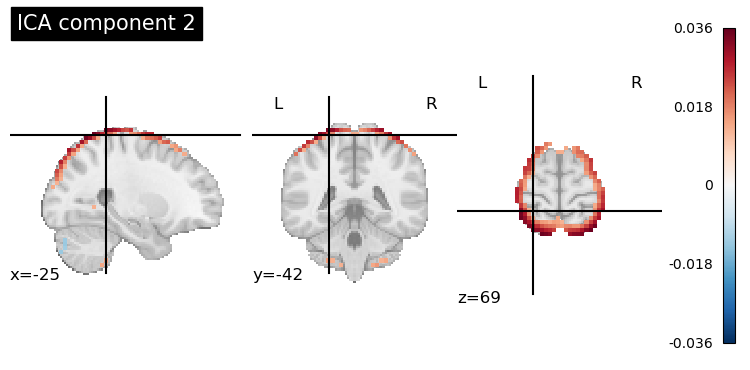

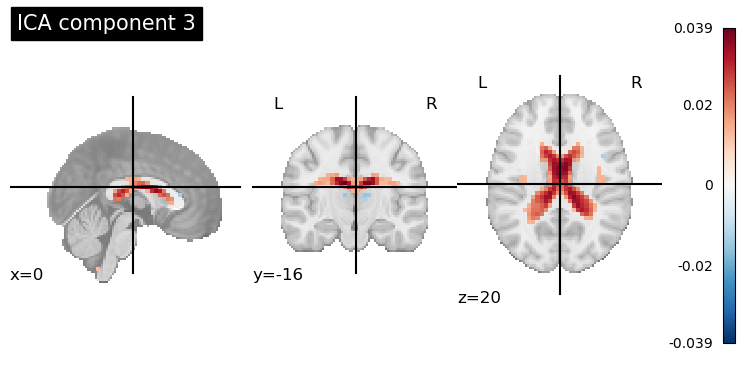

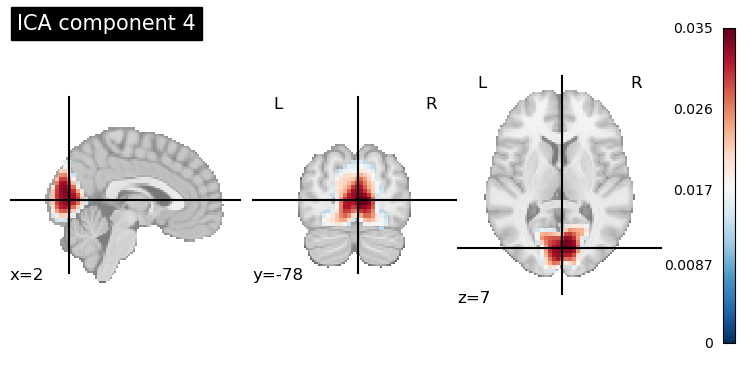

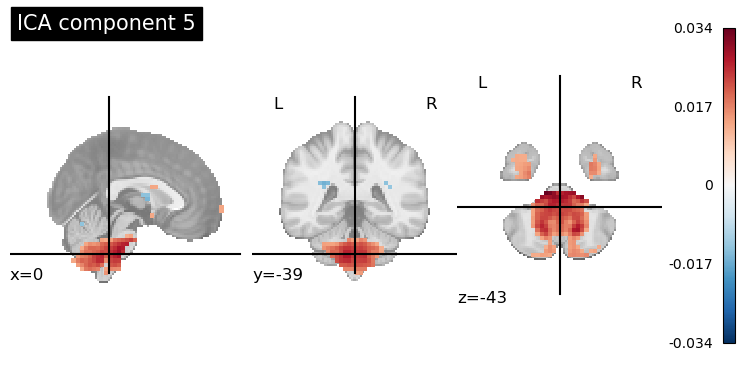

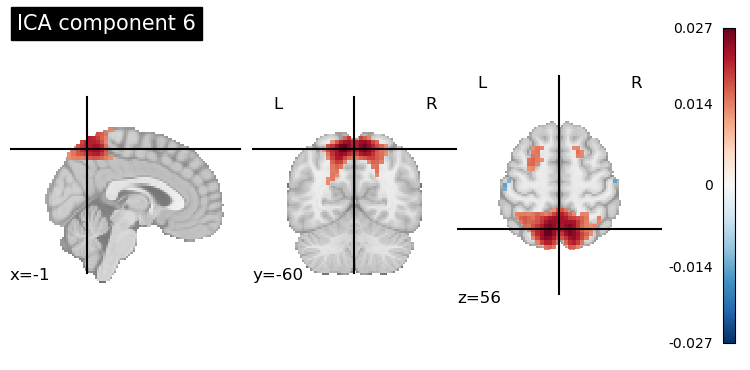

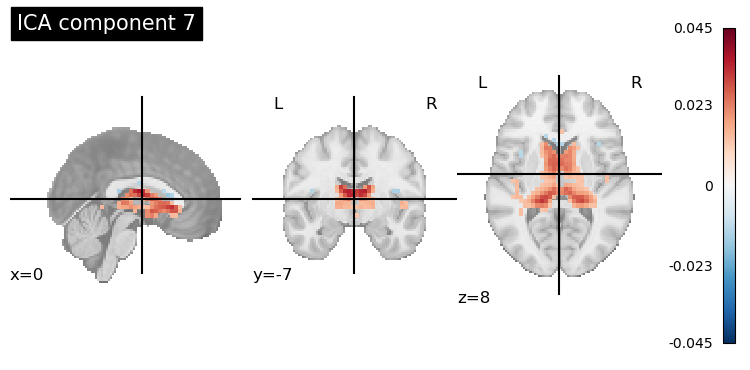

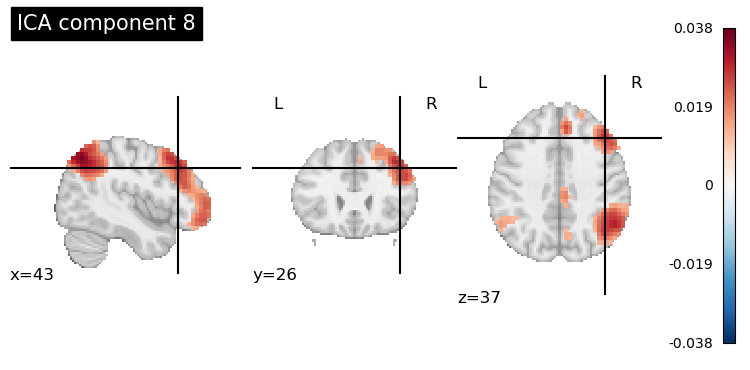

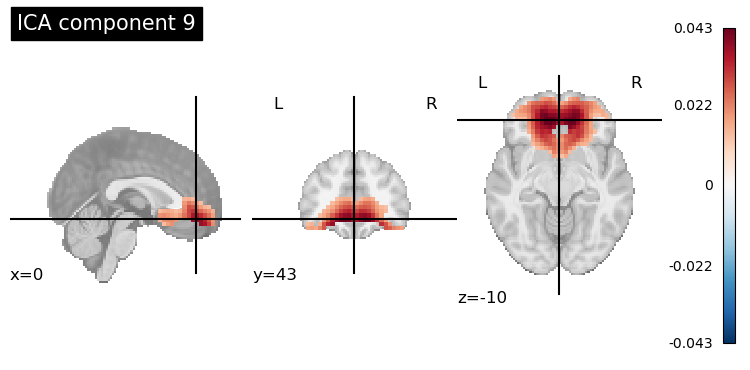

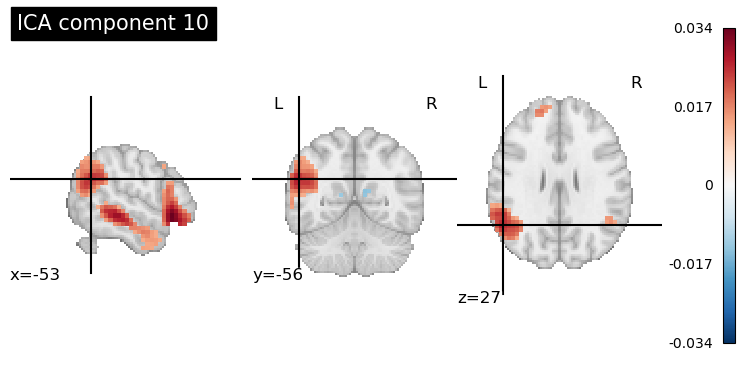

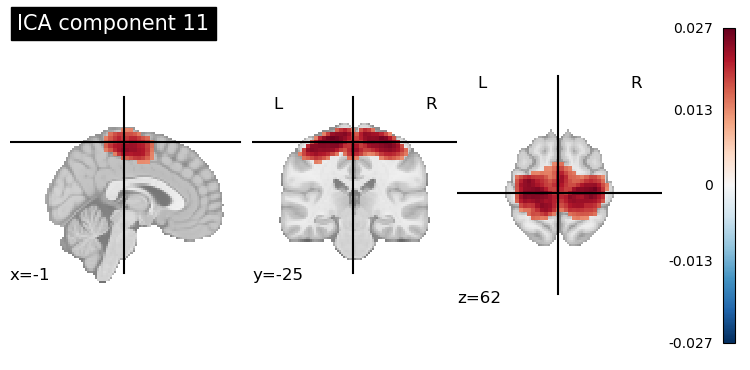

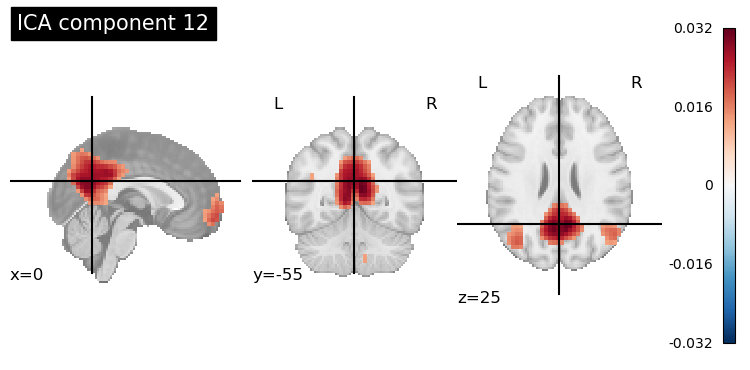

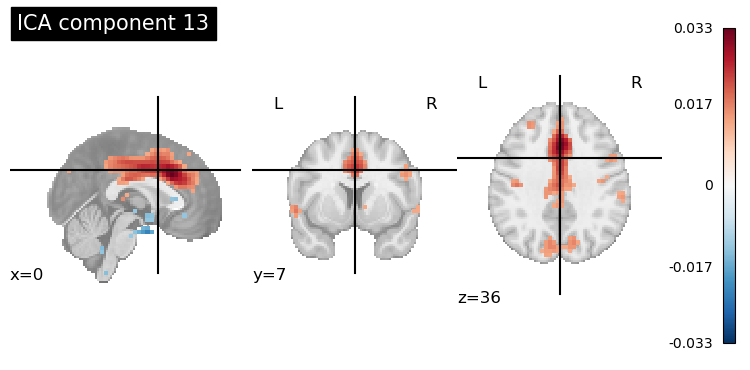

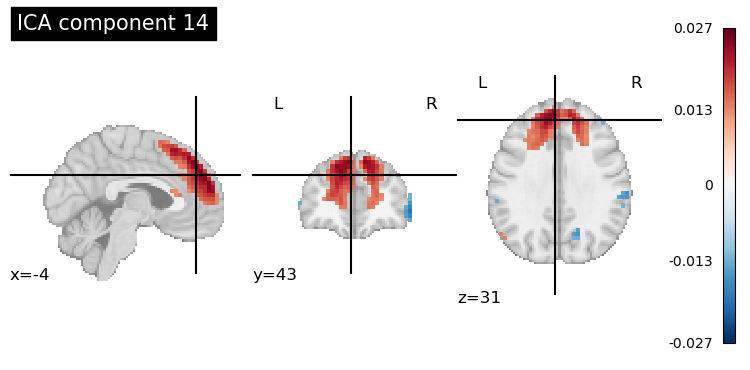

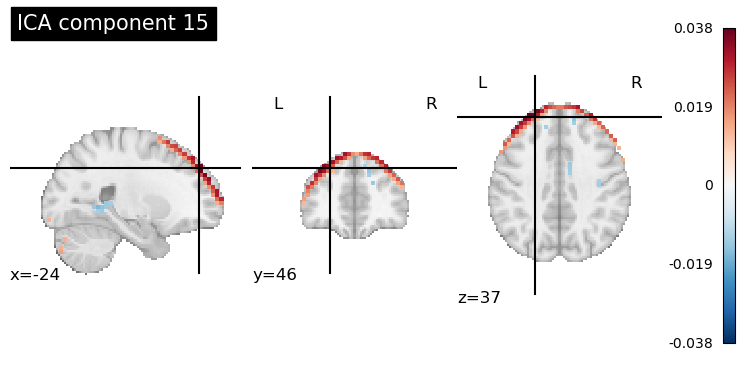

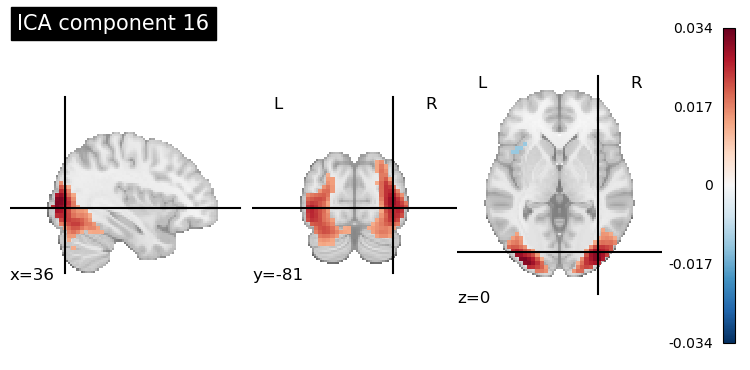

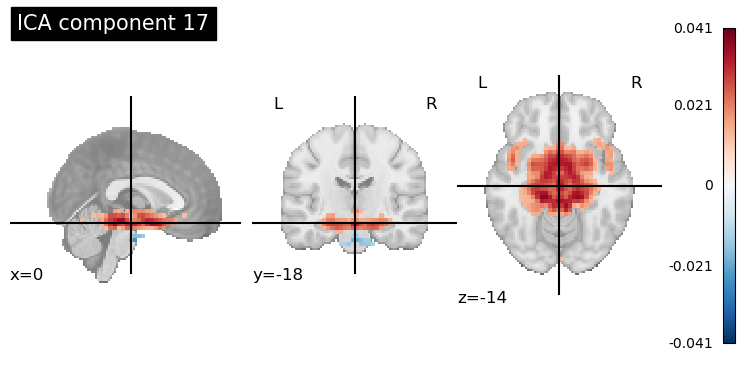

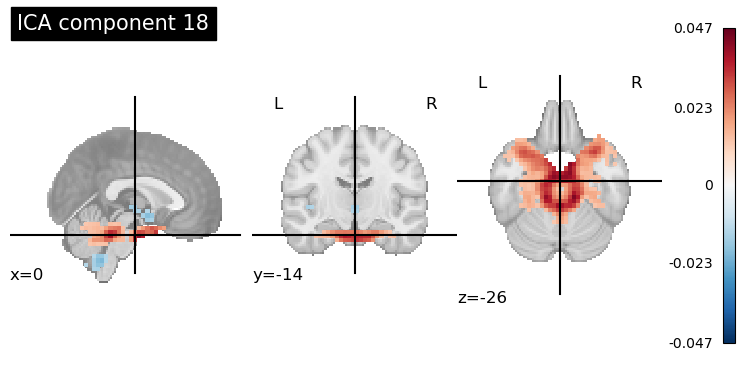

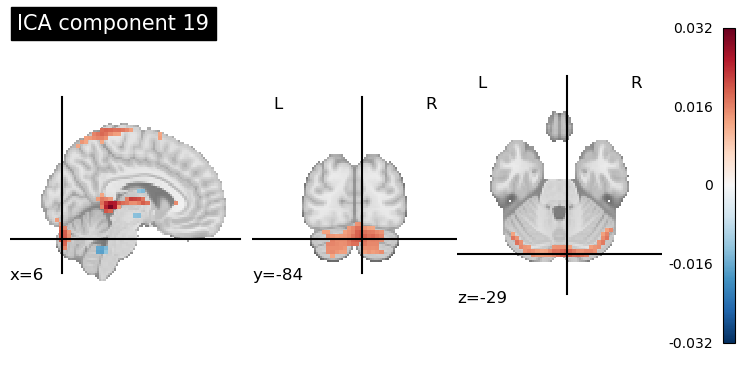

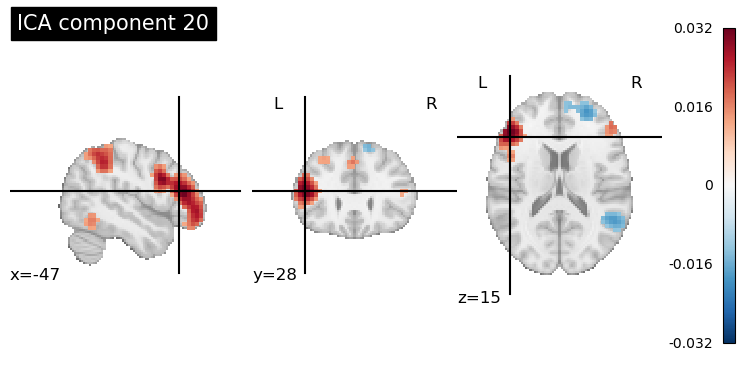

In [ ]:
n_components = 20

for k in range(n_components):
    comp_img = index_img(components_img, k)

    stat_display = plotting.plot_stat_map(
        comp_img,
        title=f"ICA component {k+1}",
        display_mode="ortho",
        colorbar=True
        
    )
    plt.show()

# Dual regression

In [ ]:
TR = 2.2
N_COMPONENTS = 20

OUT_STEP1 = os.path.join(OUT_DIR, "dualreg_step1_timecourses")
os.makedirs(OUT_STEP1, exist_ok=True)

# -----------------------------------
# 1) Use the same mask as group ICA
# -----------------------------------
mask_img = common_mask_img

# Build masker: transform 4D image -> (time x voxels)
masker = NiftiMasker(
    mask_img=mask_img,
    detrend=False,
    standardize=False,    
    t_r=TR
)

# -----------------------------------
# 2) Convert 20 ICA spatial maps into matrix S
# -----------------------------------
# components_img is 4D image: (x, y, z, 20)
# output S shape: (20, n_voxels)
S = masker.fit_transform(components_img)


S = zscore(S, axis=1, ddof=1)                               
S = np.nan_to_num(S, nan=0.0)                              


# S_pinv shape: (n_voxels, n_components)
# S_pinv = np.linalg.pinv(S @ S.T) @ S
S_pinv = np.linalg.pinv(S) 

print("✅ Spatial regressors matrix S shape:", S.shape)
print("✅ S_pinv shape:", S_pinv.shape)

✅ Spatial regressors matrix S shape: (20, 27380)
✅ S_pinv shape: (27380, 20)


## Spatial Regression

In [ ]:
# -----------------------------------
# 3) Spatial regression for each scan
# -----------------------------------
all_rows = []

for _, row in meta_df.iterrows():
    f = row["file_path"]
    file_name = row["file_name"]

    subj_scan_id = file_name.replace(".nii.gz", "").replace(".nii", "")

    img = nib.load(f)


    X_raw = masker.transform(img)                     # shape: (T, n_voxels)

    
    X = zscore(X_raw, axis=0, ddof=1)
    X = np.nan_to_num(X, nan=0.0)

    # Spatial regression:  subject-specific timecourses A
    A = X @ S_pinv

    cols = [f"IC{str(i+1).zfill(2)}" for i in range(N_COMPONENTS)]
    df = pd.DataFrame(A, columns=cols)

    out_tsv = os.path.join(OUT_STEP1, f"{subj_scan_id}_step1_timecourses.tsv")
    df.to_csv(out_tsv, sep="\t", index=False)

    all_rows.append({
        "file_name": row["file_name"],
        "file_path": row["file_path"],
        "group": row["group"],
        "subject_id": row["subject_id"],
        "scan_id": row["scan_id"],
        "timeseries_tsv": out_tsv,
        "n_timepoints": A.shape[0],
        "n_components": A.shape[1]
    })

timeseries_meta_df = pd.DataFrame(all_rows)
timeseries_meta_path = os.path.join(OUT_STEP1, "step1_timecourses_metadata.csv")
timeseries_meta_df.to_csv(timeseries_meta_path, index=False)

print(f"✅ Done. Saved timecourses to: {OUT_STEP1}")
print(f"✅ Saved metadata to: {timeseries_meta_path}")

✅ Done. Saved timecourses to: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/dualreg_step1_timecourses
✅ Saved metadata to: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/dualreg_step1_timecourses/step1_timecourses_metadata.csv


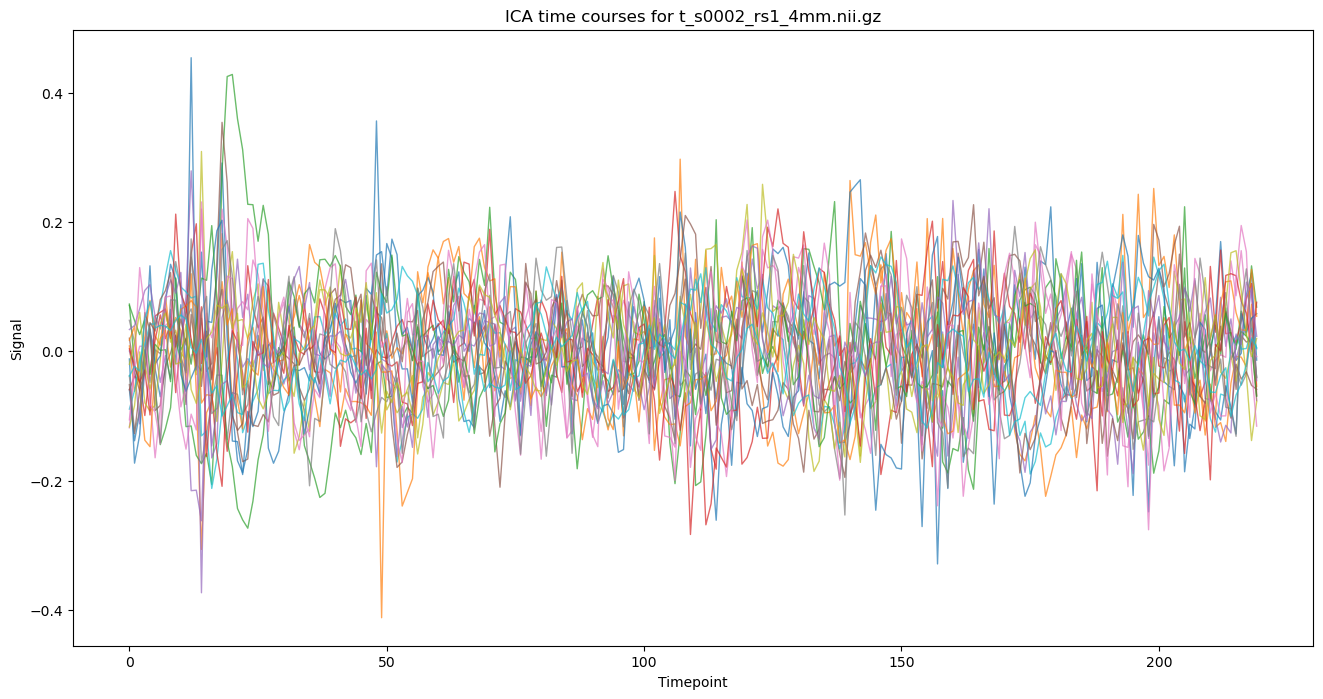

In [14]:
example_path = timeseries_meta_df.loc[0, "timeseries_tsv"]
example_name = timeseries_meta_df.loc[0, "file_name"]

example_df = pd.read_csv(example_path, sep="\t")

plt.figure(figsize=(16, 8))
for col in example_df.columns:
    plt.plot(example_df.index, example_df[col], alpha=0.7, linewidth=1)

plt.title(f"ICA time courses for {example_name}")
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.show()

Example scan: t_s0002_rs1_4mm.nii.gz
Shape: (220, 20)
       IC01      IC02      IC03      IC04      IC05      IC06      IC07  \
0 -0.058903  0.008373  0.073123 -0.059357  0.000535  0.020291 -0.118223   
1 -0.138257 -0.061913 -0.022877 -0.038392 -0.027564 -0.032970 -0.025203   
2 -0.094444 -0.029332 -0.050121 -0.046027 -0.112109 -0.061404  0.007899   
3 -0.005465  0.022405 -0.004005 -0.099189 -0.033295  0.060192  0.008000   
4  0.132249  0.078836  0.030507 -0.027530  0.027660  0.032386 -0.069982   

       IC08      IC09      IC10      IC11      IC12      IC13      IC14  \
0  0.047977 -0.116884 -0.089243 -0.011764  0.017388  0.071132  0.003808   
1  0.014474 -0.083913 -0.060882 -0.172838  0.038667  0.047792 -0.021902   
2 -0.045723 -0.000860 -0.013745 -0.128919 -0.058528  0.025918 -0.047725   
3  0.002427 -0.079748  0.011882 -0.005652 -0.137350  0.049394 -0.028932   
4 -0.048035 -0.092340  0.042576  0.034414 -0.147333 -0.035588 -0.098300   

       IC15      IC16      IC17      IC18   

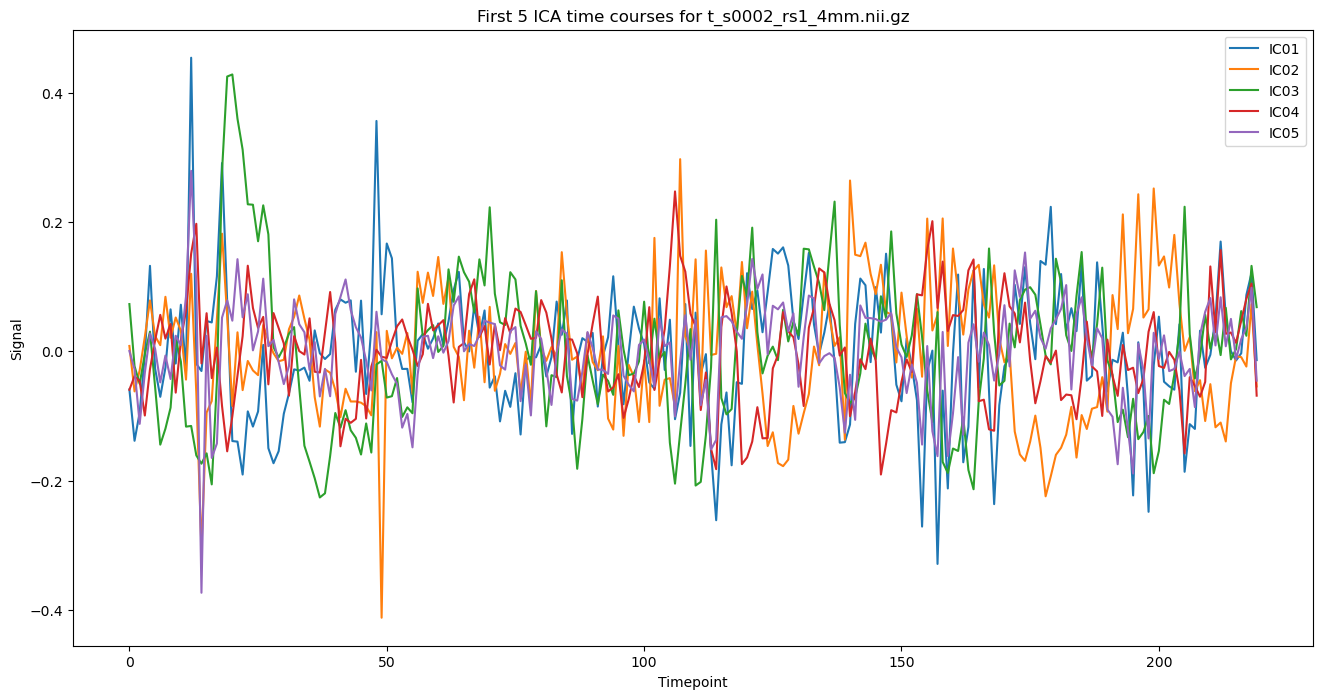

In [15]:
example_path = timeseries_meta_df.loc[0, "timeseries_tsv"]
example_name = timeseries_meta_df.loc[0, "file_name"]

example_df = pd.read_csv(example_path, sep="\t")

print("Example scan:", example_name)
print("Shape:", example_df.shape)
print(example_df.head())

plt.figure(figsize=(16, 8))
for col in example_df.columns[:5]:
    plt.plot(example_df.index, example_df[col], label=col, linewidth=1.5)

plt.title(f"First 5 ICA time courses for {example_name}")
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.legend()
plt.show()

# FC matrices

In [16]:
OUT_STATIC_FC = os.path.join(OUT_DIR, "ica_static_fc")
os.makedirs(OUT_STATIC_FC, exist_ok=True)

OUT_STATIC_FC_MAT = os.path.join(OUT_STATIC_FC, "fc_matrices")
os.makedirs(OUT_STATIC_FC_MAT, exist_ok=True)

OUT_STATIC_FC_VEC = os.path.join(OUT_STATIC_FC, "fc_vectors")
os.makedirs(OUT_STATIC_FC_VEC, exist_ok=True)

## Definition of FC

In [17]:
def compute_static_fc_from_timeseries(ts_df):
    """
    Input:
        ts_df: pandas DataFrame, shape = (timepoints, n_components)
               columns like IC01, IC02, ..., IC20

    Output:
        fc_mat: numpy array, shape = (n_components, n_components)
    """
    ts = ts_df.values  # (T, n_components)

    # correlation across components
    # rowvar=False means columns are variables/components
    fc_mat = np.corrcoef(ts, rowvar=False)
    fc_mat = np.clip(fc_mat, -0.999999, 0.999999)
    fc_mat = np.arctanh(fc_mat)

    return fc_mat

In [18]:
def flatten_upper_triangle(mat, include_diagonal=False):
    """
    Input:
        mat: square matrix, shape = (n, n)

    Output:
        vec: upper triangle as 1D vector
    """
    n = mat.shape[0]

    if include_diagonal:
        triu_idx = np.triu_indices(n, k=0)
    else:
        triu_idx = np.triu_indices(n, k=1)

    vec = mat[triu_idx]
    return vec, triu_idx

In [19]:
N_COMPONENTS = 20

feature_names = []
for i in range(N_COMPONENTS):
    for j in range(i + 1, N_COMPONENTS):
        feature_names.append(f"IC{str(i+1).zfill(2)}__IC{str(j+1).zfill(2)}")

print("Number of FC features:", len(feature_names))
print(feature_names[:10])

Number of FC features: 190
['IC01__IC02', 'IC01__IC03', 'IC01__IC04', 'IC01__IC05', 'IC01__IC06', 'IC01__IC07', 'IC01__IC08', 'IC01__IC09', 'IC01__IC10', 'IC01__IC11']


In [20]:
all_fc_rows = []

for _, row in timeseries_meta_df.iterrows():
    tsv_path = row["timeseries_tsv"]
    file_name = row["file_name"]

    subj_scan_id = file_name.replace(".nii.gz", "").replace(".nii", "")

    # -----------------------------------
    # 1) read time series
    # -----------------------------------
    ts_df = pd.read_csv(tsv_path, sep="\t")

    # safety check
    if ts_df.shape[1] != N_COMPONENTS:
        raise ValueError(
            f"{file_name}: expected {N_COMPONENTS} components, got {ts_df.shape[1]}"
        )

    # -----------------------------------
    # 2) compute static FC matrix
    # -----------------------------------
    fc_mat = compute_static_fc_from_timeseries(ts_df)

    # -----------------------------------
    # 3) save FC matrix
    # -----------------------------------
    fc_mat_path = os.path.join(
        OUT_STATIC_FC_MAT,
        f"{subj_scan_id}_ica_static_fc_matrix.npy"
    )
    np.save(fc_mat_path, fc_mat)

    # optional: save as csv for easy viewing
    fc_mat_csv_path = os.path.join(
        OUT_STATIC_FC_MAT,
        f"{subj_scan_id}_ica_static_fc_matrix.csv"
    )
    fc_mat_df = pd.DataFrame(
        fc_mat,
        index=[f"IC{str(i+1).zfill(2)}" for i in range(N_COMPONENTS)],
        columns=[f"IC{str(i+1).zfill(2)}" for i in range(N_COMPONENTS)]
    )
    fc_mat_df.to_csv(fc_mat_csv_path)

    # -----------------------------------
    # 4) flatten upper triangle
    # -----------------------------------
    fc_vec, _ = flatten_upper_triangle(fc_mat, include_diagonal=False)

    # save vector
    fc_vec_path = os.path.join(
        OUT_STATIC_FC_VEC,
        f"{subj_scan_id}_ica_static_fc_vector.npy"
    )
    np.save(fc_vec_path, fc_vec)

    # -----------------------------------
    # 5) store row for final feature table
    # -----------------------------------
    row_dict = {
        "file_name": row["file_name"],
        "file_path": row["file_path"],
        "group": row["group"],
        "subject_id": row["subject_id"],
        "scan_id": row["scan_id"],
        "timeseries_tsv": row["timeseries_tsv"],
        "fc_matrix_npy": fc_mat_path,
        "fc_vector_npy": fc_vec_path
    }

    for fname, fval in zip(feature_names, fc_vec):
        row_dict[fname] = fval

    all_fc_rows.append(row_dict)

print("Done computing ICA-based static FC for all scans.")

Done computing ICA-based static FC for all scans.


In [21]:
ica_static_fc_df = pd.DataFrame(all_fc_rows)

fc_feature_table_path = os.path.join(OUT_STATIC_FC, "ica_static_fc_features.csv")
ica_static_fc_df.to_csv(fc_feature_table_path, index=False)

print("Saved FC feature table to:")
print(fc_feature_table_path)

print("Shape of feature table:", ica_static_fc_df.shape)
print(ica_static_fc_df[["file_name", "group", "subject_id", "scan_id"]].head())

Saved FC feature table to:
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/ica_static_fc/ica_static_fc_features.csv
Shape of feature table: (190, 198)
                file_name group subject_id  scan_id
0  t_s0002_rs1_4mm.nii.gz   THC      s0002        1
1  t_s0002_rs2_4mm.nii.gz   THC      s0002        2
2  t_s0002_rs3_4mm.nii.gz   THC      s0002        3
3  t_s0002_rs4_4mm.nii.gz   THC      s0002        4
4  t_s0002_rs5_4mm.nii.gz   THC      s0002        5


## check one scan

Example scan: t_s0002_rs1_4mm.nii.gz
FC matrix shape: (20, 20)
[[ 7.25432862e+00 -1.25410242e-01 -3.13017350e-03 -2.38925555e-02
   5.48422185e-01  3.94840995e-01  3.23987224e-01  2.02555874e-01
  -7.37837622e-02 -5.49861626e-02  6.72821856e-02  2.64800176e-01
   2.05124921e-01  7.89668151e-02 -3.02012308e-01  1.26463537e-01
   1.54318141e-01  5.51945311e-01  8.11964617e-02  5.89728376e-02]
 [-1.25410242e-01  7.25432862e+00 -6.56531414e-02  6.42939899e-02
   1.21084086e-02  1.23965595e-01 -3.02362196e-01 -2.78741967e-02
  -2.05617869e-01  4.28820419e-01  2.75984747e-01  7.35617011e-02
  -2.50088246e-01 -2.56731275e-01  5.48919038e-01  4.36410471e-01
  -1.22245522e-01 -5.19959744e-02 -1.83781275e-01  1.26107833e-01]
 [-3.13017350e-03 -6.56531414e-02  7.25432862e+00 -2.34150721e-01
   3.68216274e-01  6.47620690e-02  3.95479107e-01  1.67785125e-01
   1.43435735e-02 -3.34388004e-01 -2.23087316e-01  2.28611798e-01
  -3.38627948e-01  1.96541391e-01 -3.78743378e-02 -4.96859589e-01
   1.579292

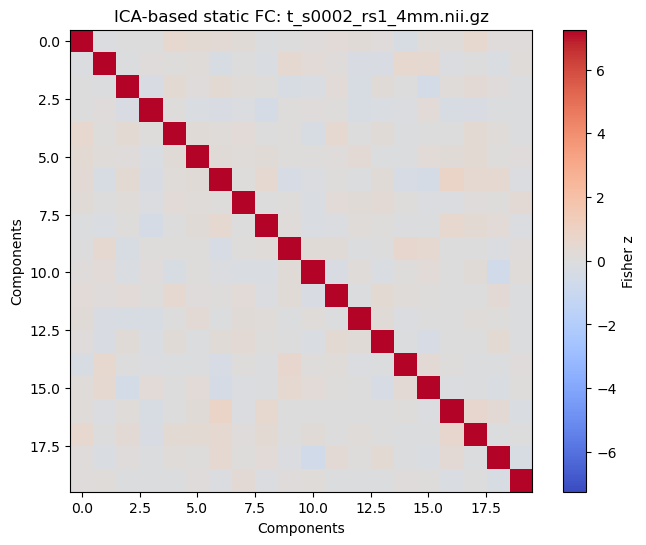

In [ ]:
example_fc_path = ica_static_fc_df.loc[0, "fc_matrix_npy"]
example_name = ica_static_fc_df.loc[0, "file_name"]

example_fc = np.load(example_fc_path)

print("Example scan:", example_name)
print("FC matrix shape:", example_fc.shape)
print(example_fc)

plt.figure(figsize=(8, 6))


vmax = np.abs(example_fc[~np.isinf(example_fc)]).max()

plt.imshow(example_fc, cmap="coolwarm", vmin=-vmax, vmax=vmax)
plt.colorbar(label="Fisher z")   
plt.title(f"ICA-based static FC: {example_name}")
plt.xlabel("Components")
plt.ylabel("Components")
plt.show()

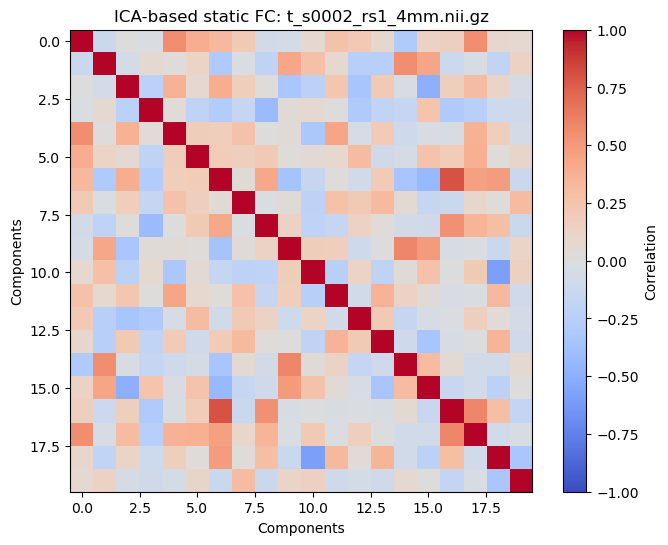

In [23]:
plt.figure(figsize=(8, 6))
plt.imshow(example_fc, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title(f"ICA-based static FC: {example_name}")
plt.xlabel("Components")
plt.ylabel("Components")
plt.show()

In [24]:
meta_cols = [
    "file_name", "file_path", "group", "subject_id", "scan_id",
    "timeseries_tsv", "fc_matrix_npy", "fc_vector_npy"
]

X_static_ica = ica_static_fc_df[feature_names].values
y_static_ica = ica_static_fc_df["group"].values
groups_static_ica = ica_static_fc_df["subject_id"].values
scan_ids_static_ica = ica_static_fc_df["scan_id"].values

print("X_static_ica shape:", X_static_ica.shape)
print("y_static_ica shape:", y_static_ica.shape)
print("groups_static_ica shape:", groups_static_ica.shape)
print("Unique scan IDs:", np.unique(scan_ids_static_ica))

X_static_ica shape: (190, 190)
y_static_ica shape: (190,)
groups_static_ica shape: (190,)
Unique scan IDs: [1 2 3 4 5 6 7 8]


# FC dynamic

In [25]:
# =========================================================
# Output folders
# =========================================================
OUT_DYNAMIC_FC = os.path.join(OUT_DIR, "ica_dynamic_fc")
os.makedirs(OUT_DYNAMIC_FC, exist_ok=True)

OUT_DYNAMIC_FC_MAT = os.path.join(OUT_DYNAMIC_FC, "window_fc_matrices")
os.makedirs(OUT_DYNAMIC_FC_MAT, exist_ok=True)

OUT_DYNAMIC_FC_VEC = os.path.join(OUT_DYNAMIC_FC, "dynamic_fc_vectors")
os.makedirs(OUT_DYNAMIC_FC_VEC, exist_ok=True)

# =========================================================
# Parameters
# =========================================================
N_COMPONENTS = 20

# window length and step size in TRs
WINDOW_TR = 50
STEP_TR = 5

# whether to apply Fisher z transform to correlations
USE_FISHER_Z = True

## Function Definition

In [26]:
def flatten_upper_triangle(mat, include_diagonal=False):
    """
    Input:
        mat: square matrix, shape = (n, n)

    Output:
        vec: upper triangle as 1D vector
    """
    n = mat.shape[0]

    if include_diagonal:
        triu_idx = np.triu_indices(n, k=0)
    else:
        triu_idx = np.triu_indices(n, k=1)

    vec = mat[triu_idx]
    return vec, triu_idx

In [27]:
def fisher_z_transform(fc_mat):
    """
    Apply Fisher z transform to correlation matrix.
    Diagonal will be kept as 1 before transform, but since we only
    use upper triangle without diagonal later, this is mainly for stability.
    """
    fc_mat = np.clip(fc_mat, -0.999999, 0.999999)
    z_mat = np.arctanh(fc_mat)
    return z_mat

In [28]:
def compute_dynamic_fc_matrices(ts_df, window_tr=WINDOW_TR, step_tr=STEP_TR, use_fisher_z=USE_FISHER_Z):
    """
    Compute sliding-window FC matrices from ICA time series.

    Input:
        ts_df: pandas DataFrame, shape = (T, n_components)
        window_tr: window length
        step_tr: step size
        use_fisher_z: whether to apply Fisher z transform

    Output:
        fc_mats: numpy array, shape = (n_windows, n_components, n_components)
    """
    ts = ts_df.values
    T, n_components = ts.shape

    if T < window_tr:
        raise ValueError(
            f"Timepoints ({T}) are smaller than window_tr ({window_tr})."
        )

    fc_mats = []

    for start in range(0, T - window_tr + 1, step_tr):
        end = start + window_tr
        window_ts = ts[start:end, :]

        fc_mat = np.corrcoef(window_ts, rowvar=False)

        if use_fisher_z:
            fc_mat = fisher_z_transform(fc_mat)

        fc_mats.append(fc_mat)

    fc_mats = np.stack(fc_mats, axis=0)
    return fc_mats

In [29]:
def compute_dynamic_fc_feature_vector(fc_mats, include_diagonal=False):
    """
    Convert a series of window FC matrices into one dynamic FC feature vector.

    Method:
        1) flatten upper triangle of each window FC matrix
        2) compute std across windows for each edge

    Input:
        fc_mats: numpy array, shape = (n_windows, n_components, n_components)

    Output:
        dyn_fc_vec: numpy array, shape = (n_edges,)
        window_fc_vecs: numpy array, shape = (n_windows, n_edges)
    """
    window_fc_vecs = []

    for k in range(fc_mats.shape[0]):
        fc_vec, _ = flatten_upper_triangle(
            fc_mats[k], include_diagonal=include_diagonal
        )
        window_fc_vecs.append(fc_vec)

    window_fc_vecs = np.stack(window_fc_vecs, axis=0)

    # std across windows for each connection
    dyn_fc_vec = np.std(window_fc_vecs, axis=0, ddof=1) # 求std

    return dyn_fc_vec, window_fc_vecs


## Compute FC dynamic

In [30]:
# =========================================================
# Feature names
# =========================================================
feature_names = []
for i in range(N_COMPONENTS):
    for j in range(i + 1, N_COMPONENTS):
        feature_names.append(f"IC{str(i+1).zfill(2)}__IC{str(j+1).zfill(2)}")

print("Number of dynamic FC features:", len(feature_names))
print(feature_names[:10])


# =========================================================
# Main loop
# =========================================================
all_dynamic_fc_rows = []

for _, row in timeseries_meta_df.iterrows():
    tsv_path = row["timeseries_tsv"]
    file_name = row["file_name"]

    subj_scan_id = file_name.replace(".nii.gz", "").replace(".nii", "")

    # -----------------------------------
    # 1) read time series
    # -----------------------------------
    ts_df = pd.read_csv(tsv_path, sep="\t")

    # safety check
    if ts_df.shape[1] != N_COMPONENTS:
        raise ValueError(
            f"{file_name}: expected {N_COMPONENTS} components, got {ts_df.shape[1]}"
        )

    # -----------------------------------
    # 2) compute dynamic FC matrices
    # -----------------------------------
    fc_mats = compute_dynamic_fc_matrices(
        ts_df,
        window_tr=WINDOW_TR,
        step_tr=STEP_TR,
        use_fisher_z=USE_FISHER_Z
    )

    # save all window FC matrices
    fc_mats_path = os.path.join(
        OUT_DYNAMIC_FC_MAT,
        f"{subj_scan_id}_ica_dynamic_fc_matrices.npy"
    )
    np.save(fc_mats_path, fc_mats)

    # -----------------------------------
    # 3) compute dynamic FC feature vector
    # -----------------------------------
    dyn_fc_vec, window_fc_vecs = compute_dynamic_fc_feature_vector(
        fc_mats,
        include_diagonal=False
    )

    # save dynamic FC vector
    dyn_fc_vec_path = os.path.join(
        OUT_DYNAMIC_FC_VEC,
        f"{subj_scan_id}_ica_dynamic_fc_std_vector.npy"
    )
    np.save(dyn_fc_vec_path, dyn_fc_vec)

    # optional: also save per-window flattened FC vectors
    window_fc_vecs_path = os.path.join(
        OUT_DYNAMIC_FC_VEC,
        f"{subj_scan_id}_ica_window_fc_vectors.npy"
    )
    np.save(window_fc_vecs_path, window_fc_vecs)

    # -----------------------------------
    # 4) store row for final feature table
    # -----------------------------------
    row_dict = {
        "file_name": row["file_name"],
        "file_path": row["file_path"],
        "group": row["group"],
        "subject_id": row["subject_id"],
        "scan_id": row["scan_id"],
        "timeseries_tsv": row["timeseries_tsv"],
        "window_fc_matrices_npy": fc_mats_path,
        "window_fc_vectors_npy": window_fc_vecs_path,
        "dynamic_fc_vector_npy": dyn_fc_vec_path,
        "n_windows": fc_mats.shape[0],
        "window_tr": WINDOW_TR,
        "step_tr": STEP_TR,
        "use_fisher_z": USE_FISHER_Z
    }

    for fname, fval in zip(feature_names, dyn_fc_vec):
        row_dict[fname] = fval

    all_dynamic_fc_rows.append(row_dict)

print("Done computing ICA-based dynamic FC for all scans.")

ica_dynamic_fc_df = pd.DataFrame(all_dynamic_fc_rows)

dynamic_fc_feature_table_path = os.path.join(
    OUT_DYNAMIC_FC,
    "ica_dynamic_fc_features.csv"
)
ica_dynamic_fc_df.to_csv(dynamic_fc_feature_table_path, index=False)

print("Saved dynamic FC feature table to:")
print(dynamic_fc_feature_table_path)

print("Shape of dynamic FC feature table:", ica_dynamic_fc_df.shape)
print(ica_dynamic_fc_df[["file_name", "group", "subject_id", "scan_id", "n_windows"]].head())

Number of dynamic FC features: 190
['IC01__IC02', 'IC01__IC03', 'IC01__IC04', 'IC01__IC05', 'IC01__IC06', 'IC01__IC07', 'IC01__IC08', 'IC01__IC09', 'IC01__IC10', 'IC01__IC11']
Done computing ICA-based dynamic FC for all scans.
Saved dynamic FC feature table to:
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/ica_dynamic_fc/ica_dynamic_fc_features.csv
Shape of dynamic FC feature table: (190, 203)
                file_name group subject_id  scan_id  n_windows
0  t_s0002_rs1_4mm.nii.gz   THC      s0002        1         35
1  t_s0002_rs2_4mm.nii.gz   THC      s0002        2         35
2  t_s0002_rs3_4mm.nii.gz   THC      s0002        3         35
3  t_s0002_rs4_4mm.nii.gz   THC      s0002        4         35
4  t_s0002_rs5_4mm.nii.gz   THC      s0002        5         35


# ALFF/fALFF

ALFF_DIR: /Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/alff_falff_maps

Loaded common mask from:
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/common_epi_mask_from_all_scans.nii.gz
Common mask shape: (45, 54, 45)

Parameters:
TR = 2.2
LOW_F = 0.01
HIGH_F = 0.1
DETREND = True
REMOVE_MEAN = True


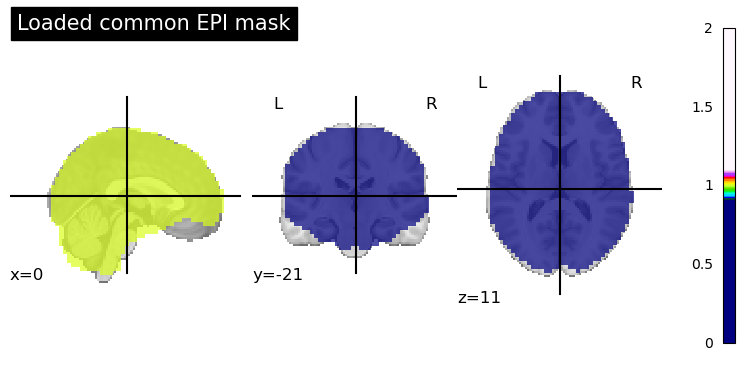

In [31]:
# =========================================================
# Compute ALFF and fALFF for each scan using existing common mask
# =========================================================

# -----------------------------
# Set paths
# -----------------------------
ALFF_DIR = OUT_DIR / "alff_falff_maps"
ALFF_DIR.mkdir(exist_ok=True, parents=True)

print("ALFF_DIR:", ALFF_DIR)

# =========================================================
# Load the existing common mask from group ICA step
# =========================================================
mask_path = OUT_DIR / "common_epi_mask_from_all_scans.nii.gz"
common_mask_img = load_img(mask_path)

print("\nLoaded common mask from:")
print(mask_path)
print("Common mask shape:", common_mask_img.shape)

plotting.plot_roi(common_mask_img, title="Loaded common EPI mask")

# =========================================================
# Parameters for ALFF / fALFF
# =========================================================
TR = 2.2
LOW_F = 0.01
HIGH_F = 0.1
DETREND = True
REMOVE_MEAN = True

print("\nParameters:")
print("TR =", TR)
print("LOW_F =", LOW_F)
print("HIGH_F =", HIGH_F)
print("DETREND =", DETREND)
print("REMOVE_MEAN =", REMOVE_MEAN)

In [32]:
# =========================================================
# Helper functions
# =========================================================

def detrend_timeseries(ts_2d):
    """
    Remove linear trend from each row (voxel) time series.

    Parameters
    ----------
    ts_2d : ndarray, shape (n_voxels, n_timepoints)

    Returns
    -------
    ts_detrended : ndarray, shape (n_voxels, n_timepoints)
    """
    n_voxels, n_tp = ts_2d.shape

    x = np.arange(n_tp, dtype=np.float64)
    x_mean = x.mean()
    x_centered = x - x_mean
    denom = np.sum(x_centered ** 2)

    y_mean = ts_2d.mean(axis=1, keepdims=True)
    slopes = np.sum((ts_2d - y_mean) * x_centered[None, :], axis=1, keepdims=True) / denom
    trends = y_mean + slopes * x_centered[None, :]

    ts_detrended = ts_2d - trends
    return ts_detrended


def compute_alff_falff_from_4d(
    img,
    mask_img,
    tr,
    low_f=0.01,
    high_f=0.08,
    detrend=True,
    remove_mean=True
):
    """
    Compute ALFF and fALFF for one 4D fMRI scan under a given common mask.

    Parameters
    ----------
    img : 4D Niimg-like object
        Input fMRI image.
    mask_img : 3D Niimg-like object
        Common brain mask.
    tr : float
        Repetition time in seconds.
    low_f : float
        Lower bound of low-frequency band.
    high_f : float
        Upper bound of low-frequency band.
    detrend : bool
        Whether to remove linear trend first.
    remove_mean : bool
        Whether to remove voxelwise mean before FFT.

    Returns
    -------
    alff_img : Nifti1Image
    falff_img : Nifti1Image
    alff_vals : ndarray, shape (n_voxels,)
    falff_vals : ndarray, shape (n_voxels,)
    freqs : ndarray
    """
    # -----------------------------------------------------
    # 1) extract voxel time series inside common mask
    # apply_mask output shape = (n_timepoints, n_voxels)
    # -----------------------------------------------------
    ts = apply_mask(img, mask_img)

    # transpose to (n_voxels, n_timepoints)
    ts = ts.T.astype(np.float64)

    n_voxels, n_tp = ts.shape

    if n_tp < 2:
        raise ValueError("Not enough time points for FFT.")

    # -----------------------------------------------------
    # 2) optional preprocessing
    # -----------------------------------------------------
    if detrend:
        ts = detrend_timeseries(ts)

    if remove_mean:
        ts = ts - ts.mean(axis=1, keepdims=True)

    # -----------------------------------------------------
    # 3) FFT
    # -----------------------------------------------------
    fft_vals = np.fft.rfft(ts, axis=1)
    amp = np.abs(fft_vals)

    freqs = np.fft.rfftfreq(n_tp, d=tr)

    # full band excluding 0 Hz
    nonzero_mask = freqs > 0

    # low-frequency band
    lf_mask = (freqs >= low_f) & (freqs <= high_f)

    if lf_mask.sum() == 0:
        raise ValueError(
            f"No frequency bins found in [{low_f}, {high_f}] Hz. "
            f"Check TR and scan length."
        )

    # -----------------------------------------------------
    # 4) ALFF and fALFF
    # -----------------------------------------------------
    # ALFF = sum of amplitudes in low-frequency band
    low_amp_sum = amp[:, lf_mask].sum(axis=1)
    alff_vals = low_amp_sum

    # fALFF = low-frequency amplitude sum / total non-zero amplitude sum
    full_amp_sum = amp[:, nonzero_mask].sum(axis=1)

    falff_vals = np.divide(
        low_amp_sum,
        full_amp_sum,
        out=np.zeros_like(low_amp_sum),
        where=full_amp_sum > 0
    )

    # -----------------------------------------------------
    # 5) convert vector back to 3D maps
    # -----------------------------------------------------
    alff_img = unmask(alff_vals, mask_img)
    falff_img = unmask(falff_vals, mask_img)

    return alff_img, falff_img, alff_vals, falff_vals, freqs

In [33]:
# =========================================================
# Compute ALFF / fALFF for all scans
# =========================================================

summary_rows = []
alff_feature_rows = []
falff_feature_rows = []

for i, row in meta_df.iterrows():
    file_name = row["file_name"]
    file_path = row["file_path"]
    group = row["group"]
    subject_id = row["subject_id"]
    scan_id = row["scan_id"]

    print(f"[{i+1}/{len(meta_df)}] Processing: {file_name}")

    try:
        # ---------------------------------------------
        # 1) load 4D image
        # ---------------------------------------------
        img = load_img(file_path)

        if len(img.shape) != 4:
            raise ValueError(f"{file_name} is not 4D. shape={img.shape}")

        # ---------------------------------------------
        # 2) compute ALFF / fALFF under common mask
        # ---------------------------------------------
        alff_img, falff_img, alff_vals, falff_vals, freqs = compute_alff_falff_from_4d(
            img=img,
            mask_img=common_mask_img,
            tr=TR,
            low_f=LOW_F,
            high_f=HIGH_F,
            detrend=DETREND,
            remove_mean=REMOVE_MEAN
        )

        # ---------------------------------------------
        # 3) save NIfTI maps
        # ---------------------------------------------
        base_name = file_name.replace(".nii.gz", "")

        alff_map_path = ALFF_DIR / f"{base_name}_alff.nii.gz"
        falff_map_path = ALFF_DIR / f"{base_name}_falff.nii.gz"

        alff_img.to_filename(str(alff_map_path))
        falff_img.to_filename(str(falff_map_path))

        # ---------------------------------------------
        # 4) save summary row
        # ---------------------------------------------
        summary_rows.append({
            "file_name": file_name,
            "file_path": file_path,
            "group": group,
            "subject_id": subject_id,
            "scan_id": scan_id,
            "n_timepoints": img.shape[3],
            "n_mask_voxels": len(alff_vals),
            "alff_mean": float(np.mean(alff_vals)),
            "alff_std": float(np.std(alff_vals)),
            "alff_min": float(np.min(alff_vals)),
            "alff_max": float(np.max(alff_vals)),
            "falff_mean": float(np.mean(falff_vals)),
            "falff_std": float(np.std(falff_vals)),
            "falff_min": float(np.min(falff_vals)),
            "falff_max": float(np.max(falff_vals)),
            "alff_map_path": str(alff_map_path),
            "falff_map_path": str(falff_map_path)
        })

        # ---------------------------------------------
        # 5) save feature rows
        # each scan = one row
        # ---------------------------------------------
        alff_row = {
            "file_name": file_name,
            "group": group,
            "subject_id": subject_id,
            "scan_id": scan_id
        }

        falff_row = {
            "file_name": file_name,
            "group": group,
            "subject_id": subject_id,
            "scan_id": scan_id
        }

        for j, val in enumerate(alff_vals):
            alff_row[f"alff_vox_{j}"] = float(val)

        for j, val in enumerate(falff_vals):
            falff_row[f"falff_vox_{j}"] = float(val)

        alff_feature_rows.append(alff_row)
        falff_feature_rows.append(falff_row)

    except Exception as e:
        print(f"Error processing {file_name}: {e}")

        summary_rows.append({
            "file_name": file_name,
            "file_path": file_path,
            "group": group,
            "subject_id": subject_id,
            "scan_id": scan_id,
            "n_timepoints": np.nan,
            "n_mask_voxels": np.nan,
            "alff_mean": np.nan,
            "alff_std": np.nan,
            "alff_min": np.nan,
            "alff_max": np.nan,
            "falff_mean": np.nan,
            "falff_std": np.nan,
            "falff_min": np.nan,
            "falff_max": np.nan,
            "alff_map_path": np.nan,
            "falff_map_path": np.nan
        })

# =========================================================
# Convert results to DataFrames
# =========================================================

alff_summary_df = pd.DataFrame(summary_rows)
alff_feature_df = pd.DataFrame(alff_feature_rows)
falff_feature_df = pd.DataFrame(falff_feature_rows)

print("\nalff_summary_df shape:", alff_summary_df.shape)
display(alff_summary_df.head())

print("\nalff_feature_df shape:", alff_feature_df.shape)
display(alff_feature_df.iloc[:5, :10])

print("\nfalff_feature_df shape:", falff_feature_df.shape)
display(falff_feature_df.iloc[:5, :10])

# =========================================================
# Save results
# =========================================================

summary_path = OUT_DIR / "alff_falff_summary.csv"
alff_feature_path = OUT_DIR / "alff_features_common_mask.csv"
falff_feature_path = OUT_DIR / "falff_features_common_mask.csv"

alff_summary_df.to_csv(summary_path, index=False)
alff_feature_df.to_csv(alff_feature_path, index=False)
falff_feature_df.to_csv(falff_feature_path, index=False)

print("\nSaved summary to:")
print(summary_path)

print("\nSaved ALFF features to:")
print(alff_feature_path)

print("\nSaved fALFF features to:")
print(falff_feature_path)

[1/190] Processing: t_s0002_rs1_4mm.nii.gz
[2/190] Processing: t_s0002_rs2_4mm.nii.gz
[3/190] Processing: t_s0002_rs3_4mm.nii.gz
[4/190] Processing: t_s0002_rs4_4mm.nii.gz
[5/190] Processing: t_s0002_rs5_4mm.nii.gz
[6/190] Processing: t_s0002_rs6_4mm.nii.gz
[7/190] Processing: t_s0002_rs7_4mm.nii.gz
[8/190] Processing: t_s0002_rs8_4mm.nii.gz
[9/190] Processing: t_s0004_rs1_4mm.nii.gz
[10/190] Processing: t_s0004_rs2_4mm.nii.gz
[11/190] Processing: t_s0004_rs3_4mm.nii.gz
[12/190] Processing: t_s0004_rs4_4mm.nii.gz
[13/190] Processing: t_s0004_rs5_4mm.nii.gz
[14/190] Processing: t_s0004_rs6_4mm.nii.gz
[15/190] Processing: t_s0004_rs7_4mm.nii.gz
[16/190] Processing: t_s0004_rs8_4mm.nii.gz
[17/190] Processing: t_s0007_rs1_4mm.nii.gz
[18/190] Processing: t_s0007_rs2_4mm.nii.gz
[19/190] Processing: t_s0007_rs3_4mm.nii.gz
[20/190] Processing: t_s0007_rs4_4mm.nii.gz
[21/190] Processing: t_s0007_rs5_4mm.nii.gz
[22/190] Processing: t_s0007_rs6_4mm.nii.gz
[23/190] Processing: t_s0007_rs7_4mm.nii.

,file_name,file_path,group,subject_id,scan_id,n_timepoints,n_mask_voxels,alff_mean,alff_std,alff_min,alff_max,falff_mean,falff_std,falff_min,falff_max,alff_map_path,falff_map_path
0,t_s0002_rs1_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,THC,s0002,1,220,27380,50121.028307,30345.121333,0.000000,497289.443862,0.541363,0.062531,0.000000,0.740237,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...
1,t_s0002_rs2_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,THC,s0002,2,220,27380,38424.715949,21003.690079,0.000000,405884.334892,0.478686,0.072926,0.000000,0.763542,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...
2,t_s0002_rs3_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,THC,s0002,3,220,27380,45342.723784,31691.343574,0.000000,735439.805841,0.522562,0.062771,0.000000,0.744936,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...
3,t_s0002_rs4_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,THC,s0002,4,220,27380,33970.109266,18990.774579,383.487962,429819.095500,0.454120,0.061930,0.245697,0.680162,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...
4,t_s0002_rs5_4mm.nii.gz,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,THC,s0002,5,220,27380,41905.000236,30712.011095,0.000000,695569.921741,0.523975,0.067211,0.000000,0.742331,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...,/Users/dumengpro/Desktop/Leiden Uni/fmri/group...



alff_feature_df shape: (190, 27384)


,file_name,group,subject_id,scan_id,alff_vox_0,alff_vox_1,alff_vox_2,alff_vox_3,alff_vox_4,alff_vox_5
0,t_s0002_rs1_4mm.nii.gz,THC,s0002,1,43241.162651,24610.111900,34540.123213,35101.996244,29648.890138,28941.868397
1,t_s0002_rs2_4mm.nii.gz,THC,s0002,2,25340.407981,33286.938981,24790.031389,22365.422644,29972.119399,24829.902001
2,t_s0002_rs3_4mm.nii.gz,THC,s0002,3,26954.430267,21591.048130,25635.774261,25610.268021,26069.168147,32754.086382
3,t_s0002_rs4_4mm.nii.gz,THC,s0002,4,19731.416631,16222.837001,20091.671760,25553.104487,17879.404900,17552.473695
4,t_s0002_rs5_4mm.nii.gz,THC,s0002,5,24976.230032,26320.521180,25877.569427,24760.130398,30216.105312,23378.463261



falff_feature_df shape: (190, 27384)


,file_name,group,subject_id,scan_id,falff_vox_0,falff_vox_1,falff_vox_2,falff_vox_3,falff_vox_4,falff_vox_5
0,t_s0002_rs1_4mm.nii.gz,THC,s0002,1,0.552538,0.495633,0.537616,0.495325,0.510223,0.531535
1,t_s0002_rs2_4mm.nii.gz,THC,s0002,2,0.446580,0.552676,0.485884,0.335468,0.503762,0.481758
2,t_s0002_rs3_4mm.nii.gz,THC,s0002,3,0.483585,0.483338,0.551214,0.538041,0.450797,0.499841
3,t_s0002_rs4_4mm.nii.gz,THC,s0002,4,0.475806,0.543759,0.481372,0.400494,0.493100,0.441581
4,t_s0002_rs5_4mm.nii.gz,THC,s0002,5,0.496323,0.493053,0.603261,0.521090,0.518189,0.560466



Saved summary to:
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/alff_falff_summary.csv

Saved ALFF features to:
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/alff_features_common_mask.csv

Saved fALFF features to:
/Users/dumengpro/Desktop/Leiden Uni/fmri/groupanalysis/THC/group_ica_results/falff_features_common_mask.csv


In [34]:
# =========================================================
# Quick checks
# =========================================================

print("\nNumber of successful scans:",
      alff_summary_df["alff_map_path"].notna().sum())

print("\nALFF mean summary:")
print(alff_summary_df["alff_mean"].describe())

print("\nfALFF mean summary:")
print(alff_summary_df["falff_mean"].describe())

print("\nMean ALFF by group:")
print(alff_summary_df.groupby("group")["alff_mean"].mean())

print("\nMean fALFF by group:")
print(alff_summary_df.groupby("group")["falff_mean"].mean())


Number of successful scans: 190

ALFF mean summary:
count       190.000000
mean      49263.984089
std       11588.366075
min       32144.336896
25%       41642.874458
50%       46419.968074
75%       54830.243687
max      134607.387228
Name: alff_mean, dtype: float64

fALFF mean summary:
count    190.000000
mean       0.505366
std        0.032579
min        0.431349
25%        0.483325
50%        0.507710
75%        0.523022
max        0.604089
Name: falff_mean, dtype: float64

Mean ALFF by group:
group
THC        48263.104307
placebo    50286.159186
Name: alff_mean, dtype: float64

Mean fALFF by group:
group
THC        0.495996
placebo    0.514936
Name: falff_mean, dtype: float64


# Fairest comparison

In [35]:
print("scan_id of each subject:")
print(meta_df.groupby(["subject_id", "group"])["scan_id"].apply(list).to_string())

scan_id of each subject:
subject_id  group  
s0002       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7, 8]
s0004       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7, 8]
s0007       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7, 8]
s0008       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7, 8]
s0009       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7, 8]
s0010       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo          [1, 2, 3, 4, 5, 6]
s0101       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7, 8]
s0103       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7, 8]
s0105       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7, 8]
s0106       THC        [1, 2, 3, 4, 5, 6, 7, 8]
            placebo    [1, 2, 3, 4, 5, 6, 7

In [36]:
# select scan_id = 2, 4, 6
selected_scans = [2, 4, 6]
mask = ica_static_fc_df["scan_id"].isin(selected_scans)

print("Scan number:")
print(f"总计：{mask.sum()}")
print(ica_static_fc_df[mask]["group"].value_counts())
print("\n scan of each subject:")
print(ica_static_fc_df[mask].groupby(["subject_id","group"])["scan_id"].apply(list).to_string())


Scan number:
总计：72
group
THC        36
placebo    36
Name: count, dtype: int64

 scan of each subject:
subject_id  group  
s0002       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0004       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0007       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0008       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0009       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0010       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0101       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0103       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0105       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0106       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0112       THC        [2, 4, 6]
            placebo    [2, 4, 6]
s0511       THC        [2, 4, 6]
            placebo    [2, 4, 6]


## FC only

### AUC

In [ ]:
# =========================================================
# 1)  scan_id = 2, 4, 6
# =========================================================
selected_scans = [2, 4, 6]
mask = ica_static_fc_df["scan_id"].isin(selected_scans)

fairest_static_df = ica_static_fc_df[mask].reset_index(drop=True)

print("scan number after selection:", fairest_static_df.shape[0])
print(fairest_static_df["group"].value_counts())


static_fc_cols = [c for c in fairest_static_df.columns if c.startswith("IC")]
X_static_fairest = fairest_static_df[static_fc_cols].values
print("\nX_static_fairest shape:", X_static_fairest.shape)


y      = fairest_static_df["group"].values
groups = fairest_static_df["subject_id"].values


label_map = {"placebo": 0, "THC": 1}
y_encoded = np.array([label_map[label] for label in y])

print("Label mapping:", label_map)
print("Unique subjects:", len(np.unique(groups)))
print("\nClass distribution:")
print(pd.Series(y).value_counts())


param_grid = {
    "elasticnet__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
print(f"\n number combination: {6*5} ")


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_fairest_static = []
best_params_per_fold_fairest_static = []
best_estimators_per_fold_fairest_static = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_static_fairest, y_encoded, groups=groups)
):
    X_train, X_test = X_static_fairest[train_idx], X_static_fairest[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leak"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train subject ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test subject ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain:")
    train_labels = ["THC" if l == 1 else "placebo" for l in y_train]
    print(pd.Series(train_labels).value_counts())
    print("\nTest:")
    test_labels = ["THC" if l == 1 else "placebo" for l in y_test]
    print(pd.Series(test_labels).value_counts())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_fairest_static.append(best_params)
    best_estimators_per_fold_fairest_static.append(grid_search.best_estimator_)

    print(f"\n optimal inner CV parameters: {best_params}")
    print(f"optimal inner CV AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_fairest_static.append(auc)

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "THC"])) 


print("\n" + "="*50)
print("Fairest comparison static FC classification result（StratifiedGroupKFold nested CV）：")
print(f"Mean AUC: {np.mean(fold_results_fairest_static):.4f}")
print(f"Std  AUC: {np.std(fold_results_fairest_static):.4f}")

print("\n each fold best parameter:")
for fold, params in enumerate(best_params_per_fold_fairest_static):
    print(f"  Fold {fold+1}: {params}")

real_auc_fairest_static = np.mean(fold_results_fairest_static)
print(f"\n saved Fairest comparison static FC AUC: {real_auc_fairest_static:.4f}")

筛选后scan数量： 72
group
THC        36
placebo    36
Name: count, dtype: int64

X_static_fairest shape: (72, 190)
Label mapping: {'placebo': 0, 'THC': 1}
Unique subjects: 12

Class distribution:
THC        36
placebo    36
Name: count, dtype: int64

总参数组合数: 30 种

Fold 1
Train 被试 (9个): ['s0002', 's0004', 's0009', 's0010', 's0101', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0007', 's0008', 's0112']

Train 类别分布:
THC        27
placebo    27
Name: count, dtype: int64

Test 类别分布:
THC        9
placebo    9
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 1.0, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.9313
外层Test AUC: 0.9136
              precision    recall  f1-score   support

     placebo       1.00      0.56      0.71         9
         THC       0.69      1.00      0.82         9

    accuracy                           0.78        18
   macro avg       0.85      0.78      0.77        18
weighted avg       0.85      0.78      0.77        18


Fold 2
Train 被试 (9个): ['s0002', 's

In [ ]:

C_values  = [p["elasticnet__C"] for p in best_params_per_fold_fairest_static]
l1_values = [p["elasticnet__l1_ratio"] for p in best_params_per_fold_fairest_static]

print("5 fold C value:", C_values)
print("5 fold l1_ratio value:", l1_values)

best_C_mode  = Counter(C_values).most_common(1)[0][0]
best_l1_mode = Counter(l1_values).most_common(1)[0][0]

print(f"\nmethod 1 parameter: C={best_C_mode}, l1_ratio={best_l1_mode}")


final_clf_mode = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
        C=best_C_mode,
        l1_ratio=best_l1_mode
    ))
])
final_clf_mode.fit(X_static_fairest, y_encoded)
final_coef_mode = final_clf_mode.named_steps["elasticnet"].coef_[0]
print(f"beta shape: {final_coef_mode.shape}")



5折的C值: [1.0, 0.1, 0.5, 1.0, 0.1]
5折的l1_ratio值: [0.1, 0.3, 0.3, 0.3, 0.1]

方法1 选定参数: C=1.0, l1_ratio=0.3
方法1 最终模型训练完成，beta shape: (190,)


In [ ]:

best_fold_idx = np.argmax(fold_results_fairest_static)
best_params_auc = best_params_per_fold_fairest_static[best_fold_idx]

print(f"\nmethod2 highest AUC: Fold {best_fold_idx+1}")
print(f"AUC: {fold_results_fairest_static[best_fold_idx]:.4f}")
print(f"parameter: {best_params_auc}")


final_clf_auc = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
        C=best_params_auc["elasticnet__C"],
        l1_ratio=best_params_auc["elasticnet__l1_ratio"]
    ))
])
final_clf_auc.fit(X_static_fairest, y_encoded)
final_coef_auc = final_clf_auc.named_steps["elasticnet"].coef_[0]
print(f"method2 beta shape: {final_coef_auc.shape}")


方法2 最高AUC折: Fold 3
对应AUC: 1.0000
对应参数: {'elasticnet__C': 0.5, 'elasticnet__l1_ratio': 0.3}
方法2 最终模型训练完成，beta shape: (190,)


#### Permutation Test

In [ ]:

from sklearn.base import clone

real_auc = real_auc_fairest_static
print(f"\nreal Mean AUC: {real_auc:.4f}")


pair_check = (
    fairest_static_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)
print("each subject has session：")
print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 3]
if len(incomplete) == 0:
    print(f"\n✅ all of subject has 3 scan（scan 2,4,6）")
else:
    print(f"\n⚠️ subject following not completed：")
    print(incomplete)


row_groups  = fairest_static_df["group"].values
groups_full = fairest_static_df["subject_id"].values
X_full      = X_static_fairest
subject_ids = np.unique(groups_full)

def rebuild_fairest_labels(group_array):
    label_map = {"placebo": 0, "THC": 1}
    return np.array([label_map[label] for label in group_array])


n_permutations = 1000
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\nreal Mean AUC: {real_auc:.4f}")
print(f"permutation {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )


    y_permuted = rebuild_fairest_labels(perm_groups)

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_fairest_static[fold])
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5

        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"  finished {i+1}/{n_permutations} permutation")

# -----------------------------------

perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)
print("Permutation Test （Fairest comparison static FC）：")
print(f"real Mean AUC:     {real_auc:.4f}")
print(f"permutated Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p value:              {p_value:.4f}")

if p_value < 0.05:
    print("(p < 0.05")
else:
    print("p >= 0.05")


真实 Mean AUC: 0.8944
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        3
1       s0002  placebo        3
2       s0004      THC        3
3       s0004  placebo        3
4       s0007      THC        3
5       s0007  placebo        3
6       s0008      THC        3
7       s0008  placebo        3
8       s0009      THC        3
9       s0009  placebo        3
10      s0010      THC        3
11      s0010  placebo        3
12      s0101      THC        3
13      s0101  placebo        3
14      s0103      THC        3
15      s0103  placebo        3
16      s0105      THC        3
17      s0105  placebo        3
18      s0106      THC        3
19      s0106  placebo        3
20      s0112      THC        3
21      s0112  placebo        3
22      s0511      THC        3
23      s0511  placebo        3

✅ 所有subject均有完整的3个scan（scan 2,4,6）

真实 Mean AUC: 0.8944
开始置换检验，共 1000 次...
说明：以subject为单位整体交换placebo/THC标签，复用最优模型

  完成 100/1000 次置换
  完成 200/1000 次置换


## FC dynamic

### AUC

In [ ]:

selected_scans = [2, 4, 6]
mask = ica_dynamic_fc_df["scan_id"].isin(selected_scans)

fairest_dynamic_df = ica_dynamic_fc_df[mask].reset_index(drop=True)

print("scan number：", fairest_dynamic_df.shape[0])
print(fairest_dynamic_df["group"].value_counts())


dynamic_fc_cols = [c for c in fairest_dynamic_df.columns if c.startswith("IC")]
X_dynamic_fairest = fairest_dynamic_df[dynamic_fc_cols].values
print("\nX_dynamic_fairest shape:", X_dynamic_fairest.shape)

y      = fairest_dynamic_df["group"].values
groups = fairest_dynamic_df["subject_id"].values


label_map = {"placebo": 0, "THC": 1}
y_encoded = np.array([label_map[label] for label in y])

print("Label mapping:", label_map)
print("Unique subjects:", len(np.unique(groups)))
print("\nClass distribution:")
print(pd.Series(y).value_counts())


param_grid = {
    "elasticnet__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
print(f"\n number combination: {6*5} ")

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_fairest_dynamic = []
best_params_per_fold_fairest_dynamic = []
best_estimators_per_fold_fairest_dynamic = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_dynamic_fairest, y_encoded, groups=groups)
):
    X_train, X_test = X_dynamic_fairest[train_idx], X_dynamic_fairest[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked！"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test  ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    train_labels = ["THC" if l == 1 else "placebo" for l in y_train]
    print(pd.Series(train_labels).value_counts())
    print("\nTest :")
    test_labels = ["THC" if l == 1 else "placebo" for l in y_test]
    print(pd.Series(test_labels).value_counts())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_fairest_dynamic.append(best_params)
    best_estimators_per_fold_fairest_dynamic.append(grid_search.best_estimator_)

    print(f"\n: {best_params}")
    print(f": {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_fairest_dynamic.append(auc)

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "THC"]))  

# =========================================================
# 7) 汇总结果
# =========================================================
print("\n" + "="*50)
print("Fairest comparison dynamic FC （StratifiedGroupKFold nested CV）：")
print(f"Mean AUC: {np.mean(fold_results_fairest_dynamic):.4f}")
print(f"Std  AUC: {np.std(fold_results_fairest_dynamic):.4f}")

print("\n:")
for fold, params in enumerate(best_params_per_fold_fairest_dynamic):
    print(f"  Fold {fold+1}: {params}")

real_auc_fairest_dynamic = np.mean(fold_results_fairest_dynamic)
print(f"\n Fairest comparison dynamic FC AUC: {real_auc_fairest_dynamic:.4f}")

筛选后scan数量： 72
group
THC        36
placebo    36
Name: count, dtype: int64

X_dynamic_fairest shape: (72, 190)
Label mapping: {'placebo': 0, 'THC': 1}
Unique subjects: 12

Class distribution:
THC        36
placebo    36
Name: count, dtype: int64

总参数组合数: 30 种

Fold 1
Train 被试 (9个): ['s0002', 's0004', 's0009', 's0010', 's0101', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0007', 's0008', 's0112']

Train 类别分布:
THC        27
placebo    27
Name: count, dtype: int64

Test 类别分布:
THC        9
placebo    9
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.5, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.6597
外层Test AUC: 0.4198
              precision    recall  f1-score   support

     placebo       0.45      0.56      0.50         9
         THC       0.43      0.33      0.38         9

    accuracy                           0.44        18
   macro avg       0.44      0.44      0.44        18
weighted avg       0.44      0.44      0.44        18


Fold 2
Train 被试 (9个): ['s0002', '

### Permutation Test

In [ ]:

from sklearn.base import clone

real_auc = real_auc_fairest_dynamic
print(f"\n real Mean AUC: {real_auc:.4f}")


pair_check = (
    fairest_dynamic_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)

print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 3]
if len(incomplete) == 0:
    print(f"\n✅ （scan 2,4,6）")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_groups  = fairest_dynamic_df["group"].values
groups_full = fairest_dynamic_df["subject_id"].values
X_full      = X_dynamic_fairest
subject_ids = np.unique(groups_full)


def rebuild_fairest_labels(group_array):
    label_map = {"placebo": 0, "THC": 1}
    return np.array([label_map[label] for label in group_array])


n_permutations = 1000
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\nreal Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )


    y_permuted = rebuild_fairest_labels(perm_groups)

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_fairest_dynamic[fold])
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5

        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)
print("Permutation Test result（Fairest comparison dynamic FC）：")
print(f"real Mean AUC:     {real_auc:.4f}")
print(f"permu Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p value:              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05")
else:
    print("p >= 0.05")


真实 Mean AUC: 0.4673
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        3
1       s0002  placebo        3
2       s0004      THC        3
3       s0004  placebo        3
4       s0007      THC        3
5       s0007  placebo        3
6       s0008      THC        3
7       s0008  placebo        3
8       s0009      THC        3
9       s0009  placebo        3
10      s0010      THC        3
11      s0010  placebo        3
12      s0101      THC        3
13      s0101  placebo        3
14      s0103      THC        3
15      s0103  placebo        3
16      s0105      THC        3
17      s0105  placebo        3
18      s0106      THC        3
19      s0106  placebo        3
20      s0112      THC        3
21      s0112  placebo        3
22      s0511      THC        3
23      s0511  placebo        3

✅ 所有subject均有完整的3个scan（scan 2,4,6）

真实 Mean AUC: 0.4673
开始置换检验，共 1000 次...
说明：以subject为单位整体交换placebo/THC标签，复用最优模型

  完成 100/1000 次置换
  完成 200/1000 次置换


## ALFF

### AUC

In [ ]:


selected_scans = [2, 4, 6]
mask = falff_feature_df["scan_id"].isin(selected_scans)

fairest_falff_df = falff_feature_df[mask].reset_index(drop=True)

print(, fairest_falff_df.shape[0])
print(fairest_falff_df["group"].value_counts())


falff_cols = [c for c in fairest_falff_df.columns if c.startswith("falff_vox_")]
X_falff_fairest = fairest_falff_df[falff_cols].values
print("\nX_falff_fairest shape:", X_falff_fairest.shape)


y      = fairest_falff_df["group"].values
groups = fairest_falff_df["subject_id"].values


label_map = {"placebo": 0, "THC": 1}
y_encoded = np.array([label_map[label] for label in y])

print("Label mapping:", label_map)
print("Unique subjects:", len(np.unique(groups)))
print("\nClass distribution:")
print(pd.Series(y).value_counts())




param_grid = {
    "elasticnet__C": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_fairest_falff = []
best_params_per_fold_fairest_falff = []
best_estimators_per_fold_fairest_falff = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_falff_fairest, y_encoded, groups=groups)
):
    X_train, X_test = X_falff_fairest[train_idx], X_falff_fairest[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked！"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain:")
    train_labels = ["THC" if l == 1 else "placebo" for l in y_train]
    print(pd.Series(train_labels).value_counts())
    print("\nTest :")
    test_labels = ["THC" if l == 1 else "placebo" for l in y_test]
    print(pd.Series(test_labels).value_counts())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_fairest_falff.append(best_params)
    best_estimators_per_fold_fairest_falff.append(grid_search.best_estimator_)

    print(f"\n: {best_params}")
    print(f": {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_fairest_falff.append(auc)

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "THC"]))  

print("\n" + "="*50)

print(f"Mean AUC: {np.mean(fold_results_fairest_falff):.4f}")
print(f"Std  AUC: {np.std(fold_results_fairest_falff):.4f}")

print("\n:")
for fold, params in enumerate(best_params_per_fold_fairest_falff):
    print(f"  Fold {fold+1}: {params}")

real_auc_fairest_falff = np.mean(fold_results_fairest_falff)
print(f"\n Fairest comparison fALFF AUC: {real_auc_fairest_falff:.4f}")

筛选后scan数量： 72
group
THC        36
placebo    36
Name: count, dtype: int64

X_falff_fairest shape: (72, 27380)
Label mapping: {'placebo': 0, 'THC': 1}
Unique subjects: 12

Class distribution:
THC        36
placebo    36
Name: count, dtype: int64

Fold 1
Train 被试 (9个): ['s0002', 's0004', 's0009', 's0010', 's0101', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0007', 's0008', 's0112']

Train 类别分布:
THC        27
placebo    27
Name: count, dtype: int64

Test 类别分布:
THC        9
placebo    9
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.01, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.7346
外层Test AUC: 0.6790
              precision    recall  f1-score   support

     placebo       0.50      0.33      0.40         9
         THC       0.50      0.67      0.57         9

    accuracy                           0.50        18
   macro avg       0.50      0.50      0.49        18
weighted avg       0.50      0.50      0.49        18


Fold 2
Train 被试 (9个): ['s0002', 's0007', 's000

In [ ]:
print(falff_cols[:10])
print(f": {len(falff_cols)}")

['falff_vox_0', 'falff_vox_1', 'falff_vox_2', 'falff_vox_3', 'falff_vox_4', 'falff_vox_5', 'falff_vox_6', 'falff_vox_7', 'falff_vox_8', 'falff_vox_9']
总体素数: 27380


In [ ]:
import os


#### Permutation Test

In [ ]:

from sklearn.base import clone

real_auc = real_auc_fairest_falff
print(f"\n Mean AUC: {real_auc:.4f}")


pair_check = (
    fairest_falff_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)
print("subject session scan：")
print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 3]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_groups  = fairest_falff_df["group"].values
groups_full = fairest_falff_df["subject_id"].values
X_full      = X_falff_fairest
subject_ids = np.unique(groups_full)


def rebuild_fairest_labels(group_array):
    label_map = {"placebo": 0, "THC": 1}
    return np.array([label_map[label] for label in group_array])


n_permutations = 1000
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\nreal  Mean AUC: {real_auc:.4f}")



for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )


    y_permuted = rebuild_fairest_labels(perm_groups)

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_fairest_falff[fold])
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5

        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)

print(f"real Mean AUC:     {real_auc:.4f}")
print(f"permu Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p value:              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05")
else:
    print("p >= 0.05")


真实 Mean AUC: 0.7173
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        3
1       s0002  placebo        3
2       s0004      THC        3
3       s0004  placebo        3
4       s0007      THC        3
5       s0007  placebo        3
6       s0008      THC        3
7       s0008  placebo        3
8       s0009      THC        3
9       s0009  placebo        3
10      s0010      THC        3
11      s0010  placebo        3
12      s0101      THC        3
13      s0101  placebo        3
14      s0103      THC        3
15      s0103  placebo        3
16      s0105      THC        3
17      s0105  placebo        3
18      s0106      THC        3
19      s0106  placebo        3
20      s0112      THC        3
21      s0112  placebo        3
22      s0511      THC        3
23      s0511  placebo        3

✅ 所有subject均有完整的3个scan（scan 2,4,6）

真实 Mean AUC: 0.7173
开始置换检验，共 1000 次...
说明：以subject为单位整体交换placebo/THC标签，复用最优模型

  完成 100/1000 次置换
  完成 200/1000 次置换


## Combined

### AUC

In [ ]:

selected_scans = [2, 4, 6]

fairest_static_df = ica_static_fc_df[
    ica_static_fc_df["scan_id"].isin(selected_scans)
].reset_index(drop=True)

fairest_dynamic_df = ica_dynamic_fc_df[
    ica_dynamic_fc_df["scan_id"].isin(selected_scans)
].reset_index(drop=True)

fairest_falff_df = falff_feature_df[
    falff_feature_df["scan_id"].isin(selected_scans)
].reset_index(drop=True)

assert (fairest_static_df["file_name"].values ==
        fairest_dynamic_df["file_name"].values).all(), "静态FC和动态FC的 file_name 顺序不一致！"
assert (fairest_static_df["file_name"].values ==
        fairest_falff_df["file_name"].values).all(), "静态FC和 fALFF 的 file_name 顺序不一致！"
assert (fairest_static_df["subject_id"].values ==
        fairest_dynamic_df["subject_id"].values).all(), "静态FC和动态FC的 subject_id 不一致！"
assert (fairest_static_df["subject_id"].values ==
        fairest_falff_df["subject_id"].values).all(), "静态FC和 fALFF 的 subject_id 不一致！"
assert (fairest_static_df["group"].values ==
        fairest_dynamic_df["group"].values).all(), "静态FC和动态FC的 group 不一致！"
assert (fairest_static_df["group"].values ==
        fairest_falff_df["group"].values).all(), "静态FC和 fALFF 的 group 不一致！"

print("scan：", fairest_static_df.shape[0])
print(fairest_static_df["group"].value_counts())

static_fc_cols  = [c for c in fairest_static_df.columns if c.startswith("IC")]
X_static_fairest  = fairest_static_df[static_fc_cols].values

dynamic_fc_cols = [c for c in fairest_dynamic_df.columns if c.startswith("IC")]
X_dynamic_fairest = fairest_dynamic_df[dynamic_fc_cols].values

falff_cols      = [c for c in fairest_falff_df.columns if c.startswith("falff_vox_")]
X_falff_fairest   = fairest_falff_df[falff_cols].values

X_combined_fairest = np.hstack([
    X_static_fairest,
    X_dynamic_fairest,
    X_falff_fairest
])

print("\nX_static_fairest shape:",   X_static_fairest.shape)
print("X_dynamic_fairest shape:",    X_dynamic_fairest.shape)
print("X_falff_fairest shape:",      X_falff_fairest.shape)
print("X_combined_fairest shape:",   X_combined_fairest.shape)


y      = fairest_static_df["group"].values
groups = fairest_static_df["subject_id"].values


label_map = {"placebo": 0, "THC": 1}
y_encoded = np.array([label_map[label] for label in y])

print("\nLabel mapping:", label_map)
print("Unique subjects:", len(np.unique(groups)))
print("\nClass distribution:")
print(pd.Series(y).value_counts())




param_grid = {
    "elasticnet__C": [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_fairest_combined = []
best_params_per_fold_fairest_combined = []
best_estimators_per_fold_fairest_combined = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_combined_fairest, y_encoded, groups=groups)
):
    X_train, X_test = X_combined_fairest[train_idx], X_combined_fairest[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leak"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    train_labels = ["THC" if l == 1 else "placebo" for l in y_train]
    print(pd.Series(train_labels).value_counts())
    print("\nTest :")
    test_labels = ["THC" if l == 1 else "placebo" for l in y_test]
    print(pd.Series(test_labels).value_counts())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_fairest_combined.append(best_params)
    best_estimators_per_fold_fairest_combined.append(grid_search.best_estimator_)

    print(f"\ninner CV: {best_params}")
    print(f"AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_fairest_combined.append(auc)

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "THC"]))  


print("\n" + "="*50)
print("Fairest comparison Combined （StratifiedGroupKFold CV）：")
print(f"Mean AUC: {np.mean(fold_results_fairest_combined):.4f}")
print(f"Std  AUC: {np.std(fold_results_fairest_combined):.4f}")

print("\n:")
for fold, params in enumerate(best_params_per_fold_fairest_combined):
    print(f"  Fold {fold+1}: {params}")

real_auc_fairest_combined = np.mean(fold_results_fairest_combined)
print(f"\n Fairest comparison Combined AUC: {real_auc_fairest_combined:.4f}")

筛选后scan数量： 72
group
THC        36
placebo    36
Name: count, dtype: int64

X_static_fairest shape: (72, 190)
X_dynamic_fairest shape: (72, 190)
X_falff_fairest shape: (72, 27380)
X_combined_fairest shape: (72, 27760)

Label mapping: {'placebo': 0, 'THC': 1}
Unique subjects: 12

Class distribution:
THC        36
placebo    36
Name: count, dtype: int64

Fold 1
Train 被试 (9个): ['s0002', 's0004', 's0009', 's0010', 's0101', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0007', 's0008', 's0112']

Train 类别分布:
THC        27
placebo    27
Name: count, dtype: int64

Test 类别分布:
THC        9
placebo    9
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.1, 'elasticnet__l1_ratio': 0.7}
内层CV最优 AUC: 0.7647
外层Test AUC: 0.6667
              precision    recall  f1-score   support

     placebo       0.50      0.33      0.40         9
         THC       0.50      0.67      0.57         9

    accuracy                           0.50        18
   macro avg       0.50      0.50      0.49      

#### Permutation test

In [ ]:

from sklearn.base import clone

real_auc = real_auc_fairest_combined
print(f"\n真实 Mean AUC: {real_auc:.4f}")


pair_check = (
    fairest_static_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)

print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 3]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_groups  = fairest_static_df["group"].values
groups_full = fairest_static_df["subject_id"].values
X_full      = X_combined_fairest
subject_ids = np.unique(groups_full)


def rebuild_fairest_labels(group_array):
    label_map = {"placebo": 0, "THC": 1}
    return np.array([label_map[label] for label in group_array])


n_permutations = 1000
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\nreal Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )


    y_permuted = rebuild_fairest_labels(perm_groups)

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_fairest_combined[fold])
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5

        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)
print("Permutation Test （Fairest comparison Combined")
print(f" real Mean AUC:     {real_auc:.4f}")
print(f" Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p value:              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05)")
else:
    print("p >= 0.05)")


真实 Mean AUC: 0.7136
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        3
1       s0002  placebo        3
2       s0004      THC        3
3       s0004  placebo        3
4       s0007      THC        3
5       s0007  placebo        3
6       s0008      THC        3
7       s0008  placebo        3
8       s0009      THC        3
9       s0009  placebo        3
10      s0010      THC        3
11      s0010  placebo        3
12      s0101      THC        3
13      s0101  placebo        3
14      s0103      THC        3
15      s0103  placebo        3
16      s0105      THC        3
17      s0105  placebo        3
18      s0106      THC        3
19      s0106  placebo        3
20      s0112      THC        3
21      s0112  placebo        3
22      s0511      THC        3
23      s0511  placebo        3

✅ 所有subject均有完整的3个scan（scan 2,4,6）

真实 Mean AUC: 0.7136
开始置换检验，共 1000 次...
说明：以subject为单位整体交换placebo/THC标签，复用最优模型

  完成 100/1000 次置换
  完成 200/1000 次置换


KeyboardInterrupt: 

# Most scans

## FC

### AUC

In [ ]:

most_scans_df = ica_static_fc_df.copy()

def assign_label_most_scans(row):
    if row["group"] == "placebo":
        return 0
    else:
        if row["scan_id"] == 1:
            return 0
        else:
            return 1

most_scans_df["label"] = most_scans_df.apply(assign_label_most_scans, axis=1)

print("Most scans ：")
print(most_scans_df["label"].value_counts())
print(f"\nscan：{len(most_scans_df)}")
print(f"0（placebo）：{(most_scans_df['label']==0).sum()}")
print(f"1（drug）：{(most_scans_df['label']==1).sum()}")


static_fc_cols = [c for c in most_scans_df.columns if c.startswith("IC")]
X_static_most = most_scans_df[static_fc_cols].values
print("\nX_static_most shape:", X_static_most.shape)


y = most_scans_df["label"].values
groups = most_scans_df["subject_id"].values

print("\nUnique subjects:", len(np.unique(groups)))
print("Class distribution:")
print(pd.Series(y).value_counts())


param_grid = {
    "elasticnet__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
print(f"\n: {6*5} ")


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_static = []                  
best_params_per_fold_static = []          
best_estimators_per_fold_static = []      

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_static_most, y, groups=groups)
):
    X_train, X_test = X_static_most[train_idx], X_static_most[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]
    groups_test  = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    print(pd.Series(y_train).value_counts().sort_index())
    print("\nTest :")
    print(pd.Series(y_test).value_counts().sort_index())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_static.append(best_params)              
    best_estimators_per_fold_static.append(grid_search.best_estimator_)  

    print(f"\n: {best_params}")
    print(f": {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_static.append(auc)                              

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "drug"]))


print("\n" + "="*50)
print("Most scans ：")
print(f"Mean AUC: {np.mean(fold_results_static):.4f}")
print(f"Std  AUC: {np.std(fold_results_static):.4f}")

print("\n:")
for fold, params in enumerate(best_params_per_fold_static):
    print(f"  Fold {fold+1}: {params}")


real_auc_static = np.mean(fold_results_static)
print(f"\n: {real_auc_static:.4f}")

Most scans 标签分布：
label
0    106
1     84
Name: count, dtype: int64

总scan数：190
标签0（placebo）：106
标签1（drug）：84

X_static_most shape: (190, 190)

Unique subjects: 12
Class distribution:
0    106
1     84
Name: count, dtype: int64

总参数组合数: 30 种

Fold 1
Train 被试 (9个): ['s0002', 's0007', 's0008', 's0009', 's0010', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0004', 's0101', 's0112']

Train 标签分布:
0    79
1    63
Name: count, dtype: int64

Test 标签分布:
0    27
1    21
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.1, 'elasticnet__l1_ratio': 0.9}
内层CV最优 AUC: 0.7347
外层Test AUC: 0.7725
              precision    recall  f1-score   support

     placebo       0.68      0.96      0.80        27
        drug       0.90      0.43      0.58        21

    accuracy                           0.73        48
   macro avg       0.79      0.70      0.69        48
weighted avg       0.78      0.73      0.70        48


Fold 2
Train 被试 (9个): ['s0002', 's0004', 's0007', 's0008', 's0009', 's010

#### Permutation test

In [ ]:
real_auc = real_auc_static 
print(f"\nreal Mean AUC: {real_auc:.4f}")


pair_check = (
    most_scans_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)


print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 8]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ：")
    print(incomplete)


row_scans   = most_scans_df["scan_id"].values
row_groups  = most_scans_df["group"].values
groups_full = most_scans_df["subject_id"].values
X_full      = X_static_most
subject_ids = np.unique(groups_full)

def rebuild_most_scans_labels(group_array, scan_array):
    """
    Most scans ：
    - placebo       → 0
    - THC & scan1   → 0
    - THC & scan2-8 → 1
    """
    return np.where(
        group_array == "placebo",
        0,
        np.where(scan_array == 1, 0, 1)
    ).astype(int)


n_permutations = 1000
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\nreal Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()


    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )


    y_permuted = rebuild_most_scans_labels(
        group_array=perm_groups,
        scan_array=row_scans
    )


    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_static[fold])  
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5
        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")

# -----------------------------------
# 4) 计算p值
# -----------------------------------
perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)

print(f"real Mean AUC:     {real_auc:.4f}")
print(f"permu Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p :              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05)")
else:
    print("p >= 0.05)")


真实 Mean AUC: 0.7672
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        8
1       s0002  placebo        8
2       s0004      THC        8
3       s0004  placebo        8
4       s0007      THC        8
5       s0007  placebo        8
6       s0008      THC        8
7       s0008  placebo        8
8       s0009      THC        8
9       s0009  placebo        8
10      s0010      THC        8
11      s0010  placebo        6
12      s0101      THC        8
13      s0101  placebo        8
14      s0103      THC        8
15      s0103  placebo        8
16      s0105      THC        8
17      s0105  placebo        8
18      s0106      THC        8
19      s0106  placebo        8
20      s0112      THC        8
21      s0112  placebo        8
22      s0511      THC        8
23      s0511  placebo        8

⚠️ 以下subject数据不完整：
   subject_id    group  n_scans
11      s0010  placebo        6

真实 Mean AUC: 0.7672
开始置换检验，共 1000 次...
说明：以subject为单位整体交换placebo/TH

## FC dynamic

### AUC

In [ ]:

most_scans_dynamic_df = ica_dynamic_fc_df.copy()

def assign_label_most_scans(row):
    if row["group"] == "placebo":
        return 0
    else:
        if row["scan_id"] == 1:
            return 0
        else:
            return 1

most_scans_dynamic_df["label"] = most_scans_dynamic_df.apply(
    assign_label_most_scans, axis=1
)


print(most_scans_dynamic_df["label"].value_counts())
print(f"\n：{len(most_scans_dynamic_df)}")
print(f"0（placebo）：{(most_scans_dynamic_df['label']==0).sum()}")
print(f"1（drug）：{(most_scans_dynamic_df['label']==1).sum()}")


dynamic_fc_cols = [c for c in most_scans_dynamic_df.columns if c.startswith("IC")]
X_dynamic_most = most_scans_dynamic_df[dynamic_fc_cols].values
print("\nX_dynamic_most shape:", X_dynamic_most.shape)


y = most_scans_dynamic_df["label"].values
groups = most_scans_dynamic_df["subject_id"].values

print("\nUnique subjects:", len(np.unique(groups)))
print("Class distribution:")
print(pd.Series(y).value_counts())


param_grid = {
    "elasticnet__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
print(f"\n: {6*5} ")


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_dynamic = []                  
best_params_per_fold_dynamic = []          
best_estimators_per_fold_dynamic = []      

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_dynamic_most, y, groups=groups)
):
    X_train, X_test = X_dynamic_most[train_idx], X_dynamic_most[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]
    groups_test  = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    print(pd.Series(y_train).value_counts().sort_index())
    print("\nTest :")
    print(pd.Series(y_test).value_counts().sort_index())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_dynamic.append(best_params)                       
    best_estimators_per_fold_dynamic.append(grid_search.best_estimator_)  

    print(f"\ninner: {best_params}")
    print(f"outer AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_dynamic.append(auc)                                       

    print(f"外层Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "drug"]))


print("\n" + "="*50)

print(f"Mean AUC: {np.mean(fold_results_dynamic):.4f}")   
print(f"Std  AUC: {np.std(fold_results_dynamic):.4f}")    

print("\n:")
for fold, params in enumerate(best_params_per_fold_dynamic):  
    print(f"  Fold {fold+1}: {params}")

Most scans 动态FC 标签分布：
label
0    106
1     84
Name: count, dtype: int64

总scan数：190
标签0（placebo）：106
标签1（drug）：84

X_dynamic_most shape: (190, 190)

Unique subjects: 12
Class distribution:
0    106
1     84
Name: count, dtype: int64

总参数组合数: 30 种

Fold 1
Train 被试 (9个): ['s0002', 's0007', 's0008', 's0009', 's0010', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0004', 's0101', 's0112']

Train 标签分布:
0    79
1    63
Name: count, dtype: int64

Test 标签分布:
0    27
1    21
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 1.0, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.5901
外层Test AUC: 0.5767
              precision    recall  f1-score   support

     placebo       0.63      0.70      0.67        27
        drug       0.56      0.48      0.51        21

    accuracy                           0.60        48
   macro avg       0.59      0.59      0.59        48
weighted avg       0.60      0.60      0.60        48


Fold 2
Train 被试 (9个): ['s0002', 's0004', 's0007', 's0008', 's0009',

### Permutation Test

In [ ]:

real_auc = np.mean(fold_results_dynamic)   
print(f"\nreal Mean AUC: {real_auc:.4f}")


pair_check = (
    most_scans_dynamic_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)


print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 8]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_scans   = most_scans_dynamic_df["scan_id"].values
row_groups  = most_scans_dynamic_df["group"].values
groups_full = most_scans_dynamic_df["subject_id"].values
X_full      = X_dynamic_most
subject_ids = np.unique(groups_full)

def rebuild_most_scans_labels(group_array, scan_array):
    """
    Most scans ：
    - placebo       → 0
    - THC & scan1   → 0
    - THC & scan2-8 → 1
    """
    return np.where(
        group_array == "placebo",
        0,
        np.where(scan_array == 1, 0, 1)
    ).astype(int)


n_permutations = 1000
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\nreal Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()


    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )


    y_permuted = rebuild_most_scans_labels(
        group_array=perm_groups,
        scan_array=row_scans
    )


    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_dynamic[fold])  
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5
        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations}")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)

print(f"real Mean AUC:     {real_auc:.4f}")
print(f"per Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p :              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05)")
else:
    print("p >= 0.05)")


真实 Mean AUC: 0.5992
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        8
1       s0002  placebo        8
2       s0004      THC        8
3       s0004  placebo        8
4       s0007      THC        8
5       s0007  placebo        8
6       s0008      THC        8
7       s0008  placebo        8
8       s0009      THC        8
9       s0009  placebo        8
10      s0010      THC        8
11      s0010  placebo        6
12      s0101      THC        8
13      s0101  placebo        8
14      s0103      THC        8
15      s0103  placebo        8
16      s0105      THC        8
17      s0105  placebo        8
18      s0106      THC        8
19      s0106  placebo        8
20      s0112      THC        8
21      s0112  placebo        8
22      s0511      THC        8
23      s0511  placebo        8

⚠️ 以下subject数据不完整：
   subject_id    group  n_scans
11      s0010  placebo        6

真实 Mean AUC: 0.5992
开始置换检验，共 1000 次...
说明：以subject为单位整体交换placebo/TH

## ALFF

### AUC

In [ ]:

most_scans_falff_df = falff_feature_df.copy()

def assign_label_most_scans(row):
    if row["group"] == "placebo":
        return 0
    else:
        if row["scan_id"] == 1:
            return 0
        else:
            return 1

most_scans_falff_df["label"] = most_scans_falff_df.apply(
    assign_label_most_scans, axis=1
)

print("Most scans fALFF ：")
print(most_scans_falff_df["label"].value_counts())
print(f"\nscan：{len(most_scans_falff_df)}")
print(f"0（placebo）：{(most_scans_falff_df['label']==0).sum()}")
print(f"1（drug）：{(most_scans_falff_df['label']==1).sum()}")


falff_cols = [c for c in most_scans_falff_df.columns if c.startswith("falff_vox_")]
X_falff_most = most_scans_falff_df[falff_cols].values
print("\nX_falff_most shape:", X_falff_most.shape)


y = most_scans_falff_df["label"].values
groups = most_scans_falff_df["subject_id"].values

print("\nUnique subjects:", len(np.unique(groups)))
print("Class distribution:")
print(pd.Series(y).value_counts())



param_grid = {
    "elasticnet__C": [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_falff = []                  
best_params_per_fold_falff = []          
best_estimators_per_fold_falff = []      

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_falff_most, y, groups=groups)
):
    X_train, X_test = X_falff_most[train_idx], X_falff_most[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]
    groups_test  = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked！"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    print(pd.Series(y_train).value_counts().sort_index())
    print("\nTest :")
    print(pd.Series(y_test).value_counts().sort_index())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_falff.append(best_params)                       
    best_estimators_per_fold_falff.append(grid_search.best_estimator_)  

    print(f"\ninner CV: {best_params}")
    print(f" AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_falff.append(auc)                                       

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "drug"]))


print("\n" + "="*50)

print(f"Mean AUC: {np.mean(fold_results_falff):.4f}")   
print(f"Std  AUC: {np.std(fold_results_falff):.4f}")    

print("\n:")
for fold, params in enumerate(best_params_per_fold_falff):  
    print(f"  Fold {fold+1}: {params}")


real_auc_falff = np.mean(fold_results_falff)
print(f"\n Most scans fALFF AUC: {real_auc_falff:.4f}")

Most scans fALFF 标签分布：
label
0    106
1     84
Name: count, dtype: int64

总scan数：190
标签0（placebo）：106
标签1（drug）：84

X_falff_most shape: (190, 27380)

Unique subjects: 12
Class distribution:
0    106
1     84
Name: count, dtype: int64

Fold 1
Train 被试 (9个): ['s0002', 's0007', 's0008', 's0009', 's0010', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0004', 's0101', 's0112']

Train 标签分布:
0    79
1    63
Name: count, dtype: int64

Test 标签分布:
0    27
1    21
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.1, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.7190
外层Test AUC: 0.7354
              precision    recall  f1-score   support

     placebo       0.62      0.89      0.73        27
        drug       0.67      0.29      0.40        21

    accuracy                           0.62        48
   macro avg       0.64      0.59      0.56        48
weighted avg       0.64      0.62      0.58        48


Fold 2
Train 被试 (9个): ['s0002', 's0004', 's0007', 's0008', 's0009', 's0101', 's0

#### Permutation Test

In [ ]:


real_auc = real_auc_falff  
print(f"\nreal Mean AUC: {real_auc:.4f}")


pair_check = (
    most_scans_falff_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)


print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 8]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_scans   = most_scans_falff_df["scan_id"].values
row_groups  = most_scans_falff_df["group"].values
groups_full = most_scans_falff_df["subject_id"].values
X_full      = X_falff_most
subject_ids = np.unique(groups_full)

def rebuild_most_scans_labels(group_array, scan_array):
    """
    Most scans ：
    - placebo       → 0
    - THC & scan1   → 0
    - THC & scan2-8 → 1
    """
    return np.where(
        group_array == "placebo",
        0,
        np.where(scan_array == 1, 0, 1)
    ).astype(int)


n_permutations = 500
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\n Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )

    y_permuted = rebuild_most_scans_labels(
        group_array=perm_groups,
        scan_array=row_scans
    )

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_falff[fold])  
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5
        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)
print("Permutation Test （fALFF Most scans")
print(f"real Mean AUC:     {real_auc:.4f}")
print(f" Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p :              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05")
else:
    print("p >= 0.05")


真实 Mean AUC: 0.7363
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        8
1       s0002  placebo        8
2       s0004      THC        8
3       s0004  placebo        8
4       s0007      THC        8
5       s0007  placebo        8
6       s0008      THC        8
7       s0008  placebo        8
8       s0009      THC        8
9       s0009  placebo        8
10      s0010      THC        8
11      s0010  placebo        6
12      s0101      THC        8
13      s0101  placebo        8
14      s0103      THC        8
15      s0103  placebo        8
16      s0105      THC        8
17      s0105  placebo        8
18      s0106      THC        8
19      s0106  placebo        8
20      s0112      THC        8
21      s0112  placebo        8
22      s0511      THC        8
23      s0511  placebo        8

⚠️ 以下subject数据不完整：
   subject_id    group  n_scans
11      s0010  placebo        6

真实 Mean AUC: 0.7363
开始置换检验，共 500 次...
说明：以subject为单位整体交换placebo/THC

## Combined

### AUC

In [ ]:

def assign_label_most_scans(row):
    if row["group"] == "placebo":
        return 0
    else:
        if row["scan_id"] == 1:
            return 0
        else:
            return 1

most_scans_static_df  = ica_static_fc_df.copy()
most_scans_dynamic_df = ica_dynamic_fc_df.copy()
most_scans_falff_df   = falff_feature_df.copy()

most_scans_static_df["label"]  = most_scans_static_df.apply(assign_label_most_scans, axis=1)
most_scans_dynamic_df["label"] = most_scans_dynamic_df.apply(assign_label_most_scans, axis=1)
most_scans_falff_df["label"]   = most_scans_falff_df.apply(assign_label_most_scans, axis=1)


assert (most_scans_static_df["file_name"].values ==
        most_scans_dynamic_df["file_name"].values).all(), "static FC and dymanic FC file_name sorted wrong！"

assert (most_scans_static_df["file_name"].values ==
        most_scans_falff_df["file_name"].values).all(), "static FC and  fALFF 的 file_name sorted wrong！"

assert (most_scans_static_df["subject_id"].values ==
        most_scans_dynamic_df["subject_id"].values).all(), " subject_id！"

assert (most_scans_static_df["subject_id"].values ==
        most_scans_falff_df["subject_id"].values).all(), "FC和 fALFF  subject_id ！"

assert (most_scans_static_df["label"].values ==
        most_scans_dynamic_df["label"].values).all(), "FC  label ！"

assert (most_scans_static_df["label"].values ==
        most_scans_falff_df["label"].values).all(), "FC fALFF  label ！"

print("Most scans Combined ：")
print(most_scans_static_df["label"].value_counts())
print(f"\n：{len(most_scans_static_df)}")
print(f"0（placebo）：{(most_scans_static_df['label'] == 0).sum()}")
print(f"1（drug）：{(most_scans_static_df['label'] == 1).sum()}")


static_fc_cols  = [c for c in most_scans_static_df.columns if c.startswith("IC")]
X_static_most   = most_scans_static_df[static_fc_cols].values

dynamic_fc_cols = [c for c in most_scans_dynamic_df.columns if c.startswith("IC")]
X_dynamic_most  = most_scans_dynamic_df[dynamic_fc_cols].values

falff_cols      = [c for c in most_scans_falff_df.columns if c.startswith("falff_vox_")]
X_falff_most    = most_scans_falff_df[falff_cols].values

X_combined_most = np.hstack([X_static_most, X_dynamic_most, X_falff_most])

print("\nX_static_most shape:",   X_static_most.shape)
print("X_dynamic_most shape:",    X_dynamic_most.shape)
print("X_falff_most shape:",      X_falff_most.shape)
print("X_combined_most shape:",   X_combined_most.shape)


y      = most_scans_static_df["label"].values
groups = most_scans_static_df["subject_id"].values

print("\nUnique subjects:", len(np.unique(groups)))
print("Class distribution:")
print(pd.Series(y).value_counts())



param_grid = {
    "elasticnet__C": [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_most_combined = []              
best_params_per_fold_most_combined = []      
best_estimators_per_fold_most_combined = []  

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_combined_most, y, groups=groups)
):
    X_train, X_test = X_combined_most[train_idx], X_combined_most[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leak"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    print(pd.Series(y_train).value_counts().sort_index())
    print("\nTest :")
    print(pd.Series(y_test).value_counts().sort_index())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_most_combined.append(best_params)                          
    best_estimators_per_fold_most_combined.append(grid_search.best_estimator_)     

    print(f"\n: {best_params}")
    print(f" AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_most_combined.append(auc)                                          

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "drug"]))


print("\n" + "="*50)
print("Most scans Combined （StratifiedGroupKFold CV）：")
print(f"Mean AUC: {np.mean(fold_results_most_combined):.4f}")   
print(f"Std  AUC: {np.std(fold_results_most_combined):.4f}")    

print("\n:")
for fold, params in enumerate(best_params_per_fold_most_combined):  
    print(f"  Fold {fold+1}: {params}")


real_auc_most_combined = np.mean(fold_results_most_combined)
print(f"\n Most scans Combined AUC: {real_auc_most_combined:.4f}")

Most scans Combined 标签分布：
label
0    106
1     84
Name: count, dtype: int64

总scan数：190
标签0（placebo）：106
标签1（drug）：84

X_static_most shape: (190, 190)
X_dynamic_most shape: (190, 190)
X_falff_most shape: (190, 27380)
X_combined_most shape: (190, 27760)

Unique subjects: 12
Class distribution:
0    106
1     84
Name: count, dtype: int64

Fold 1
Train 被试 (9个): ['s0002', 's0007', 's0008', 's0009', 's0010', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0004', 's0101', 's0112']

Train 标签分布:
0    79
1    63
Name: count, dtype: int64

Test 标签分布:
0    27
1    21
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.1, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.7243
外层Test AUC: 0.7672
              precision    recall  f1-score   support

     placebo       0.68      0.93      0.78        27
        drug       0.82      0.43      0.56        21

    accuracy                           0.71        48
   macro avg       0.75      0.68      0.67        48
weighted avg       0.74      0.7

#### Permutation Test

In [ ]:
real_auc = real_auc_most_combined  
print(f"\nreal Mean AUC: {real_auc:.4f}")


pair_check = (
    most_scans_static_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)


print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 8]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_scans   = most_scans_static_df["scan_id"].values
row_groups  = most_scans_static_df["group"].values
groups_full = most_scans_static_df["subject_id"].values
X_full      = X_combined_most
subject_ids = np.unique(groups_full)

def rebuild_most_scans_labels(group_array, scan_array):
    """
    Most scans ：
    - placebo       → 0
    - THC & scan1   → 0
    - THC & scan2-8 → 1
    """
    return np.where(
        group_array == "placebo",
        0,
        np.where(scan_array == 1, 0, 1)
    ).astype(int)


n_permutations = 500
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\nreal Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )

    y_permuted = rebuild_most_scans_labels(
        group_array=perm_groups,
        scan_array=row_scans
    )

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_most_combined[fold])  
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5
        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)

print(f"real Mean AUC:     {real_auc:.4f}")
print(f"permu Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p:              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05")
else:
    print("p >= 0.05")


真实 Mean AUC: 0.7521
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        8
1       s0002  placebo        8
2       s0004      THC        8
3       s0004  placebo        8
4       s0007      THC        8
5       s0007  placebo        8
6       s0008      THC        8
7       s0008  placebo        8
8       s0009      THC        8
9       s0009  placebo        8
10      s0010      THC        8
11      s0010  placebo        6
12      s0101      THC        8
13      s0101  placebo        8
14      s0103      THC        8
15      s0103  placebo        8
16      s0105      THC        8
17      s0105  placebo        8
18      s0106      THC        8
19      s0106  placebo        8
20      s0112      THC        8
21      s0112  placebo        8
22      s0511      THC        8
23      s0511  placebo        8

⚠️ 以下subject数据不完整：
   subject_id    group  n_scans
11      s0010  placebo        6

真实 Mean AUC: 0.7521
开始置换检验，共 500 次...
说明：以subject为单位整体交换placebo/THC

# Largest effects

## FC

### AUC

In [ ]:

def assign_label_largest_effect(row):
    if row["group"] == "placebo":
        return 0
    else:
        if row["scan_id"] == 1:
            return 0
        elif row["scan_id"] in [2, 4, 6]:
            return 1
        else:
            return None

largest_static_df = ica_static_fc_df.copy()
largest_static_df["label"] = largest_static_df.apply(
    assign_label_largest_effect, axis=1
)

largest_static_df = largest_static_df[
    largest_static_df["label"].notna()
].reset_index(drop=True)
largest_static_df["label"] = largest_static_df["label"].astype(int)

print("Largest effect FC：")
print(largest_static_df["label"].value_counts())
print(f"\nscan：{len(largest_static_df)}")
print(f"0（placebo）：{(largest_static_df['label'] == 0).sum()}")
print(f"1（drug）：{(largest_static_df['label'] == 1).sum()}")


static_fc_cols = [c for c in largest_static_df.columns if c.startswith("IC")]
X_static_largest = largest_static_df[static_fc_cols].values
print("\nX_static_largest shape:", X_static_largest.shape)


y      = largest_static_df["label"].values
groups = largest_static_df["subject_id"].values

print("\nUnique subjects:", len(np.unique(groups)))
print("Class distribution:")
print(pd.Series(y).value_counts())


param_grid = {
    "elasticnet__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
print(f"\n: {6*5} ")


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_largest_static = []                  
best_params_per_fold_largest_static = []          
best_estimators_per_fold_largest_static = []      

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_static_largest, y, groups=groups)
):
    X_train, X_test = X_static_largest[train_idx], X_static_largest[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked！"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    print(pd.Series(y_train).value_counts().sort_index())
    print("\nTest :")
    print(pd.Series(y_test).value_counts().sort_index())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_largest_static.append(best_params)                       
    best_estimators_per_fold_largest_static.append(grid_search.best_estimator_)  

    print(f"\n: {best_params}")
    print(f" AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_largest_static.append(auc)                                       

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "drug"]))


print("\n" + "="*50)

print(f"Mean AUC: {np.mean(fold_results_largest_static):.4f}")   
print(f"Std  AUC: {np.std(fold_results_largest_static):.4f}")    

print("\n:")
for fold, params in enumerate(best_params_per_fold_largest_static):  
    print(f"  Fold {fold+1}: {params}")


real_auc_largest_static = np.mean(fold_results_largest_static)
print(f"\n Largest effect FC AUC: {real_auc_largest_static:.4f}")

Largest effect 静态FC 标签分布：
label
0    106
1     36
Name: count, dtype: int64

总scan数：142
标签0（placebo）：106
标签1（drug）：36

X_static_largest shape: (142, 190)

Unique subjects: 12
Class distribution:
0    106
1     36
Name: count, dtype: int64

总参数组合数: 30 种

Fold 1
Train 被试 (9个): ['s0002', 's0007', 's0008', 's0009', 's0010', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0004', 's0101', 's0112']

Train 标签分布:
0    79
1    27
Name: count, dtype: int64

Test 标签分布:
0    27
1     9
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 1.0, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.8422
外层Test AUC: 0.8436
              precision    recall  f1-score   support

     placebo       0.88      0.81      0.85        27
        drug       0.55      0.67      0.60         9

    accuracy                           0.78        36
   macro avg       0.71      0.74      0.72        36
weighted avg       0.80      0.78      0.78        36


Fold 2
Train 被试 (9个): ['s0002', 's0004', 's0007', 's0008', 's

#### Permutation

In [ ]:

real_auc = real_auc_largest_static  
print(f"\n real Mean AUC: {real_auc:.4f}")


pair_check = (
    largest_static_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)


print(pair_check)


incomplete = pair_check[pair_check["n_scans"] != 4]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_scans   = largest_static_df["scan_id"].values
row_groups  = largest_static_df["group"].values
groups_full = largest_static_df["subject_id"].values
X_full      = X_static_largest
subject_ids = np.unique(groups_full)

def rebuild_largest_effect_labels(group_array, scan_array):
    """
    Largest effect ：
    - placebo          → 0
    - THC & scan1      → 0
    - THC & scan2,4,6  → 1
   
    """
    return np.where(
        group_array == "placebo",
        0,
        np.where(scan_array == 1, 0, 1)
    ).astype(int)


n_permutations = 1000
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\n Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )

    y_permuted = rebuild_largest_effect_labels(
        group_array=perm_groups,
        scan_array=row_scans
    )

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_largest_static[fold])  
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5
        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)

print(f"real Mean AUC:     {real_auc:.4f}")
print(f"permuted Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p value:              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05)")
else:
    print("p >= 0.05)")


真实 Mean AUC: 0.7847
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        4
1       s0002  placebo        8
2       s0004      THC        4
3       s0004  placebo        8
4       s0007      THC        4
5       s0007  placebo        8
6       s0008      THC        4
7       s0008  placebo        8
8       s0009      THC        4
9       s0009  placebo        8
10      s0010      THC        4
11      s0010  placebo        6
12      s0101      THC        4
13      s0101  placebo        8
14      s0103      THC        4
15      s0103  placebo        8
16      s0105      THC        4
17      s0105  placebo        8
18      s0106      THC        4
19      s0106  placebo        8
20      s0112      THC        4
21      s0112  placebo        8
22      s0511      THC        4
23      s0511  placebo        8

⚠️ 以下subject数据不完整：
   subject_id    group  n_scans
1       s0002  placebo        8
3       s0004  placebo        8
5       s0007  placebo        8
7   

## FC dynamic

### AUC

In [ ]:

def assign_label_largest_effect(row):
    if row["group"] == "placebo":
        return 0
    else:
        if row["scan_id"] == 1:
            return 0
        elif row["scan_id"] in [2, 4, 6]:
            return 1
        else:
            return None

largest_dynamic_df = ica_dynamic_fc_df.copy()
largest_dynamic_df["label"] = largest_dynamic_df.apply(
    assign_label_largest_effect, axis=1
)

largest_dynamic_df = largest_dynamic_df[
    largest_dynamic_df["label"].notna()
].reset_index(drop=True)
largest_dynamic_df["label"] = largest_dynamic_df["label"].astype(int)

print("Largest effect：")
print(largest_dynamic_df["label"].value_counts())
print(f"\nscan：{len(largest_dynamic_df)}")
print(f"0（placebo）：{(largest_dynamic_df['label'] == 0).sum()}")
print(f"1（drug）：{(largest_dynamic_df['label'] == 1).sum()}")


dynamic_fc_cols = [c for c in largest_dynamic_df.columns if c.startswith("IC")]
X_dynamic_largest = largest_dynamic_df[dynamic_fc_cols].values
print("\nX_dynamic_largest shape:", X_dynamic_largest.shape)


y      = largest_dynamic_df["label"].values
groups = largest_dynamic_df["subject_id"].values

print("\nUnique subjects:", len(np.unique(groups)))
print("Class distribution:")
print(pd.Series(y).value_counts())


param_grid = {
    "elasticnet__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
print(f"\n: {6*5} ")


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_largest_dynamic = []                  
best_params_per_fold_largest_dynamic = []          
best_estimators_per_fold_largest_dynamic = []      

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_dynamic_largest, y, groups=groups)
):
    X_train, X_test = X_dynamic_largest[train_idx], X_dynamic_largest[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    print(pd.Series(y_train).value_counts().sort_index())
    print("\nTest :")
    print(pd.Series(y_test).value_counts().sort_index())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_largest_dynamic.append(best_params)                       
    best_estimators_per_fold_largest_dynamic.append(grid_search.best_estimator_)  

    print(f"\ninner: {best_params}")
    print(f"inner AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_largest_dynamic.append(auc)                                       

    print(f" outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "drug"]))


print("\n" + "="*50)
print("Largest effect：")
print(f"Mean AUC: {np.mean(fold_results_largest_dynamic):.4f}")   
print(f"Std  AUC: {np.std(fold_results_largest_dynamic):.4f}")    

print("\n:")
for fold, params in enumerate(best_params_per_fold_largest_dynamic):  
    print(f"  Fold {fold+1}: {params}")


real_auc_largest_dynamic = np.mean(fold_results_largest_dynamic)
print(f"\n Largest effect dymanic FC AUC: {real_auc_largest_dynamic:.4f}")

Largest effect 动态FC 标签分布：
label
0    106
1     36
Name: count, dtype: int64

总scan数：142
标签0（placebo）：106
标签1（drug）：36

X_dynamic_largest shape: (142, 190)

Unique subjects: 12
Class distribution:
0    106
1     36
Name: count, dtype: int64

总参数组合数: 30 种

Fold 1
Train 被试 (9个): ['s0002', 's0007', 's0008', 's0009', 's0010', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0004', 's0101', 's0112']

Train 标签分布:
0    79
1    27
Name: count, dtype: int64

Test 标签分布:
0    27
1     9
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.1, 'elasticnet__l1_ratio': 0.5}
内层CV最优 AUC: 0.5903
外层Test AUC: 0.5761
              precision    recall  f1-score   support

     placebo       0.75      1.00      0.86        27
        drug       0.00      0.00      0.00         9

    accuracy                           0.75        36
   macro avg       0.38      0.50      0.43        36
weighted avg       0.56      0.75      0.64        36


Fold 2
Train 被试 (9个): ['s0002', 's0004', 's0007', 's0008', '

#### permutation test

In [ ]:

from sklearn.base import clone

real_auc = real_auc_largest_dynamic  
print(f"\n Mean AUC: {real_auc:.4f}")


pair_check = (
    largest_dynamic_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)


print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 4]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_scans   = largest_dynamic_df["scan_id"].values
row_groups  = largest_dynamic_df["group"].values
groups_full = largest_dynamic_df["subject_id"].values
X_full      = X_dynamic_largest
subject_ids = np.unique(groups_full)

def rebuild_largest_effect_labels(group_array, scan_array):
    """
    Largest effect ：
    - placebo          → 0
    - THC & scan1      → 0
    - THC & scan2,4,6  → 1

    """
    return np.where(
        group_array == "placebo",
        0,
        np.where(scan_array == 1, 0, 1)
    ).astype(int)


n_permutations = 1000
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\n Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )

    y_permuted = rebuild_largest_effect_labels(
        group_array=perm_groups,
        scan_array=row_scans
    )

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_largest_dynamic[fold])  
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5
        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")

# -----------------------------------
# 4) 计算p值
# -----------------------------------
perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)
print("Permutation Test：")
print(f"real Mean AUC:     {real_auc:.4f}")
print(f"permu Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p :              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05")
else:
    print("p >= 0.05")


真实 Mean AUC: 0.5850
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        4
1       s0002  placebo        8
2       s0004      THC        4
3       s0004  placebo        8
4       s0007      THC        4
5       s0007  placebo        8
6       s0008      THC        4
7       s0008  placebo        8
8       s0009      THC        4
9       s0009  placebo        8
10      s0010      THC        4
11      s0010  placebo        6
12      s0101      THC        4
13      s0101  placebo        8
14      s0103      THC        4
15      s0103  placebo        8
16      s0105      THC        4
17      s0105  placebo        8
18      s0106      THC        4
19      s0106  placebo        8
20      s0112      THC        4
21      s0112  placebo        8
22      s0511      THC        4
23      s0511  placebo        8

⚠️ 以下subject数据不完整：
   subject_id    group  n_scans
1       s0002  placebo        8
3       s0004  placebo        8
5       s0007  placebo        8
7   

## ALFF

### AUC

In [ ]:

def assign_label_largest_effect(row):
    if row["group"] == "placebo":
        return 0
    else:
        if row["scan_id"] == 1:
            return 0
        elif row["scan_id"] in [2, 4, 6]:
            return 1
        else:
            return None

largest_falff_df = falff_feature_df.copy()
largest_falff_df["label"] = largest_falff_df.apply(
    assign_label_largest_effect, axis=1
)

largest_falff_df = largest_falff_df[
    largest_falff_df["label"].notna()
].reset_index(drop=True)
largest_falff_df["label"] = largest_falff_df["label"].astype(int)

print("Largest effect fALFF ")
print(largest_falff_df["label"].value_counts())
print(f"\n：{len(largest_falff_df)}")
print(f"0（placebo）：{(largest_falff_df['label'] == 0).sum()}")
print(f"1（drug）：{(largest_falff_df['label'] == 1).sum()}")


falff_cols = [c for c in largest_falff_df.columns if c.startswith("falff_vox_")]
X_falff_largest = largest_falff_df[falff_cols].values
print("\nX_falff_largest shape:", X_falff_largest.shape)


y      = largest_falff_df["label"].values
groups = largest_falff_df["subject_id"].values

print("\nUnique subjects:", len(np.unique(groups)))
print("Class distribution:")
print(pd.Series(y).value_counts())




param_grid = {
    "elasticnet__C": [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_largest_falff = []                  
best_params_per_fold_largest_falff = []          
best_estimators_per_fold_largest_falff = []      

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_falff_largest, y, groups=groups)
):
    X_train, X_test = X_falff_largest[train_idx], X_falff_largest[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain:")
    print(pd.Series(y_train).value_counts().sort_index())
    print("\nTest:")
    print(pd.Series(y_test).value_counts().sort_index())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_largest_falff.append(best_params)                       
    best_estimators_per_fold_largest_falff.append(grid_search.best_estimator_)  

    print(f"\ninner: {best_params}")
    print(f"inner AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_largest_falff.append(auc)                                       

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "drug"]))


print("\n" + "="*50)
print("Largest effect fALFF （StratifiedGroupKFold CV）：")
print(f"Mean AUC: {np.mean(fold_results_largest_falff):.4f}")   
print(f"Std  AUC: {np.std(fold_results_largest_falff):.4f}")    

print("\n:")
for fold, params in enumerate(best_params_per_fold_largest_falff):  
    print(f"  Fold {fold+1}: {params}")


real_auc_largest_falff = np.mean(fold_results_largest_falff)
print(f"\n Largest effect fALFF AUC: {real_auc_largest_falff:.4f}")

Largest effect fALFF 标签分布：
label
0    106
1     36
Name: count, dtype: int64

总scan数：142
标签0（placebo）：106
标签1（drug）：36

X_falff_largest shape: (142, 27380)

Unique subjects: 12
Class distribution:
0    106
1     36
Name: count, dtype: int64

Fold 1
Train 被试 (9个): ['s0002', 's0007', 's0008', 's0009', 's0010', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0004', 's0101', 's0112']

Train 标签分布:
0    79
1    27
Name: count, dtype: int64

Test 标签分布:
0    27
1     9
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.05, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.7682
外层Test AUC: 0.7860
              precision    recall  f1-score   support

     placebo       0.83      0.89      0.86        27
        drug       0.57      0.44      0.50         9

    accuracy                           0.78        36
   macro avg       0.70      0.67      0.68        36
weighted avg       0.76      0.78      0.77        36


Fold 2
Train 被试 (9个): ['s0002', 's0004', 's0007', 's0008', 's0009', 's01

#### Permutation test

In [ ]:

from sklearn.base import clone

real_auc = real_auc_largest_falff  
print(f"\n真实 Mean AUC: {real_auc:.4f}")


pair_check = (
    largest_falff_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)


print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 4]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_scans   = largest_falff_df["scan_id"].values
row_groups  = largest_falff_df["group"].values
groups_full = largest_falff_df["subject_id"].values
X_full      = X_falff_largest
subject_ids = np.unique(groups_full)

def rebuild_largest_effect_labels(group_array, scan_array):
    """
    Largest effect:
    - placebo          → 0
    - THC & scan1      → 0
    - THC & scan2,4,6  → 1

    """
    return np.where(
        group_array == "placebo",
        0,
        np.where(scan_array == 1, 0, 1)
    ).astype(int)


n_permutations = 500
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\n Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )

    y_permuted = rebuild_largest_effect_labels(
        group_array=perm_groups,
        scan_array=row_scans
    )

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_largest_falff[fold])  
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5
        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations}")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)

print(f"real Mean AUC:     {real_auc:.4f}")
print(f" Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p value:              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05")
else:
    print("p >= 0.05")


真实 Mean AUC: 0.7828
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        4
1       s0002  placebo        8
2       s0004      THC        4
3       s0004  placebo        8
4       s0007      THC        4
5       s0007  placebo        8
6       s0008      THC        4
7       s0008  placebo        8
8       s0009      THC        4
9       s0009  placebo        8
10      s0010      THC        4
11      s0010  placebo        6
12      s0101      THC        4
13      s0101  placebo        8
14      s0103      THC        4
15      s0103  placebo        8
16      s0105      THC        4
17      s0105  placebo        8
18      s0106      THC        4
19      s0106  placebo        8
20      s0112      THC        4
21      s0112  placebo        8
22      s0511      THC        4
23      s0511  placebo        8

⚠️ 以下subject数据不完整：
   subject_id    group  n_scans
1       s0002  placebo        8
3       s0004  placebo        8
5       s0007  placebo        8
7   

## combined

### AUC

In [ ]:

def assign_label_largest_effect(row):
    if row["group"] == "placebo":
        return 0
    else:
        if row["scan_id"] == 1:
            return 0
        elif row["scan_id"] in [2, 4, 6]:
            return 1
        else:
            return None


largest_static_df = ica_static_fc_df.copy()
largest_static_df["label"] = largest_static_df.apply(
    assign_label_largest_effect, axis=1
)
largest_static_df = largest_static_df[
    largest_static_df["label"].notna()
].reset_index(drop=True)
largest_static_df["label"] = largest_static_df["label"].astype(int)


largest_dynamic_df = ica_dynamic_fc_df.copy()
largest_dynamic_df["label"] = largest_dynamic_df.apply(
    assign_label_largest_effect, axis=1
)
largest_dynamic_df = largest_dynamic_df[
    largest_dynamic_df["label"].notna()
].reset_index(drop=True)
largest_dynamic_df["label"] = largest_dynamic_df["label"].astype(int)

# fALFF
largest_falff_df = falff_feature_df.copy()
largest_falff_df["label"] = largest_falff_df.apply(
    assign_label_largest_effect, axis=1
)
largest_falff_df = largest_falff_df[
    largest_falff_df["label"].notna()
].reset_index(drop=True)
largest_falff_df["label"] = largest_falff_df["label"].astype(int)


assert (largest_static_df["file_name"].values ==
        largest_dynamic_df["file_name"].values).all(), "static FC and dynamic FC  file_name wrong sorted！"
assert (largest_static_df["file_name"].values ==
        largest_falff_df["file_name"].values).all(), "static FC and fALFF  file_name ！"
assert (largest_static_df["subject_id"].values ==
        largest_dynamic_df["subject_id"].values).all(), "FC FC subject_id ！"
assert (largest_static_df["subject_id"].values ==
        largest_falff_df["subject_id"].values).all(), "FC fALFF  subject_id ！"
assert (largest_static_df["label"].values ==
        largest_dynamic_df["label"].values).all(), " label "
assert (largest_static_df["label"].values ==
        largest_falff_df["label"].values).all(), "FC fALFF  label "

print("Largest effect Combined")
print(largest_static_df["label"].value_counts())
print(f"\n：{len(largest_static_df)}")
print(f"0（placebo）：{(largest_static_df['label'] == 0).sum()}")
print(f"1（drug）：{(largest_static_df['label'] == 1).sum()}")


static_fc_cols  = [c for c in largest_static_df.columns if c.startswith("IC")]
X_static_largest  = largest_static_df[static_fc_cols].values

dynamic_fc_cols = [c for c in largest_dynamic_df.columns if c.startswith("IC")]
X_dynamic_largest = largest_dynamic_df[dynamic_fc_cols].values

falff_cols      = [c for c in largest_falff_df.columns if c.startswith("falff_vox_")]
X_falff_largest   = largest_falff_df[falff_cols].values

X_combined_largest = np.hstack([X_static_largest, X_dynamic_largest, X_falff_largest])

print("\nX_static_largest shape:",   X_static_largest.shape)
print("X_dynamic_largest shape:",    X_dynamic_largest.shape)
print("X_falff_largest shape:",      X_falff_largest.shape)
print("X_combined_largest shape:",   X_combined_largest.shape)


y      = largest_static_df["label"].values
groups = largest_static_df["subject_id"].values

print("\nUnique subjects:", len(np.unique(groups)))
print("Class distribution:")
print(pd.Series(y).value_counts())



param_grid = {
    "elasticnet__C": [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    "elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])


outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

fold_results_largest_combined = []                  
best_params_per_fold_largest_combined = []          
best_estimators_per_fold_largest_combined = []      

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X_combined_largest, y, groups=groups)
):
    X_train, X_test = X_combined_largest[train_idx], X_combined_largest[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train    = groups[train_idx]
    groups_test     = groups[test_idx]

    train_subjects = set(groups_train)
    test_subjects  = set(groups_test)
    assert len(train_subjects & test_subjects) == 0, "leaked！"

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}")
    print(f"Train  ({len(train_subjects)}个): {sorted(train_subjects)}")
    print(f"Test   ({len(test_subjects)}个): {sorted(test_subjects)}")

    print("\nTrain :")
    print(pd.Series(y_train).value_counts().sort_index())
    print("\nTest :")
    print(pd.Series(y_test).value_counts().sort_index())

    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train, groups=groups_train)

    best_params = grid_search.best_params_
    best_score  = grid_search.best_score_
    best_params_per_fold_largest_combined.append(best_params)                       
    best_estimators_per_fold_largest_combined.append(grid_search.best_estimator_)  

    print(f"\n: {best_params}")
    print(f" AUC: {best_score:.4f}")

    y_prob = grid_search.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fold_results_largest_combined.append(auc)                                       

    print(f"outer Test AUC: {auc:.4f}")
    print(classification_report(y_test, grid_search.predict(X_test),
                                target_names=["placebo", "drug"]))


print("\n" + "="*50)

print(f"Mean AUC: {np.mean(fold_results_largest_combined):.4f}")   
print(f"Std  AUC: {np.std(fold_results_largest_combined):.4f}")    

print("\n:")
for fold, params in enumerate(best_params_per_fold_largest_combined):  
    print(f"  Fold {fold+1}: {params}")


real_auc_largest_combined = np.mean(fold_results_largest_combined)
print(f"\n Largest effect Combined AUC: {real_auc_largest_combined:.4f}")

Largest effect Combined 标签分布：
label
0    106
1     36
Name: count, dtype: int64

总scan数：142
标签0（placebo）：106
标签1（drug）：36

X_static_largest shape: (142, 190)
X_dynamic_largest shape: (142, 190)
X_falff_largest shape: (142, 27380)
X_combined_largest shape: (142, 27760)

Unique subjects: 12
Class distribution:
0    106
1     36
Name: count, dtype: int64

Fold 1
Train 被试 (9个): ['s0002', 's0007', 's0008', 's0009', 's0010', 's0103', 's0105', 's0106', 's0511']
Test  被试 (3个): ['s0004', 's0101', 's0112']

Train 标签分布:
0    79
1    27
Name: count, dtype: int64

Test 标签分布:
0    27
1     9
Name: count, dtype: int64

内层CV最优参数: {'elasticnet__C': 0.1, 'elasticnet__l1_ratio': 0.1}
内层CV最优 AUC: 0.7922
外层Test AUC: 0.8189
              precision    recall  f1-score   support

     placebo       0.88      0.81      0.85        27
        drug       0.55      0.67      0.60         9

    accuracy                           0.78        36
   macro avg       0.71      0.74      0.72        36
weighted avg    

#### Permutation test

In [ ]:

from sklearn.base import clone

real_auc = real_auc_largest_combined  
print(f"\nreal Mean AUC: {real_auc:.4f}")


pair_check = (
    largest_static_df
    .groupby(["subject_id", "group"])["scan_id"]
    .count()
    .reset_index()
    .rename(columns={"scan_id": "n_scans"})
)


print(pair_check)

incomplete = pair_check[pair_check["n_scans"] != 4]
if len(incomplete) == 0:
    print(f"\n✅ ")
else:
    print(f"\n⚠️ ")
    print(incomplete)


row_scans   = largest_static_df["scan_id"].values
row_groups  = largest_static_df["group"].values
groups_full = largest_static_df["subject_id"].values
X_full      = X_combined_largest
subject_ids = np.unique(groups_full)

def rebuild_largest_effect_labels(group_array, scan_array):
    """
    Largest effect ：
    - placebo          → 0
    - THC & scan1      → 0
    - THC & scan2,4,6  → 1
    """
    return np.where(
        group_array == "placebo",
        0,
        np.where(scan_array == 1, 0, 1)
    ).astype(int)


n_permutations = 500
perm_aucs = []
rng = np.random.RandomState(42)

print(f"\n Mean AUC: {real_auc:.4f}")
print(f" {n_permutations} ...")


for i in range(n_permutations):
    perm_groups = row_groups.copy()

    for sid in subject_ids:
        if rng.rand() < 0.5:
            idx = np.where(groups_full == sid)[0]
            perm_groups[idx] = np.where(
                perm_groups[idx] == "placebo", "THC", "placebo"
            )

    y_permuted = rebuild_largest_effect_labels(
        group_array=perm_groups,
        scan_array=row_scans
    )

    perm_fold_aucs = []
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_full, y_permuted, groups=groups_full)
    ):
        X_train, X_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y_permuted[train_idx], y_permuted[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            perm_fold_aucs.append(np.nan)
            continue

        best_clf = clone(best_estimators_per_fold_largest_combined[fold])  
        best_clf.fit(X_train, y_train)

        try:
            y_prob = best_clf.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = 0.5
        perm_fold_aucs.append(auc)

    perm_auc = np.nanmean(perm_fold_aucs)
    if not np.isnan(perm_auc):
        perm_aucs.append(perm_auc)

    if (i + 1) % 100 == 0:
        print(f"   {i+1}/{n_permutations} ")


perm_aucs = np.array(perm_aucs)
p_value   = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)

print("\n" + "="*50)
print("Permutation Test （Largest effect Combined）：")
print(f" Mean AUC:     {real_auc:.4f}")
print(f" Mean AUC:     {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}")
print(f":      {len(perm_aucs)}/{n_permutations}")
print(f"p value:              {p_value:.4f}")

if p_value < 0.05:
    print("p < 0.05")
else:
    print("p >= 0.05")


真实 Mean AUC: 0.8022
每个subject每个session的scan数量：
   subject_id    group  n_scans
0       s0002      THC        4
1       s0002  placebo        8
2       s0004      THC        4
3       s0004  placebo        8
4       s0007      THC        4
5       s0007  placebo        8
6       s0008      THC        4
7       s0008  placebo        8
8       s0009      THC        4
9       s0009  placebo        8
10      s0010      THC        4
11      s0010  placebo        6
12      s0101      THC        4
13      s0101  placebo        8
14      s0103      THC        4
15      s0103  placebo        8
16      s0105      THC        4
17      s0105  placebo        8
18      s0106      THC        4
19      s0106  placebo        8
20      s0112      THC        4
21      s0112  placebo        8
22      s0511      THC        4
23      s0511  placebo        8

⚠️ 以下subject数据不完整：
   subject_id    group  n_scans
1       s0002  placebo        8
3       s0004  placebo        8
5       s0007  placebo        8
7   

# BH correction

In [ ]:
from statsmodels.stats.multitest import multipletests
import sys

p_values = [
    0.001, 0.6154, 0.0594, 0.0495,
    0.001, 0.0709, 0.0099, 0.0099,
    0.003, 0.1608, 0.0198, 0.0099
]

labels = [
    "Fairest_FC", "Fairest_Dynamic", "Fairest_fALFF", "Fairest_Combined",
    "MostScans_FC", "MostScans_Dynamic", "MostScans_fALFF", "MostScans_Combined",
    "Largest_FC", "Largest_Dynamic", "Largest_fALFF", "Largest_Combined"
]

reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

print("FDR result:")
print(f"{'classifier':<25} {'original p':<12} {'corrected p value':<12} {'significant'}")
print("-" * 60)
for label, p_orig, p_corr, sig in zip(labels, p_values, p_corrected, reject):
    sig_str = "Yes" if sig else "No"  
    print(f"{label:<25} {p_orig:<12.4f} {p_corr:<12.4f} {sig_str}")

FDR校正结果:
分类器                       原始p值         校正后p值        显著
------------------------------------------------------------
Fairest_FC                0.0010       0.0060       Yes
Fairest_Dynamic           0.6154       0.6154       No
Fairest_fALFF             0.0594       0.0792       No
Fairest_Combined          0.0495       0.0743       No
MostScans_FC              0.0010       0.0060       Yes
MostScans_Dynamic         0.0709       0.0851       No
MostScans_fALFF           0.0099       0.0198       Yes
MostScans_Combined        0.0099       0.0198       Yes
Largest_FC                0.0030       0.0120       Yes
Largest_Dynamic           0.1608       0.1754       No
Largest_fALFF             0.0198       0.0339       Yes
Largest_Combined          0.0099       0.0198       Yes


# Feature Importance

## Functional Connectivity

In [92]:
estimator = best_estimators_per_fold_fairest_static[0]
clf = estimator.named_steps["elasticnet"]

print("Classes:", clf.classes_)
print("Coefficient corresponds to class:", clf.classes_[1])

Classes: [0 1]
Coefficient corresponds to class: 1


Top 10 Static FC Features:
Rank  Feature             Mean |Beta|    Mean Beta   Std Beta
-----------------------------------------------------------------
1     IC02__IC10          0.3309         0.3309      0.1676
2     IC02__IC03          0.3062         -0.3062     0.1625
3     IC03__IC06          0.2967         -0.2967     0.0990
4     IC19__IC20          0.2677         -0.2677     0.1010
5     IC03__IC04          0.2413         0.2413      0.0950
6     IC06__IC10          0.2321         0.2321      0.0971
7     IC03__IC08          0.2246         -0.2246     0.1311
8     IC05__IC10          0.2230         0.2230      0.1182
9     IC09__IC11          0.2229         -0.2229     0.1965
10    IC16__IC20          0.2152         0.2152      0.1076


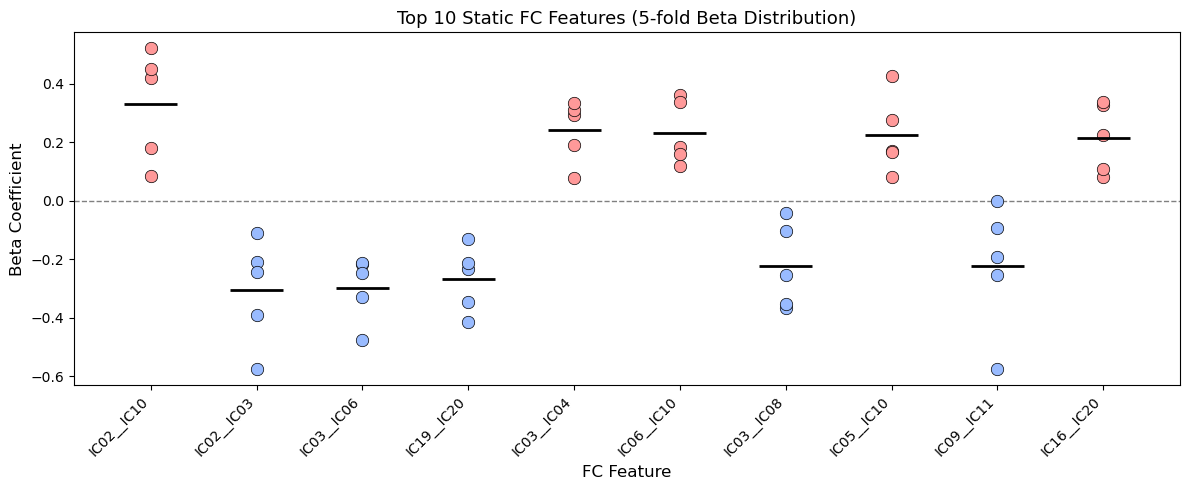

In [ ]:

all_coefs = []
for estimator in best_estimators_per_fold_fairest_static:
    coef = estimator.named_steps["elasticnet"].coef_[0]
    all_coefs.append(coef)

coef_matrix = np.array(all_coefs)  # shape: (5, n_features)


mean_abs_coef = np.mean(np.abs(coef_matrix), axis=0)
top10_idx = np.argsort(mean_abs_coef)[::-1][:10]
top10_names = [static_fc_cols[i] for i in top10_idx]
top10_coefs = coef_matrix[:, top10_idx]  # shape: (5, 10)


print("Top 10 Static FC Features:")
print(f"{'Rank':<6}{'Feature':<20}{'Mean |Beta|':<15}{'Mean Beta':<12}{'Std Beta'}")
print("-" * 65)
for rank, (name, idx) in enumerate(zip(top10_names, top10_idx)):
    vals = coef_matrix[:, idx]
    print(f"{rank+1:<6}{name:<20}{mean_abs_coef[idx]:<15.4f}{np.mean(vals):<12.4f}{np.std(vals):.4f}")


fig, ax = plt.subplots(figsize=(12, 5))

for i, name in enumerate(top10_names):
    vals = top10_coefs[:, i]

    ax.scatter(
        [i + 1] * 5, vals,
        color="#ff9999" if np.mean(vals) > 0 else "#99bbff",
        s=80, zorder=3, edgecolors="black", linewidths=0.5
    )

    ax.hlines(np.mean(vals), i + 0.75, i + 1.25,
              colors="black", linewidths=2, zorder=4)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(1, 11))
ax.set_xticklabels(top10_names, rotation=45, ha="right")
ax.set_xlabel("FC Feature", fontsize=12)
ax.set_ylabel("Beta Coefficient", fontsize=12)
ax.set_title("Top 10 Static FC Features (5-fold Beta Distribution)", fontsize=13)
plt.tight_layout()
plt.show()

Top 10 Static FC Features (Most scans):
Rank  Feature             Mean |Beta|    Mean Beta   Std Beta
-----------------------------------------------------------------
1     IC08__IC10          0.2390         0.2390      0.1244
2     IC02__IC10          0.1934         0.1934      0.1064
3     IC03__IC06          0.1848         -0.1848     0.0732
4     IC12__IC19          0.1784         -0.1784     0.1342
5     IC06__IC10          0.1611         0.1611      0.0566
6     IC02__IC06          0.1439         -0.1439     0.1065
7     IC03__IC13          0.1182         0.1182      0.0400
8     IC17__IC18          0.1178         -0.1178     0.0616
9     IC08__IC11          0.0890         -0.0890     0.0685
10    IC02__IC03          0.0835         -0.0835     0.0963


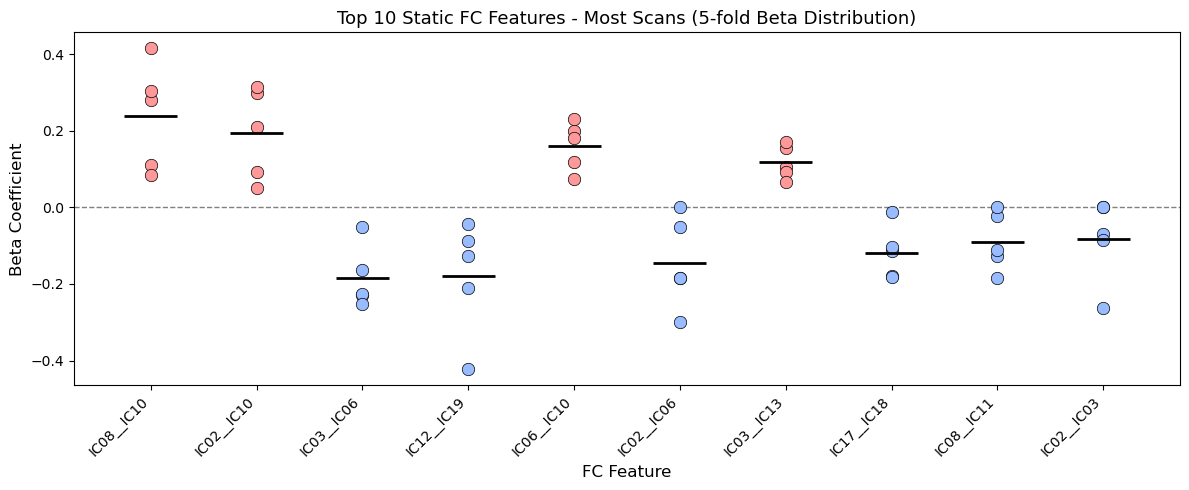

In [ ]:

all_coefs = []
for estimator in best_estimators_per_fold_static:
    coef = estimator.named_steps["elasticnet"].coef_[0]
    all_coefs.append(coef)

coef_matrix = np.array(all_coefs)  # shape: (5, n_features)


mean_abs_coef = np.mean(np.abs(coef_matrix), axis=0)
top10_idx     = np.argsort(mean_abs_coef)[::-1][:10]
top10_names   = [static_fc_cols[i] for i in top10_idx]
top10_coefs   = coef_matrix[:, top10_idx]  # shape: (5, 10)


print("Top 10 Static FC Features (Most scans):")
print(f"{'Rank':<6}{'Feature':<20}{'Mean |Beta|':<15}{'Mean Beta':<12}{'Std Beta'}")
print("-" * 65)
for rank, (name, idx) in enumerate(zip(top10_names, top10_idx)):
    vals = coef_matrix[:, idx]
    print(f"{rank+1:<6}{name:<20}{mean_abs_coef[idx]:<15.4f}{np.mean(vals):<12.4f}{np.std(vals):.4f}")


fig, ax = plt.subplots(figsize=(12, 5))

for i, name in enumerate(top10_names):
    vals = top10_coefs[:, i]
    ax.scatter(
        [i + 1] * 5, vals,
        color="#ff9999" if np.mean(vals) > 0 else "#99bbff",
        s=80, zorder=3, edgecolors="black", linewidths=0.5
    )
    ax.hlines(np.mean(vals), i + 0.75, i + 1.25,
              colors="black", linewidths=2, zorder=4)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(1, 11))
ax.set_xticklabels(top10_names, rotation=45, ha="right")
ax.set_xlabel("FC Feature", fontsize=12)
ax.set_ylabel("Beta Coefficient", fontsize=12)
ax.set_title("Top 10 Static FC Features - Most Scans (5-fold Beta Distribution)", fontsize=13)
plt.tight_layout()
plt.show()

Top 10 Static FC Features (Largest effect):
Rank  Feature             Mean |Beta|    Mean Beta   Std Beta
-----------------------------------------------------------------
1     IC03__IC06          0.2815         -0.2815     0.0980
2     IC02__IC03          0.2739         -0.2739     0.1439
3     IC14__IC15          0.2504         -0.2504     0.1473
4     IC17__IC18          0.2418         -0.2418     0.1290
5     IC03__IC13          0.2139         0.2139      0.1791
6     IC06__IC10          0.2102         0.2102      0.0742
7     IC04__IC16          0.2080         -0.2080     0.1458
8     IC03__IC08          0.1904         -0.1904     0.1217
9     IC08__IC10          0.1876         0.1876      0.1464
10    IC08__IC11          0.1792         -0.1792     0.1940


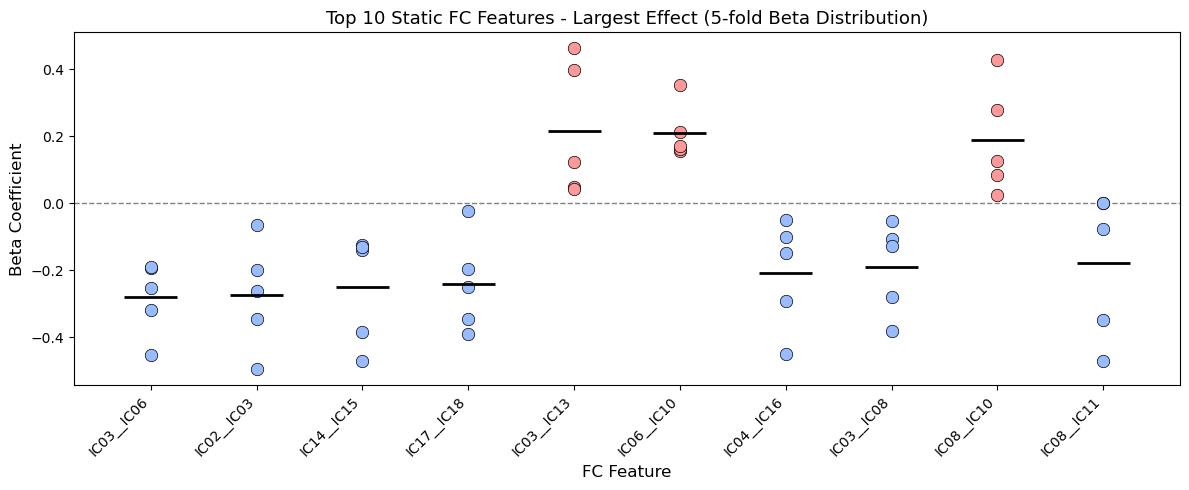

In [ ]:

all_coefs = []
for estimator in best_estimators_per_fold_largest_static:
    coef = estimator.named_steps["elasticnet"].coef_[0]
    all_coefs.append(coef)

coef_matrix = np.array(all_coefs)  # shape: (5, n_features)


mean_abs_coef = np.mean(np.abs(coef_matrix), axis=0)
top10_idx     = np.argsort(mean_abs_coef)[::-1][:10]
top10_names   = [static_fc_cols[i] for i in top10_idx]
top10_coefs   = coef_matrix[:, top10_idx]  # shape: (5, 10)


print("Top 10 Static FC Features (Largest effect):")
print(f"{'Rank':<6}{'Feature':<20}{'Mean |Beta|':<15}{'Mean Beta':<12}{'Std Beta'}")
print("-" * 65)
for rank, (name, idx) in enumerate(zip(top10_names, top10_idx)):
    vals = coef_matrix[:, idx]
    print(f"{rank+1:<6}{name:<20}{mean_abs_coef[idx]:<15.4f}{np.mean(vals):<12.4f}{np.std(vals):.4f}")


fig, ax = plt.subplots(figsize=(12, 5))

for i, name in enumerate(top10_names):
    vals = top10_coefs[:, i]
    ax.scatter(
        [i + 1] * 5, vals,
        color="#ff9999" if np.mean(vals) > 0 else "#99bbff",
        s=80, zorder=3, edgecolors="black", linewidths=0.5
    )
    ax.hlines(np.mean(vals), i + 0.75, i + 1.25,
              colors="black", linewidths=2, zorder=4)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(1, 11))
ax.set_xticklabels(top10_names, rotation=45, ha="right")
ax.set_xlabel("FC Feature", fontsize=12)
ax.set_ylabel("Beta Coefficient", fontsize=12)
ax.set_title("Top 10 Static FC Features - Largest Effect (5-fold Beta Distribution)", fontsize=13)
plt.tight_layout()
plt.show()

## ALFF


Fairest - non-zero voxel: 11980, threshold: 0


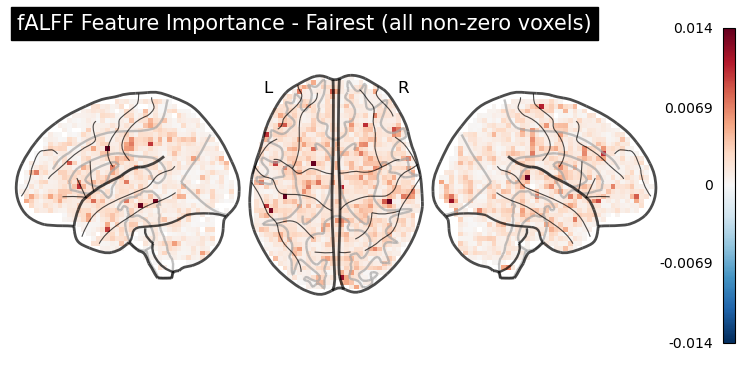

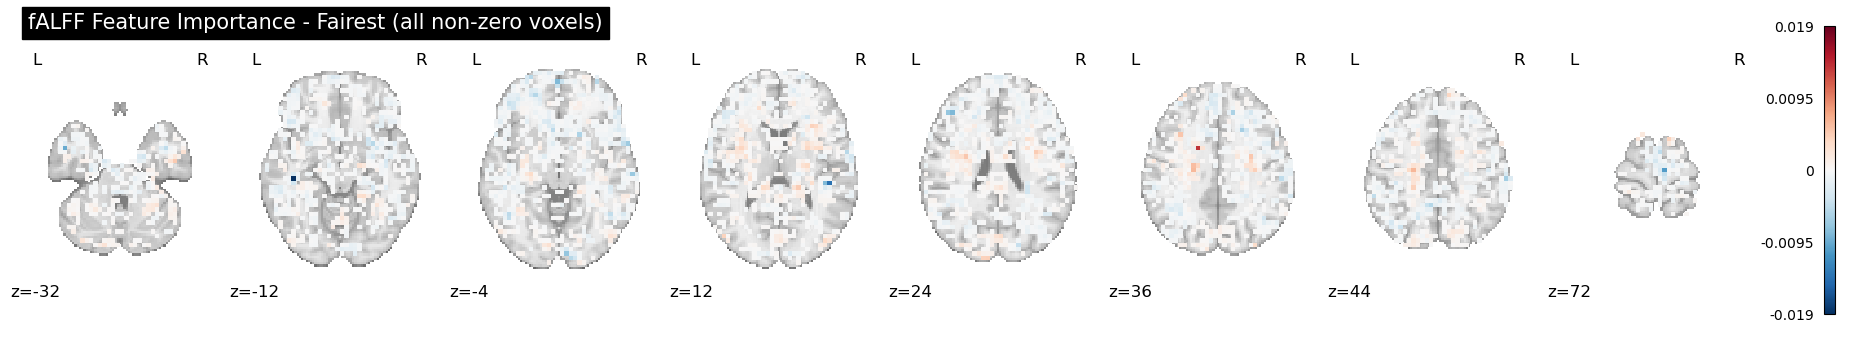


Most Scans - non-zero voxel: 10678, threshold: 0


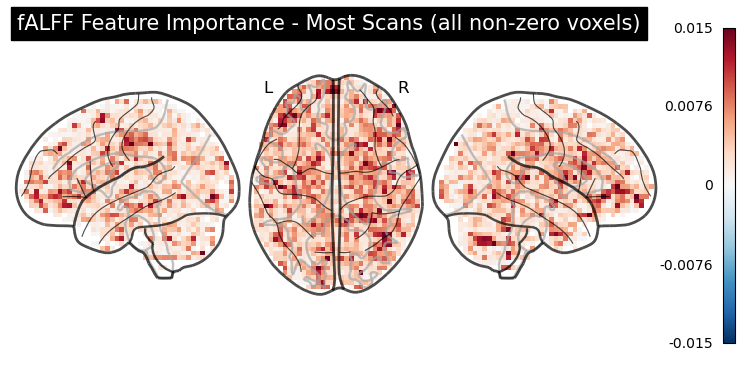

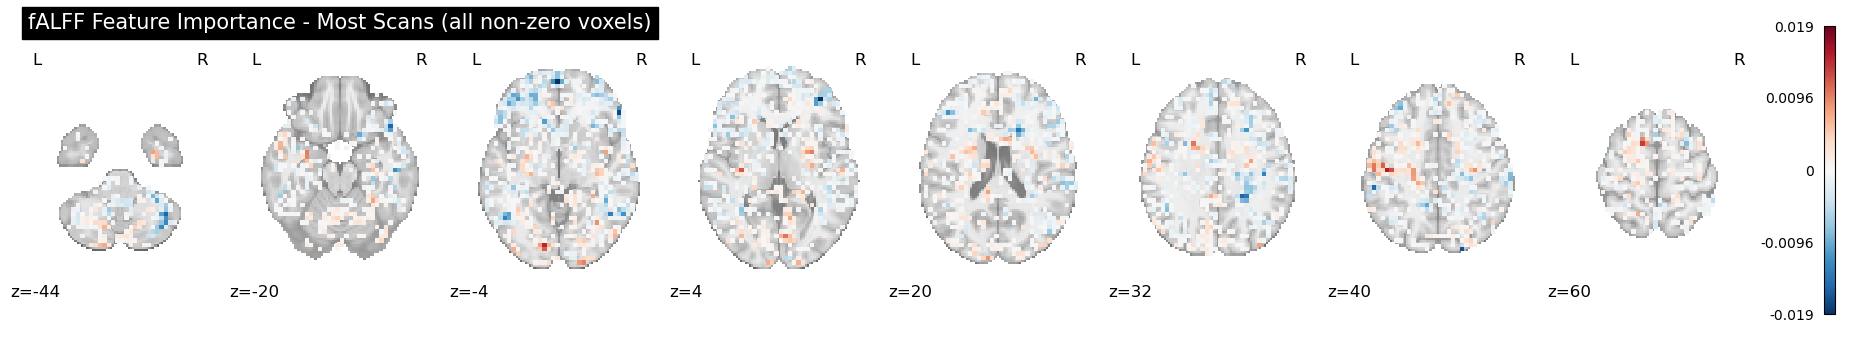


Largest Effect - non-zero voxel: 7212, threshold: 0


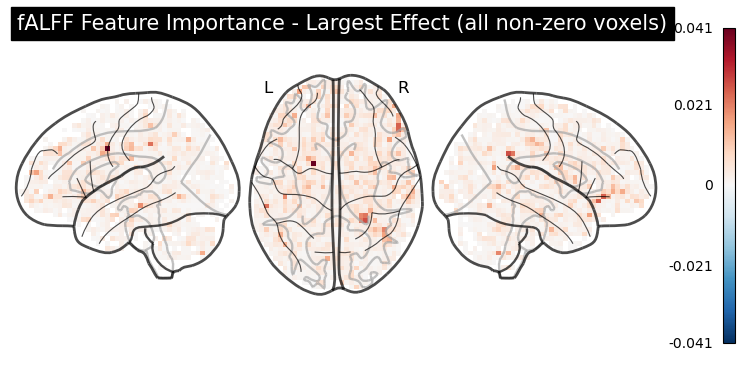

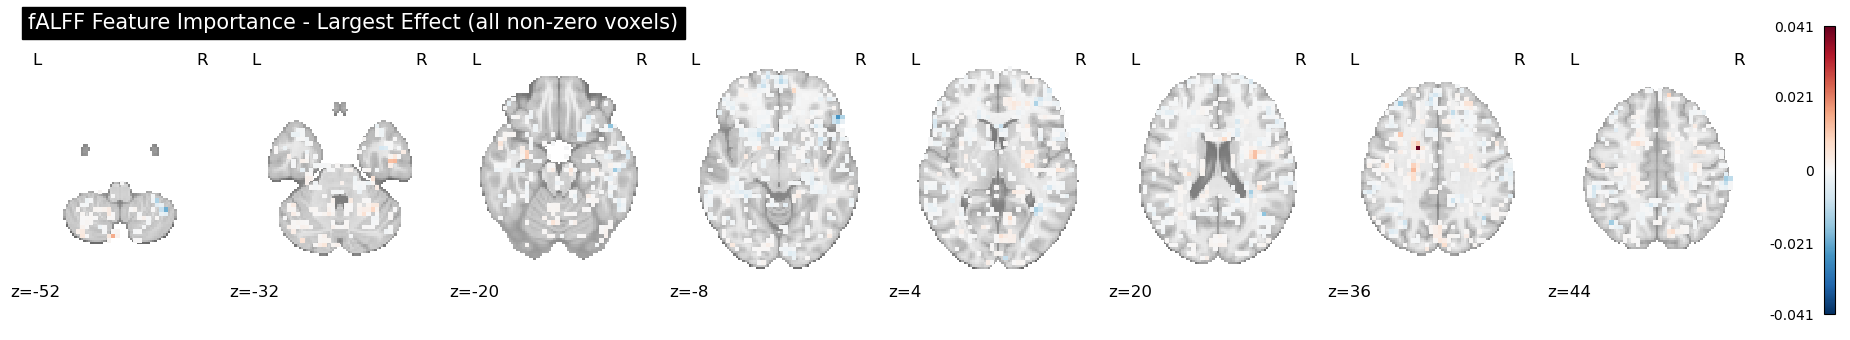

In [63]:
from nilearn.masking import unmask
from nilearn import plotting
from nilearn.image import load_img
import numpy as np

mask_path = OUT_DIR / "common_epi_mask_from_all_scans.nii.gz"
common_mask_img = load_img(str(mask_path))

for strategy, estimators in [
    ("Fairest", best_estimators_per_fold_fairest_falff),
    ("Most Scans", best_estimators_per_fold_falff),
    ("Largest Effect", best_estimators_per_fold_largest_falff)
]:
    # Extract beta coefficients from each fold
    all_coefs = [e.named_steps["elasticnet"].coef_[0] for e in estimators]
    mean_coef = np.mean(all_coefs, axis=0)

    # Select all non-zero voxels
    nonzero_vals = mean_coef[mean_coef != 0]
    threshold = 0

    print(
        f"\n{strategy} - non-zero voxel: {len(nonzero_vals)}, "
        f"threshold: {threshold}"
    )

    # Convert coefficient vector back to brain image
    beta_img = unmask(mean_coef.astype(np.float32), common_mask_img)

    # Glass brain: show all non-zero voxels
    plotting.plot_glass_brain(
        beta_img,
        colorbar=True,
        title=f"fALFF Feature Importance - {strategy} (all non-zero voxels)",
        display_mode="lzr",
        cmap="RdBu_r",
        symmetric_cbar=True,
        threshold=threshold
    )
    plotting.show()

    # Slice view: show all non-zero voxels
    plotting.plot_stat_map(
        beta_img,
        colorbar=True,
        title=f"fALFF Feature Importance - {strategy} (all non-zero voxels)",
        cmap="RdBu_r",
        symmetric_cbar=True,
        display_mode="z",
        cut_coords=8,
        threshold=threshold
    )
    plotting.show()

## Combined

In [82]:
# =========================================================
# Feature Importance by Category - Fairest Combined
# =========================================================

# 1) Extract 5-fold beta values and split by category
all_coefs = []
for estimator in best_estimators_per_fold_fairest_combined:
    coef = estimator.named_steps["elasticnet"].coef_[0]
    all_coefs.append(coef)

coef_matrix = np.array(all_coefs)  # shape: (5, n_total)

n_static  = X_static_fairest.shape[1]
n_dynamic = X_dynamic_fairest.shape[1]
n_falff   = X_falff_fairest.shape[1]

print(f"Static FC:  {n_static} features")
print(f"Dynamic FC: {n_dynamic} features")
print(f"fALFF:      {n_falff} features")
print(f"Total:      {n_static + n_dynamic + n_falff} features")

# Split beta values by category
coef_static  = coef_matrix[:, :n_static]
coef_dynamic = coef_matrix[:, n_static:n_static+n_dynamic]
coef_falff   = coef_matrix[:, n_static+n_dynamic:]

# =========================================================
# 2) Compute all metrics
# =========================================================

# Mean |beta|
mean_abs_static  = np.mean(np.abs(coef_static),  axis=1)
mean_abs_dynamic = np.mean(np.abs(coef_dynamic), axis=1)
mean_abs_falff   = np.mean(np.abs(coef_falff),   axis=1)

# Non-zero ratio
nonzero_ratio_static  = np.mean(coef_static  != 0, axis=1)
nonzero_ratio_dynamic = np.mean(coef_dynamic != 0, axis=1)
nonzero_ratio_falff   = np.mean(coef_falff   != 0, axis=1)

# Non-zero count
nonzero_count_static  = np.sum(coef_static  != 0, axis=1)
nonzero_count_dynamic = np.sum(coef_dynamic != 0, axis=1)
nonzero_count_falff   = np.sum(coef_falff   != 0, axis=1)

# Sum of |beta|
sum_abs_static  = np.sum(np.abs(coef_static),  axis=1)
sum_abs_dynamic = np.sum(np.abs(coef_dynamic), axis=1)
sum_abs_falff   = np.sum(np.abs(coef_falff),   axis=1)

# =========================================================
# 3) Print: Non-zero count + ratio
# =========================================================
print("\nNon-zero feature count and ratio per fold:")
print(f"{'Fold':<6}{'Static n':<12}{'Static %':<12}{'Dynamic n':<12}{'Dynamic %':<12}{'fALFF n':<12}{'fALFF %'}")
print("-" * 72)
for i in range(5):
    print(f"{i+1:<6}{nonzero_count_static[i]:<12}{nonzero_ratio_static[i]:<12.3f}"
          f"{nonzero_count_dynamic[i]:<12}{nonzero_ratio_dynamic[i]:<12.3f}"
          f"{nonzero_count_falff[i]:<12}{nonzero_ratio_falff[i]:.3f}")
print(f"\n{'Mean':<6}{np.mean(nonzero_count_static):<12.1f}{np.mean(nonzero_ratio_static):<12.3f}"
      f"{np.mean(nonzero_count_dynamic):<12.1f}{np.mean(nonzero_ratio_dynamic):<12.3f}"
      f"{np.mean(nonzero_count_falff):<12.1f}{np.mean(nonzero_ratio_falff):.3f}")

# =========================================================
# 4) Print: Mean |beta| + Sum |beta|
# =========================================================
print("\nMean |beta| and Sum of |beta| per fold:")
print(f"{'Fold':<6}{'Static mean':<14}{'Static sum':<14}{'Dynamic mean':<14}{'Dynamic sum':<14}{'fALFF mean':<14}{'fALFF sum'}")
print("-" * 84)
for i in range(5):
    print(f"{i+1:<6}{mean_abs_static[i]:<14.6f}{sum_abs_static[i]:<14.4f}"
          f"{mean_abs_dynamic[i]:<14.6f}{sum_abs_dynamic[i]:<14.4f}"
          f"{mean_abs_falff[i]:<14.6f}{sum_abs_falff[i]:.4f}")
print(f"\n{'Mean':<6}{np.mean(mean_abs_static):<14.6f}{np.mean(sum_abs_static):<14.4f}"
      f"{np.mean(mean_abs_dynamic):<14.6f}{np.mean(sum_abs_dynamic):<14.4f}"
      f"{np.mean(mean_abs_falff):<14.6f}{np.mean(sum_abs_falff):.4f}")

Static FC:  190 features
Dynamic FC: 190 features
fALFF:      27380 features
Total:      27760 features

Non-zero feature count and ratio per fold:
Fold  Static n    Static %    Dynamic n   Dynamic %   fALFF n     fALFF %
------------------------------------------------------------------------
1     9           0.047       1           0.005       115         0.004
2     57          0.300       29          0.153       2468        0.090
3     64          0.337       45          0.237       2476        0.090
4     7           0.037       0           0.000       86          0.003
5     1           0.005       0           0.000       113         0.004

Mean  27.6        0.145       15.0        0.079       1051.6      0.038

Mean |beta| and Sum of |beta| per fold:
Fold  Static mean   Static sum    Dynamic mean  Dynamic sum   fALFF mean    fALFF sum
------------------------------------------------------------------------------------
1     0.001131      0.2149        0.000041      0.0077      

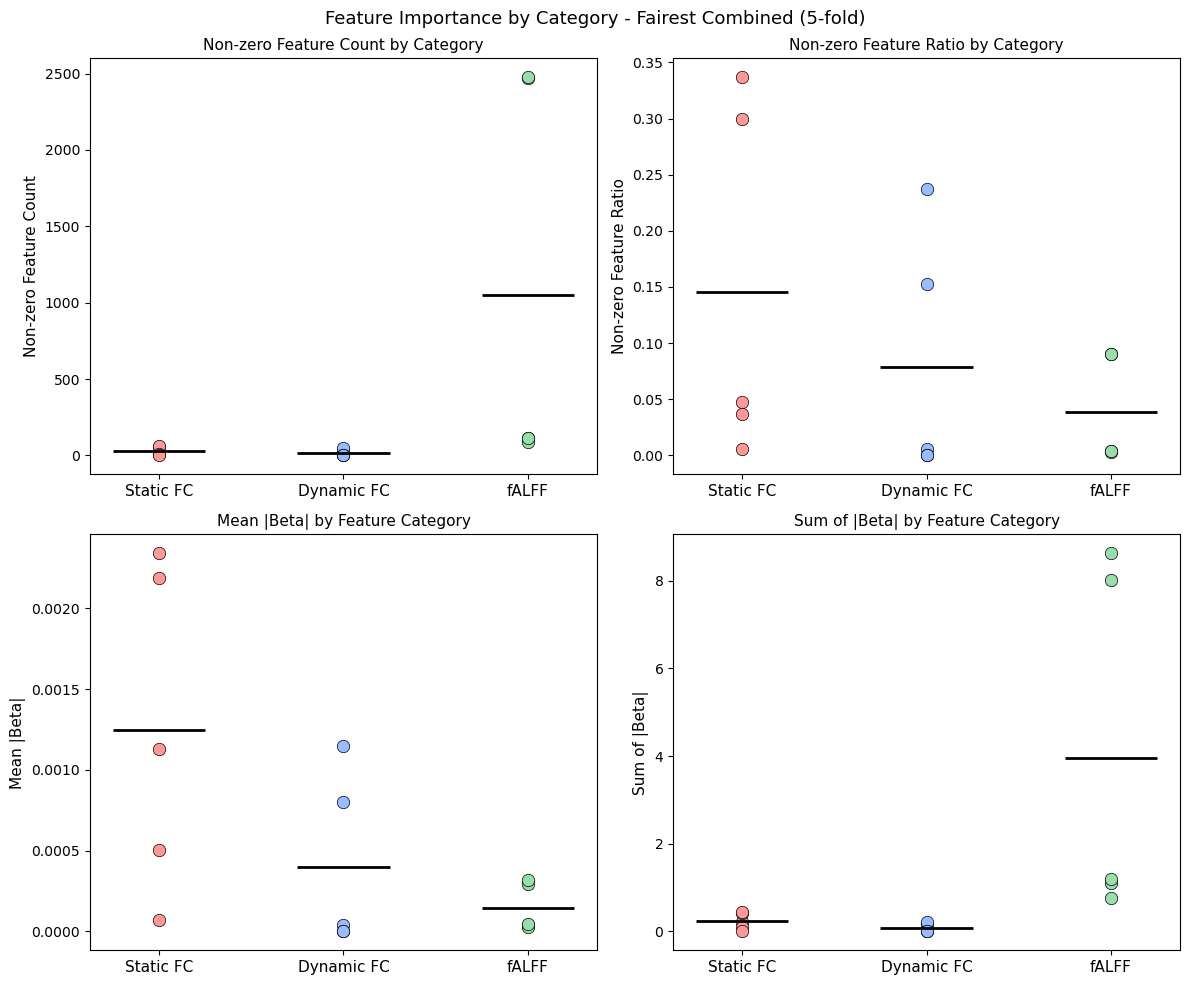

In [83]:
# =========================================================
# Plot: Feature Importance by Category - Fairest Combined
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

categories = ["Static FC", "Dynamic FC", "fALFF"]
colors     = ["#ff9999", "#99bbff", "#99ddaa"]

plot_data = [
    (axes[0, 0], [nonzero_count_static, nonzero_count_dynamic, nonzero_count_falff],
     "Non-zero Feature Count", "Non-zero Feature Count by Category"),
    (axes[0, 1], [nonzero_ratio_static, nonzero_ratio_dynamic, nonzero_ratio_falff],
     "Non-zero Feature Ratio", "Non-zero Feature Ratio by Category"),
    (axes[1, 0], [mean_abs_static, mean_abs_dynamic, mean_abs_falff],
     "Mean |Beta|", "Mean |Beta| by Feature Category"),
    (axes[1, 1], [sum_abs_static, sum_abs_dynamic, sum_abs_falff],
     "Sum of |Beta|", "Sum of |Beta| by Feature Category"),
]

for ax, data, ylabel, title in plot_data:
    for i, (vals, color) in enumerate(zip(data, colors)):
        ax.scatter(
            [i + 1] * 5, vals,
            color=color, s=80, zorder=3,
            edgecolors="black", linewidths=0.5
        )
        ax.hlines(np.mean(vals), i + 0.75, i + 1.25,
                  colors="black", linewidths=2, zorder=4)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)

plt.suptitle("Feature Importance by Category - Fairest Combined (5-fold)", fontsize=13)
plt.tight_layout()
plt.show()

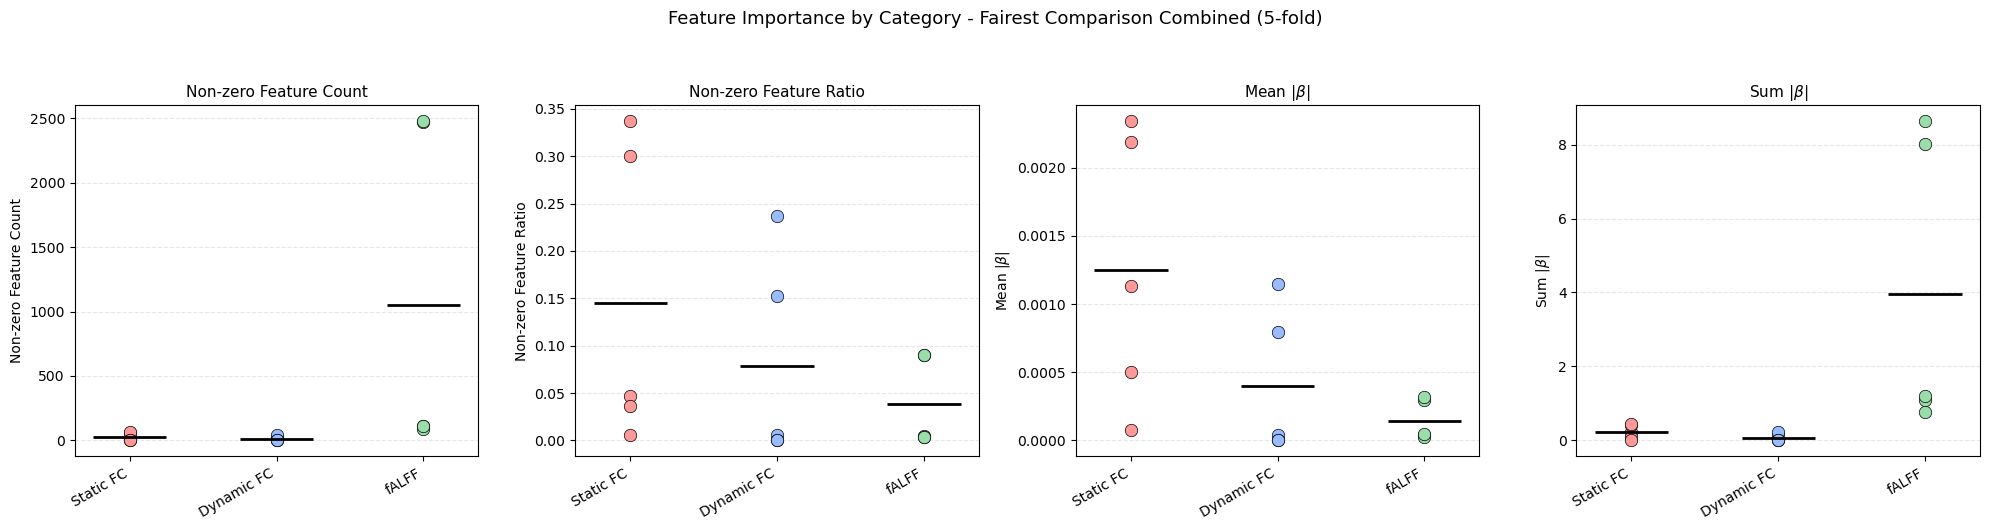

In [84]:
# =========================================================
# 5) Plot: Feature Importance by Category - Fairest Combined
#    4 subplots in one row
# =========================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

categories = ["Static FC", "Dynamic FC", "fALFF"]
colors = ["#ff9999", "#99bbff", "#99ddaa"]

plot_data = [
    (
        axes[0],
        [nonzero_count_static, nonzero_count_dynamic, nonzero_count_falff],
        "Non-zero Feature Count",
        "Non-zero Feature Count"
    ),
    (
        axes[1],
        [nonzero_ratio_static, nonzero_ratio_dynamic, nonzero_ratio_falff],
        "Non-zero Feature Ratio",
        "Non-zero Feature Ratio"
    ),
    (
        axes[2],
        [mean_abs_static, mean_abs_dynamic, mean_abs_falff],
        r"Mean $|\beta|$",
        r"Mean $|\beta|$"
    ),
    (
        axes[3],
        [sum_abs_static, sum_abs_dynamic, sum_abs_falff],
        r"Sum $|\beta|$",
        r"Sum $|\beta|$"
    ),
]

for ax, data, ylabel, title in plot_data:
    for i, (vals, color) in enumerate(zip(data, colors)):
        ax.scatter(
            [i + 1] * len(vals),
            vals,
            color=color,
            s=80,
            zorder=3,
            edgecolors="black",
            linewidths=0.5
        )

        # Mean line across folds
        ax.hlines(
            np.mean(vals),
            i + 0.75,
            i + 1.25,
            colors="black",
            linewidth=2,
            zorder=4
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(categories, fontsize=10, rotation=30, ha="right")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle(
    "Feature Importance by Category - Fairest Comparison Combined (5-fold)",
    fontsize=13,
    y=1.05
)

plt.tight_layout()
plt.show()

In [85]:
# =========================================================
# Feature Importance by Category - Most Scans Combined
# =========================================================

# 1) Extract 5-fold beta values and split by category
all_coefs = []
for estimator in best_estimators_per_fold_most_combined:
    coef = estimator.named_steps["elasticnet"].coef_[0]
    all_coefs.append(coef)

coef_matrix = np.array(all_coefs)  # shape: (5, n_total)

n_static  = X_static_most.shape[1]
n_dynamic = X_dynamic_most.shape[1]
n_falff   = X_falff_most.shape[1]

print(f"Static FC:  {n_static} features")
print(f"Dynamic FC: {n_dynamic} features")
print(f"fALFF:      {n_falff} features")
print(f"Total:      {n_static + n_dynamic + n_falff} features")

# Split beta values by category
coef_static  = coef_matrix[:, :n_static]
coef_dynamic = coef_matrix[:, n_static:n_static+n_dynamic]
coef_falff   = coef_matrix[:, n_static+n_dynamic:]

# =========================================================
# 2) Compute all metrics
# =========================================================

# Mean |beta|
mean_abs_static  = np.mean(np.abs(coef_static),  axis=1)
mean_abs_dynamic = np.mean(np.abs(coef_dynamic), axis=1)
mean_abs_falff   = np.mean(np.abs(coef_falff),   axis=1)

# Non-zero ratio
nonzero_ratio_static  = np.mean(coef_static  != 0, axis=1)
nonzero_ratio_dynamic = np.mean(coef_dynamic != 0, axis=1)
nonzero_ratio_falff   = np.mean(coef_falff   != 0, axis=1)

# Non-zero count
nonzero_count_static  = np.sum(coef_static  != 0, axis=1)
nonzero_count_dynamic = np.sum(coef_dynamic != 0, axis=1)
nonzero_count_falff   = np.sum(coef_falff   != 0, axis=1)

# Sum of |beta|
sum_abs_static  = np.sum(np.abs(coef_static),  axis=1)
sum_abs_dynamic = np.sum(np.abs(coef_dynamic), axis=1)
sum_abs_falff   = np.sum(np.abs(coef_falff),   axis=1)

# =========================================================
# 3) Print: Non-zero count + ratio
# =========================================================
print("\nNon-zero feature count and ratio per fold:")
print(f"{'Fold':<6}{'Static n':<12}{'Static %':<12}{'Dynamic n':<12}{'Dynamic %':<12}{'fALFF n':<12}{'fALFF %'}")
print("-" * 72)
for i in range(5):
    print(f"{i+1:<6}{nonzero_count_static[i]:<12}{nonzero_ratio_static[i]:<12.3f}"
          f"{nonzero_count_dynamic[i]:<12}{nonzero_ratio_dynamic[i]:<12.3f}"
          f"{nonzero_count_falff[i]:<12}{nonzero_ratio_falff[i]:.3f}")
print(f"\n{'Mean':<6}{np.mean(nonzero_count_static):<12.1f}{np.mean(nonzero_ratio_static):<12.3f}"
      f"{np.mean(nonzero_count_dynamic):<12.1f}{np.mean(nonzero_ratio_dynamic):<12.3f}"
      f"{np.mean(nonzero_count_falff):<12.1f}{np.mean(nonzero_ratio_falff):.3f}")

# =========================================================
# 4) Print: Mean |beta| + Sum |beta|
# =========================================================
print("\nMean |beta| and Sum of |beta| per fold:")
print(f"{'Fold':<6}{'Static mean':<14}{'Static sum':<14}{'Dynamic mean':<14}{'Dynamic sum':<14}{'fALFF mean':<14}{'fALFF sum'}")
print("-" * 84)
for i in range(5):
    print(f"{i+1:<6}{mean_abs_static[i]:<14.6f}{sum_abs_static[i]:<14.4f}"
          f"{mean_abs_dynamic[i]:<14.6f}{sum_abs_dynamic[i]:<14.4f}"
          f"{mean_abs_falff[i]:<14.6f}{sum_abs_falff[i]:.4f}")
print(f"\n{'Mean':<6}{np.mean(mean_abs_static):<14.6f}{np.mean(sum_abs_static):<14.4f}"
      f"{np.mean(mean_abs_dynamic):<14.6f}{np.mean(sum_abs_dynamic):<14.4f}"
      f"{np.mean(mean_abs_falff):<14.6f}{np.mean(sum_abs_falff):.4f}")



Static FC:  190 features
Dynamic FC: 190 features
fALFF:      27380 features
Total:      27760 features

Non-zero feature count and ratio per fold:
Fold  Static n    Static %    Dynamic n   Dynamic %   fALFF n     fALFF %
------------------------------------------------------------------------
1     60          0.316       48          0.253       3572        0.130
2     64          0.337       81          0.426       4412        0.161
3     63          0.332       60          0.316       2460        0.090
4     59          0.311       56          0.295       2449        0.089
5     77          0.405       75          0.395       4789        0.175

Mean  64.6        0.340       64.0        0.337       3536.4      0.129

Mean |beta| and Sum of |beta| per fold:
Fold  Static mean   Static sum    Dynamic mean  Dynamic sum   fALFF mean    fALFF sum
------------------------------------------------------------------------------------
1     0.002688      0.5107        0.001719      0.3265      

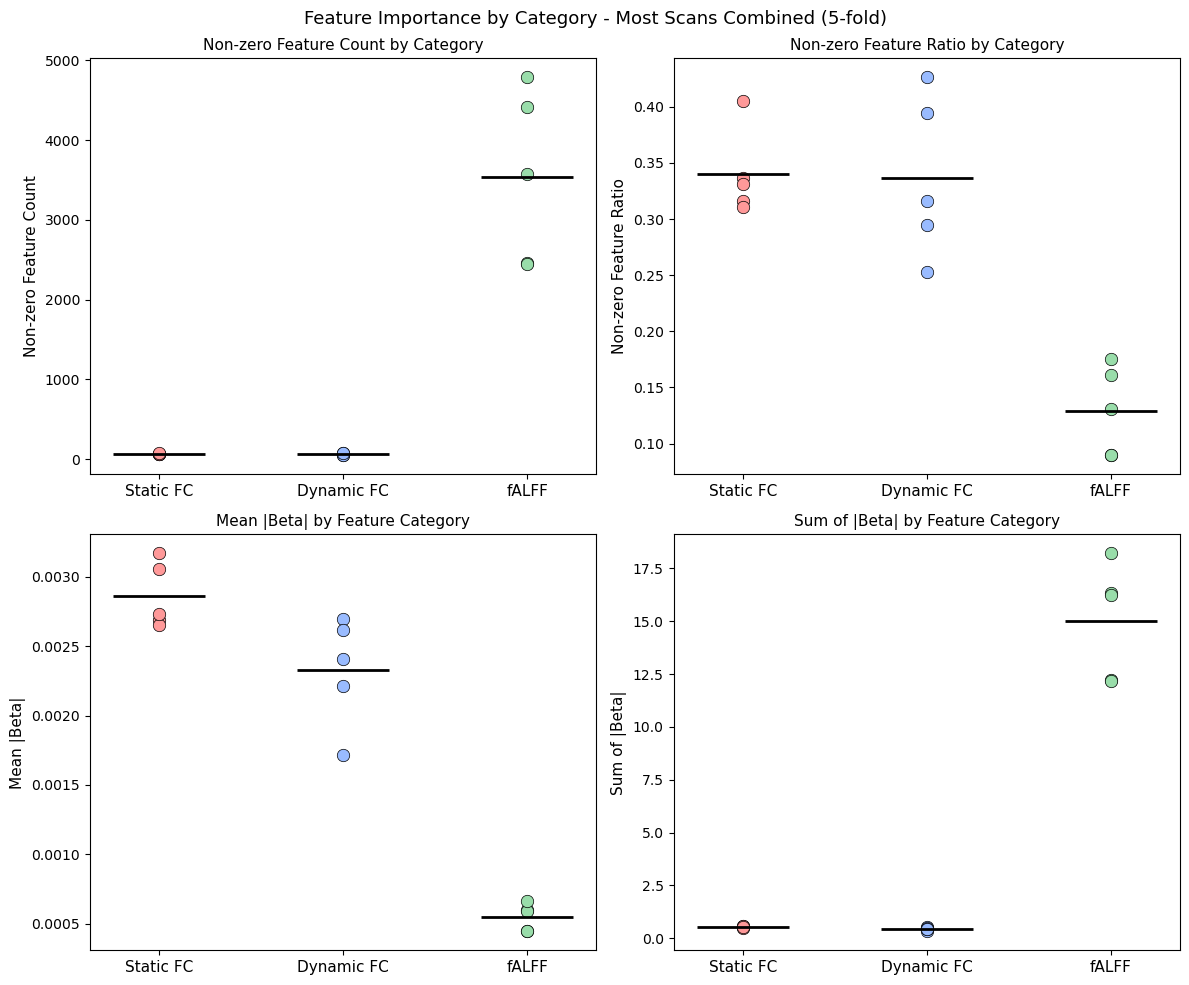

In [86]:
# =========================================================
# 5) Plot: 4 subplots
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

categories = ["Static FC", "Dynamic FC", "fALFF"]
colors     = ["#ff9999", "#99bbff", "#99ddaa"]

plot_data = [
    (axes[0, 0], [nonzero_count_static, nonzero_count_dynamic, nonzero_count_falff],
     "Non-zero Feature Count", "Non-zero Feature Count by Category"),
    (axes[0, 1], [nonzero_ratio_static, nonzero_ratio_dynamic, nonzero_ratio_falff],
     "Non-zero Feature Ratio", "Non-zero Feature Ratio by Category"),
    (axes[1, 0], [mean_abs_static, mean_abs_dynamic, mean_abs_falff],
     "Mean |Beta|", "Mean |Beta| by Feature Category"),
    (axes[1, 1], [sum_abs_static, sum_abs_dynamic, sum_abs_falff],
     "Sum of |Beta|", "Sum of |Beta| by Feature Category"),
]

for ax, data, ylabel, title in plot_data:
    for i, (vals, color) in enumerate(zip(data, colors)):
        ax.scatter(
            [i + 1] * 5, vals,
            color=color, s=80, zorder=3,
            edgecolors="black", linewidths=0.5
        )
        ax.hlines(np.mean(vals), i + 0.75, i + 1.25,
                  colors="black", linewidths=2, zorder=4)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)

plt.suptitle("Feature Importance by Category - Most Scans Combined (5-fold)", fontsize=13)
plt.tight_layout()
plt.show()

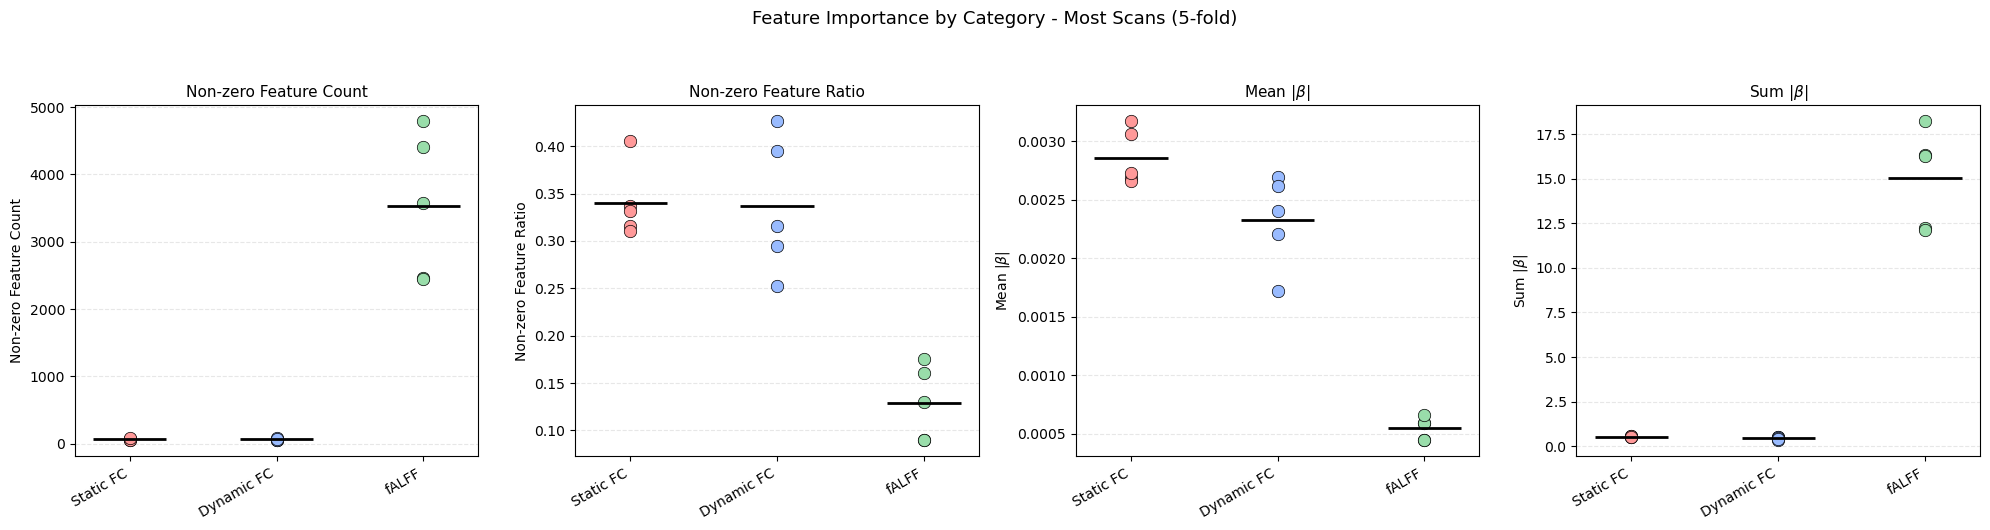

In [87]:
# =========================================================
# 5) Plot: 4 subplots in one row
# =========================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

categories = ["Static FC", "Dynamic FC", "fALFF"]
colors = ["#ff9999", "#99bbff", "#99ddaa"]

plot_data = [
    (
        axes[0],
        [nonzero_count_static, nonzero_count_dynamic, nonzero_count_falff],
        "Non-zero Feature Count",
        "Non-zero Feature Count"
    ),
    (
        axes[1],
        [nonzero_ratio_static, nonzero_ratio_dynamic, nonzero_ratio_falff],
        "Non-zero Feature Ratio",
        "Non-zero Feature Ratio"
    ),
    (
        axes[2],
        [mean_abs_static, mean_abs_dynamic, mean_abs_falff],
        r"Mean $|\beta|$",
        r"Mean $|\beta|$"
    ),
    (
        axes[3],
        [sum_abs_static, sum_abs_dynamic, sum_abs_falff],
        r"Sum $|\beta|$",
        r"Sum $|\beta|$"
    ),
]

for ax, data, ylabel, title in plot_data:
    for i, (vals, color) in enumerate(zip(data, colors)):
        ax.scatter(
            [i + 1] * len(vals),
            vals,
            color=color,
            s=80,
            zorder=3,
            edgecolors="black",
            linewidths=0.5
        )

        ax.hlines(
            np.mean(vals),
            i + 0.75,
            i + 1.25,
            colors="black",
            linewidth=2,
            zorder=4
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(categories, fontsize=10, rotation=30, ha="right")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle(
    "Feature Importance by Category - Most Scans (5-fold)",
    fontsize=13,
    y=1.05
)

plt.tight_layout()
plt.show()

In [88]:
# =========================================================
# Feature Importance by Category - Largest Effect Combined
# =========================================================

# 1) Extract 5-fold beta values and split by category
all_coefs = []
for estimator in best_estimators_per_fold_largest_combined:
    coef = estimator.named_steps["elasticnet"].coef_[0]
    all_coefs.append(coef)

coef_matrix = np.array(all_coefs)  # shape: (5, n_total)

n_static  = X_static_largest.shape[1]
n_dynamic = X_dynamic_largest.shape[1]
n_falff   = X_falff_largest.shape[1]

print(f"Static FC:  {n_static} features")
print(f"Dynamic FC: {n_dynamic} features")
print(f"fALFF:      {n_falff} features")
print(f"Total:      {n_static + n_dynamic + n_falff} features")

# Split beta values by category
coef_static  = coef_matrix[:, :n_static]
coef_dynamic = coef_matrix[:, n_static:n_static+n_dynamic]
coef_falff   = coef_matrix[:, n_static+n_dynamic:]

# =========================================================
# 2) Compute all metrics
# =========================================================

# Mean |beta|
mean_abs_static  = np.mean(np.abs(coef_static),  axis=1)
mean_abs_dynamic = np.mean(np.abs(coef_dynamic), axis=1)
mean_abs_falff   = np.mean(np.abs(coef_falff),   axis=1)

# Non-zero ratio
nonzero_ratio_static  = np.mean(coef_static  != 0, axis=1)
nonzero_ratio_dynamic = np.mean(coef_dynamic != 0, axis=1)
nonzero_ratio_falff   = np.mean(coef_falff   != 0, axis=1)

# Non-zero count
nonzero_count_static  = np.sum(coef_static  != 0, axis=1)
nonzero_count_dynamic = np.sum(coef_dynamic != 0, axis=1)
nonzero_count_falff   = np.sum(coef_falff   != 0, axis=1)

# Sum of |beta|
sum_abs_static  = np.sum(np.abs(coef_static),  axis=1)
sum_abs_dynamic = np.sum(np.abs(coef_dynamic), axis=1)
sum_abs_falff   = np.sum(np.abs(coef_falff),   axis=1)

# =========================================================
# 3) Print: Non-zero count + ratio
# =========================================================
print("\nNon-zero feature count and ratio per fold:")
print(f"{'Fold':<6}{'Static n':<12}{'Static %':<12}{'Dynamic n':<12}{'Dynamic %':<12}{'fALFF n':<12}{'fALFF %'}")
print("-" * 72)
for i in range(5):
    print(f"{i+1:<6}{nonzero_count_static[i]:<12}{nonzero_ratio_static[i]:<12.3f}"
          f"{nonzero_count_dynamic[i]:<12}{nonzero_ratio_dynamic[i]:<12.3f}"
          f"{nonzero_count_falff[i]:<12}{nonzero_ratio_falff[i]:.3f}")
print(f"\n{'Mean':<6}{np.mean(nonzero_count_static):<12.1f}{np.mean(nonzero_ratio_static):<12.3f}"
      f"{np.mean(nonzero_count_dynamic):<12.1f}{np.mean(nonzero_ratio_dynamic):<12.3f}"
      f"{np.mean(nonzero_count_falff):<12.1f}{np.mean(nonzero_ratio_falff):.3f}")

# =========================================================
# 4) Print: Mean |beta| + Sum |beta|
# =========================================================
print("\nMean |beta| and Sum of |beta| per fold:")
print(f"{'Fold':<6}{'Static mean':<14}{'Static sum':<14}{'Dynamic mean':<14}{'Dynamic sum':<14}{'fALFF mean':<14}{'fALFF sum'}")
print("-" * 84)
for i in range(5):
    print(f"{i+1:<6}{mean_abs_static[i]:<14.6f}{sum_abs_static[i]:<14.4f}"
          f"{mean_abs_dynamic[i]:<14.6f}{sum_abs_dynamic[i]:<14.4f}"
          f"{mean_abs_falff[i]:<14.6f}{sum_abs_falff[i]:.4f}")
print(f"\n{'Mean':<6}{np.mean(mean_abs_static):<14.6f}{np.mean(sum_abs_static):<14.4f}"
      f"{np.mean(mean_abs_dynamic):<14.6f}{np.mean(sum_abs_dynamic):<14.4f}"
      f"{np.mean(mean_abs_falff):<14.6f}{np.mean(sum_abs_falff):.4f}")



Static FC:  190 features
Dynamic FC: 190 features
fALFF:      27380 features
Total:      27760 features

Non-zero feature count and ratio per fold:
Fold  Static n    Static %    Dynamic n   Dynamic %   fALFF n     fALFF %
------------------------------------------------------------------------
1     64          0.337       49          0.258       3009        0.110
2     70          0.368       73          0.384       4046        0.148
3     51          0.268       40          0.211       968         0.035
4     33          0.174       25          0.132       381         0.014
5     43          0.226       34          0.179       989         0.036

Mean  52.2        0.275       44.2        0.233       1878.6      0.069

Mean |beta| and Sum of |beta| per fold:
Fold  Static mean   Static sum    Dynamic mean  Dynamic sum   fALFF mean    fALFF sum
------------------------------------------------------------------------------------
1     0.003585      0.6811        0.002140      0.4066      

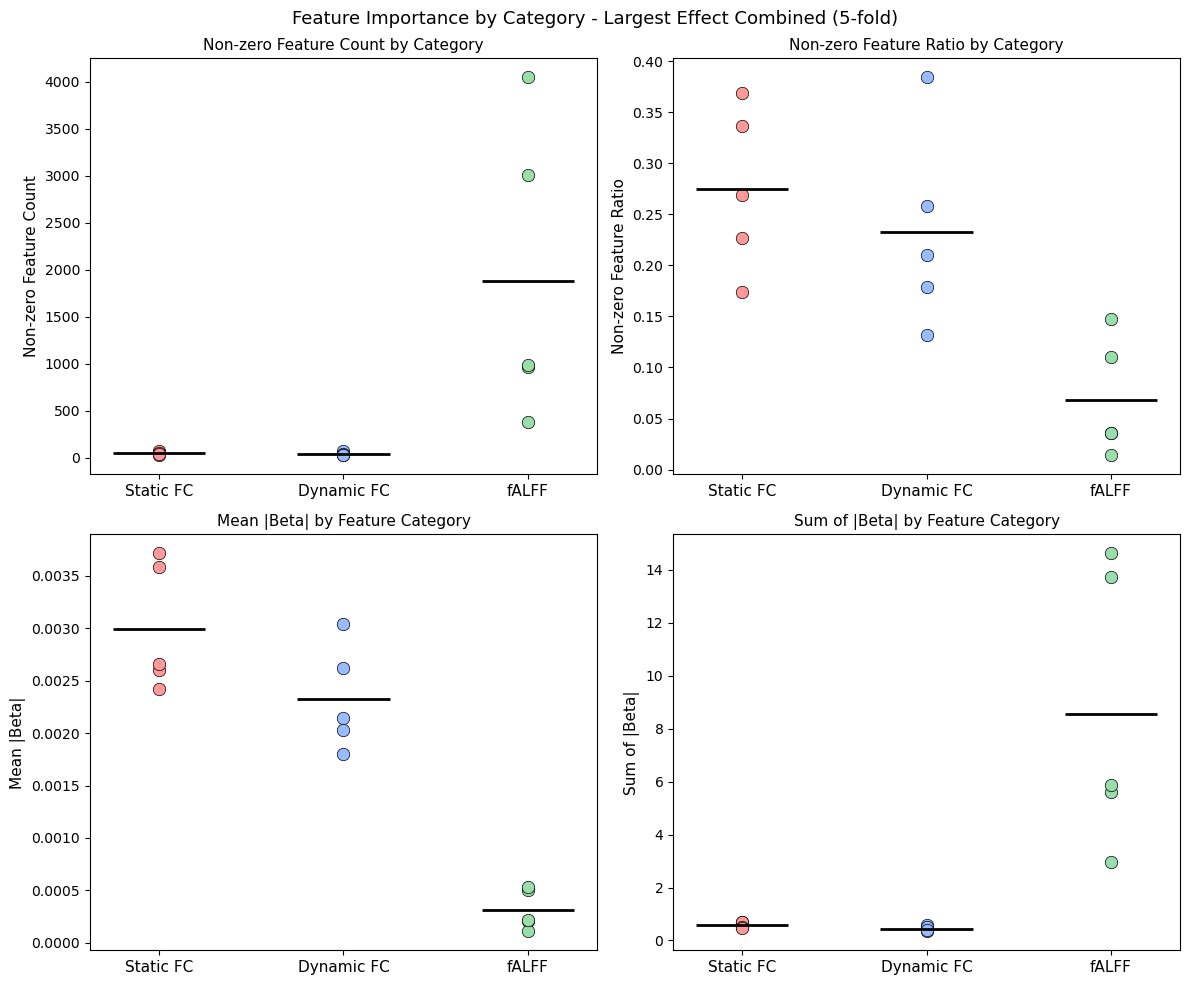

In [89]:
# =========================================================
# 5) Plot: 4 subplots
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

categories = ["Static FC", "Dynamic FC", "fALFF"]
colors     = ["#ff9999", "#99bbff", "#99ddaa"]

plot_data = [
    (axes[0, 0], [nonzero_count_static, nonzero_count_dynamic, nonzero_count_falff],
     "Non-zero Feature Count", "Non-zero Feature Count by Category"),
    (axes[0, 1], [nonzero_ratio_static, nonzero_ratio_dynamic, nonzero_ratio_falff],
     "Non-zero Feature Ratio", "Non-zero Feature Ratio by Category"),
    (axes[1, 0], [mean_abs_static, mean_abs_dynamic, mean_abs_falff],
     "Mean |Beta|", "Mean |Beta| by Feature Category"),
    (axes[1, 1], [sum_abs_static, sum_abs_dynamic, sum_abs_falff],
     "Sum of |Beta|", "Sum of |Beta| by Feature Category"),
]

for ax, data, ylabel, title in plot_data:
    for i, (vals, color) in enumerate(zip(data, colors)):
        ax.scatter(
            [i + 1] * 5, vals,
            color=color, s=80, zorder=3,
            edgecolors="black", linewidths=0.5
        )
        ax.hlines(np.mean(vals), i + 0.75, i + 1.25,
                  colors="black", linewidths=2, zorder=4)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)

plt.suptitle("Feature Importance by Category - Largest Effect Combined (5-fold)", fontsize=13)
plt.tight_layout()
plt.show()

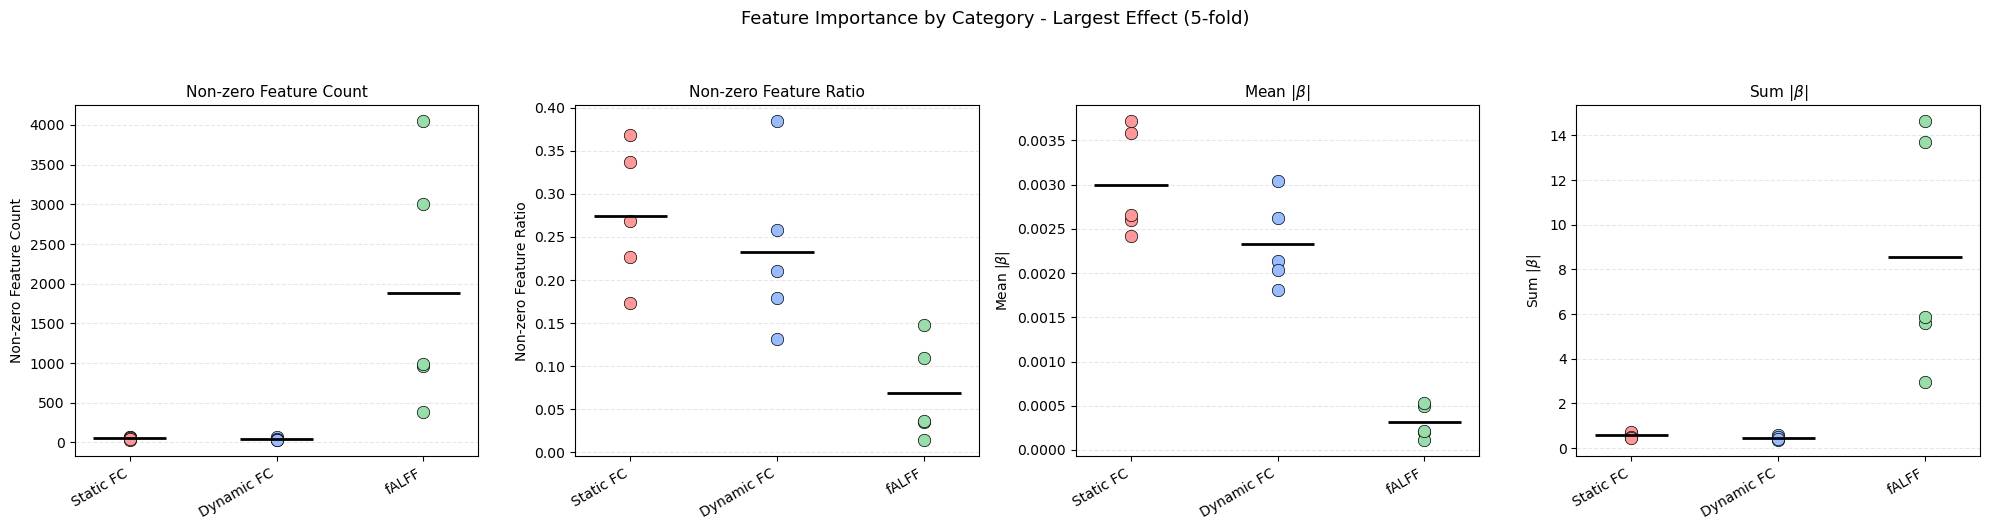

In [90]:
# =========================================================
# 5) Plot: 4 subplots in one row
# =========================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

categories = ["Static FC", "Dynamic FC", "fALFF"]
colors = ["#ff9999", "#99bbff", "#99ddaa"]

plot_data = [
    (
        axes[0],
        [nonzero_count_static, nonzero_count_dynamic, nonzero_count_falff],
        "Non-zero Feature Count",
        "Non-zero Feature Count"
    ),
    (
        axes[1],
        [nonzero_ratio_static, nonzero_ratio_dynamic, nonzero_ratio_falff],
        "Non-zero Feature Ratio",
        "Non-zero Feature Ratio"
    ),
    (
        axes[2],
        [mean_abs_static, mean_abs_dynamic, mean_abs_falff],
        r"Mean $|\beta|$",
        r"Mean $|\beta|$"
    ),
    (
        axes[3],
        [sum_abs_static, sum_abs_dynamic, sum_abs_falff],
        r"Sum $|\beta|$",
        r"Sum $|\beta|$"
    ),
]

for ax, data, ylabel, title in plot_data:
    for i, (vals, color) in enumerate(zip(data, colors)):
        ax.scatter(
            [i + 1] * len(vals),
            vals,
            color=color,
            s=80,
            zorder=3,
            edgecolors="black",
            linewidths=0.5
        )

        ax.hlines(
            np.mean(vals),
            i + 0.75,
            i + 1.25,
            colors="black",
            linewidths=2,
            zorder=4
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(categories, fontsize=10, rotation=30, ha="right")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle(
    "Feature Importance by Category - Largest Effect (5-fold)",
    fontsize=13,
    y=1.05
)

plt.tight_layout()
plt.show()